# 

### 실행 전 사항
- 메모리가 적어도 32G이상의 사양을 가지는 기기를 사용해서 코드를 실행시켜야합니다.
- 후술할 데이터셋 출처에서 데이터를 그대로 풀어서 사용하시면 됩니다.

# 데이터셋 출처
- [KAMP 전자부품(배터리팩) 품질보증 AI 데이터셋](https://www.kamp-ai.kr/aidataDetail?AI_SEARCH=&page=2&DATASET_SEQ=58&DISPLAY_MODE_SEL=CARD&EQUIP_SEL=&GUBUN_SEL=C004027&FILE_TYPE_SEL=C005002&WDATE_SEL=)

# 설정 세팅

In [1]:
# "as name" indicates the name we will use to refer to this library
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
# we will only import certain module from those libraries
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
#from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from random import randrange
from datetime import datetime
import math
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
warnings.simplefilter(action='ignore', category=FutureWarning)
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


2026-03-18 05:58:02.543426: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-18 05:58:03.182170: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-18 05:58:04.799096: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# 폰트 설정
import matplotlib
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

## 1. 파일 불러오기

In [3]:
# 파일을 불러와서 리스트에 데이터 프레임 저장하기

HOME = os.getcwd()

# 학습용 파일
train_path = os.path.join(HOME, "data", "raw_data", "train")
train_path_list = []
for path in os.listdir(train_path):
    train_path_list.append(os.path.join(train_path, path))

# 테스트 파일
test_path_list = []
test_path = os.path.join(HOME, "data", "raw_data", "test")
for path in os.listdir(test_path):
    test_path_list.append(os.path.join(test_path, path))

print("train 파일 경로 리스트 일부")
display(train_path_list[0:5])
print("test 파일 경로 리스트 일부")
display(test_path_list[0:5])

train 파일 경로 리스트 일부


['/mnt/c/Users/Administrator/github/project2/data/raw_data/train/1000_chg.csv',
 '/mnt/c/Users/Administrator/github/project2/data/raw_data/train/1000_dchg.csv',
 '/mnt/c/Users/Administrator/github/project2/data/raw_data/train/1001_chg.csv',
 '/mnt/c/Users/Administrator/github/project2/data/raw_data/train/1001_dchg.csv',
 '/mnt/c/Users/Administrator/github/project2/data/raw_data/train/1002_chg.csv']

test 파일 경로 리스트 일부


['/mnt/c/Users/Administrator/github/project2/data/raw_data/test/Test01_OK_chg.csv',
 '/mnt/c/Users/Administrator/github/project2/data/raw_data/test/Test02_OK_dchg.csv',
 '/mnt/c/Users/Administrator/github/project2/data/raw_data/test/Test03_OK_chg.csv',
 '/mnt/c/Users/Administrator/github/project2/data/raw_data/test/Test04_OK_dchg.csv',
 '/mnt/c/Users/Administrator/github/project2/data/raw_data/test/Test05_NG_chg.csv']

- train_list_path, test_list_path에 경로를 저장해두고 사용
- chg, dchg는 각각 충전과 방전을 의미한다.
- test파일의 OK와 NG는 각각 이상이 없는 데이터셋과 이상이 있는 데이터셋이다.
- **모든 train 파일은 이상이 없는 데이터셋이다.**

- df라는 변수로 짧게 하나의 train 데이터를 확인하기 위한 코드
- 데이터의 columns명은 동일하기에, 어떤 컬럼을 가지고 있고, 어떤 정보를 알아보기에 적합하다 생각하여 따로 하나 만든다.

In [4]:
df = pd.read_csv(train_path_list[0])
display(df.head(), df.tail())
display(df.columns[0:30])

,Date,Time,SerialNumber,Voltage,Current,RSOCmin,RSOCmax,RSOCavg,USOCmin,USOCmax,...,M12T01,M12T02,M13T01,M13T02,M14T01,M14T02,M15T01,M15T02,M16T01,M16T02
0,2020-08-04,15:51:49,1000,641.3,0.0,33.43,34.29,33.84,33,34,...,31.6,31.7,31.8,31.5,31.7,31.8,31.8,32.0,31.6,31.7
1,2020-08-04,15:51:50,1000,641.3,0.0,33.43,34.29,33.84,33,34,...,31.6,31.7,31.8,31.5,31.7,31.9,31.8,32.0,31.6,31.7
2,2020-08-04,15:51:51,1000,641.3,0.0,33.43,34.29,33.84,33,34,...,31.6,31.7,31.8,31.5,31.7,31.9,31.8,32.0,31.6,31.7
3,2020-08-04,15:51:52,1000,641.3,0.0,33.43,34.29,33.84,33,34,...,31.6,31.7,31.8,31.5,31.7,31.8,31.8,32.0,31.6,31.7
4,2020-08-04,15:51:53,1000,641.3,0.0,33.43,34.29,33.84,33,34,...,31.6,31.7,31.8,31.5,31.7,31.8,31.8,32.0,31.6,31.7


,Date,Time,SerialNumber,Voltage,Current,RSOCmin,RSOCmax,RSOCavg,USOCmin,USOCmax,...,M12T01,M12T02,M13T01,M13T02,M14T01,M14T02,M15T01,M15T02,M16T01,M16T02
6004,2020-08-04,17:33:01,1000,714.5,0.0,89.6,90.46,90.01,100,100,...,35.9,36.3,36.0,35.6,36.2,35.9,36.3,36.0,35.9,35.3
6005,2020-08-04,17:33:02,1000,714.5,0.0,89.6,90.46,90.01,100,100,...,35.9,36.3,36.0,35.6,36.2,35.9,36.3,36.0,35.9,35.3
6006,2020-08-04,17:33:03,1000,714.5,0.0,89.6,90.46,90.01,100,100,...,35.9,36.3,36.0,35.6,36.2,35.9,36.3,36.0,35.9,35.3
6007,2020-08-04,17:33:04,1000,714.5,0.0,89.6,90.46,90.01,100,100,...,35.9,36.3,36.0,35.6,36.2,35.9,36.3,36.0,35.9,35.3
6008,2020-08-04,17:33:05,1000,714.5,0.0,89.6,90.46,90.01,100,100,...,35.9,36.3,36.0,35.6,36.2,35.9,36.3,36.0,35.9,35.4


Index(['Date', 'Time', 'SerialNumber', 'Voltage', 'Current', 'RSOCmin',
       'RSOCmax', 'RSOCavg', 'USOCmin', 'USOCmax', 'USOCavg', 'SOH', 'Power',
       'ChgPmax', 'DchgPmax', 'ChgImax', 'DchgImax', 'Vmin', 'Vmax', 'DV',
       'Tmin', 'Tmax', 'Tavg', 'M01CV01', 'M01CV02', 'M01CV03', 'M01CV04',
       'M01CV05', 'M01CV06', 'M01CV07'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6009 entries, 0 to 6008
Columns: 231 entries, Date to M16T02
dtypes: float64(219), int64(10), object(2)
memory usage: 10.6+ MB


In [6]:
df.shape

(6009, 231)

In [7]:
df.dtypes

Date             object
Time             object
SerialNumber      int64
Voltage         float64
Current         float64
                 ...   
M14T02          float64
M15T01          float64
M15T02          float64
M16T01          float64
M16T02          float64
Length: 231, dtype: object

- 데이터를 확인해본 결과
  - 총 231개의 column이 존재한다.
  - 이중 Date, Time이라는 시계열 데이터가 존재한다.
  - 한 데이터셋 내부에서 Date는 동일할 것이기에 삭제하는것이 좋다.

In [8]:
df.nunique(axis = 0)

Date               1
Time            6009
SerialNumber       1
Voltage          712
Current          286
                ... 
M14T02            46
M15T01            50
M15T02            43
M16T01            48
M16T02            40
Length: 231, dtype: int64

In [9]:
# 모든 수가 동일한 column
set(df.loc[:,df.nunique(axis = 0) == 1].columns)

{'Date', 'DchgImax', 'SOH', 'SerialNumber'}

In [10]:
# column에서 모든 값이 동일한 경우
# 그 중 너무 많은 동일한 경우를 가지고 있을 때
def check_columns_one(train_path_list, length=4):
    temp = []
    for path in train_path_list:
        df = pd.read_csv(path)
        df = set(df.loc[:, df.nunique(axis = 0) == 1].columns)
        # 합집합으로 temp에 원본을 보관
        print(f"{os.path.basename(path)}: {df}")
        if len(df) > length :temp.append(os.path.basename(path))
    return temp

In [11]:
single_data_list = check_columns_one(train_path_list)

1000_chg.csv: {'Date', 'DchgImax', 'SOH', 'SerialNumber'}
1000_dchg.csv: {'Date', 'SOH', 'SerialNumber'}
1001_chg.csv: {'Date', 'DchgImax', 'SOH', 'SerialNumber'}
1001_dchg.csv: {'Date', 'SOH', 'SerialNumber'}
1002_chg.csv: {'Date', 'DchgImax', 'SOH', 'SerialNumber'}
1002_dchg.csv: {'Date', 'SOH', 'SerialNumber'}
1003_chg.csv: {'Date', 'DchgImax', 'SOH', 'SerialNumber'}
1003_dchg.csv: {'Date', 'SOH', 'SerialNumber'}
1004_chg.csv: {'Date', 'SOH', 'SerialNumber'}
1004_dchg.csv: {'Date', 'SOH', 'SerialNumber'}
1005_chg.csv: {'Date', 'SOH', 'SerialNumber'}
1005_dchg.csv: {'Date', 'SOH', 'SerialNumber'}
1006_chg.csv: {'Date', 'SOH', 'SerialNumber'}
1006_dchg.csv: {'Date', 'SOH', 'SerialNumber'}
1007_chg.csv: {'Date', 'DchgImax', 'SOH', 'SerialNumber'}
1007_dchg.csv: {'Date', 'SOH', 'SerialNumber'}
1008_chg.csv: {'Date', 'DchgImax', 'SOH', 'SerialNumber'}
1008_dchg.csv: {'Date', 'SOH', 'SerialNumber'}
1009_chg.csv: {'Date', 'DchgImax', 'SOH', 'SerialNumber'}
1009_dchg.csv: {'Date', 'SOH', 'S

In [12]:
display(single_data_list)
display("단일 값을 일정 이상 가지고 있는 데이터셋의 수 : " + str(len(single_data_list)))

['1013_dchg.csv',
 '1014_dchg.csv',
 '1015_dchg.csv',
 '1016_dchg.csv',
 '1017_chg.csv',
 '1017_dchg.csv',
 '1019_chg.csv',
 '1030_chg.csv',
 '1032_chg.csv',
 '1035_chg.csv',
 '1036_chg.csv',
 '1038_chg.csv',
 '1043_chg.csv']

'단일 값을 일정 이상 가지고 있는 데이터셋의 수 : 13'

- 값이 변하지 않는 단일값으로만 이루어진 데이터가 있는지 모든 데이터를 확인해본다.
- 값이 변하지 않는 값이 많으면, PCA나 학습, 그리고 기타 전처리에서 좋지 않은 결과를 보여줄 수 있기에 삭제한다.

In [13]:
# 결측치를 가지고 있는 데이터를 찾아내는 함수
def find_nan(train_path_list):
    temp = []
    for path in train_path_list:
        df = pd.read_csv(path)
        if df.isna().values.any():
            temp.append(os.path.basename(path))
    return temp

In [14]:
have_nan_data = find_nan(train_path_list)
have_nan_data

['1012_dchg.csv',
 '1013_chg.csv',
 '1025_chg.csv',
 '1026_chg.csv',
 '1033_dchg.csv',
 '1050_chg.csv']

- 데이터를 전처리하고 학습시킬 때, 이런 단일값들과 결측치들의 처리가 반드시 필요하다.
  - 결측치 처리 : ['1012_dchg.csv', '1013_chg.csv', '1025_chg.csv', '1026_chg.csv', '1033_dchg.csv', '1050_chg.csv']
  - 단일값 처리 : ['1013_dchg.csv', '1014_dchg.csv', '1015_dchg.csv', '1016_dchg.csv', '1017_chg.csv', '1017_dchg.csv', '1019_chg.csv', '1030_chg.csv', '1032_chg.csv', '1035_chg.csv', '1036_chg.csv', '1038_chg.csv', '1043_chg.csv']

In [15]:
# 데이터들을 불러오기 위한 코드
def make_df_list(file_path_list):
    df_list = []
    for path in file_path_list:
        df = pd.read_csv(path)
        df_list.append(df)
    return df_list

train_list = make_df_list(train_path_list)
test_list = make_df_list(test_path_list)

In [16]:
# 배터리 모듈 EDA를 위한 코드 : plot_comparison
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math
import json
import os

def plot_comparison(
    df_list,
    df_names=None,
    downsample=10,
    num_columns=4,
    output_file="comparison.html",
):
    if not df_list:
        return print("데이터프레임 리스트가 비어있습니다.")

    num_df = len(df_list)
    if df_names is None:
        df_names = [f"Dataset {i+1}" for i in range(num_df)]
    elif isinstance(df_names, str):
        df_names = [f"{df_names}_{i+1}" for i in range(num_df)]
    elif len(df_names) < num_df:
        df_names = list(df_names) + [f"Dataset {i+1}" for i in range(len(df_names), num_df)]

    cols = df_list[0].columns[23:].tolist()
    total_cols = len(cols)
    num_rows = math.ceil(total_cols / num_columns)
    v_spacing = min(0.06, 0.85 / max(num_rows, 1))

    # ── 파일별 figure JSON 생성 ──────────────────────────────────
    all_figs_json = []

    for df_idx, df in enumerate(df_list):
        fig = make_subplots(
            rows=num_rows, cols=num_columns,
            subplot_titles=cols,
            vertical_spacing=v_spacing,
            horizontal_spacing=0.05,
        )

        df_s = df.iloc[::downsample]
        x = df_s['Time'].values if 'Time' in df_s.columns else df_s.index.values

        for i, col_name in enumerate(cols):
            curr_row = (i // num_columns) + 1
            curr_col = (i % num_columns) + 1

            if col_name not in df_s.columns:
                continue

            fig.add_trace(go.Scatter(
                x=x,
                y=df_s[col_name].values,
                mode='lines',
                line=dict(color='#4C9BE8', width=1.2),
                showlegend=False,
                hovertemplate='%{x}<br>%{y:.3f}<extra></extra>',
            ), row=curr_row, col=curr_col)

        fig.update_layout(
            height=max(400, num_rows * 200),
            paper_bgcolor='rgba(0,0,0,0)',
            plot_bgcolor='rgba(0,0,0,0)',
            font=dict(family='IBM Plex Sans, sans-serif', color='#2d3047'),
            hovermode='x unified',
            showlegend=False,
            margin=dict(t=50, b=30, l=40, r=20),
        )
        fig.update_xaxes(showgrid=True, gridcolor='#e8eaf0', zeroline=False)
        fig.update_yaxes(showgrid=True, gridcolor='#e8eaf0', zeroline=False, matches=None)
        fig.update_annotations(font_size=9, font_color='#4a4e6a')

        all_figs_json.append(fig.to_json())

    # ── HTML 생성 ────────────────────────────────────────────────
    html = f"""<!DOCTYPE html>
<html lang="ko">
<head>
<meta charset="UTF-8">
<title>파일별 전압 모니터링</title>
<link href="https://fonts.googleapis.com/css2?family=IBM+Plex+Sans:wght@300;400;600&family=IBM+Plex+Mono:wght@400;600&display=swap" rel="stylesheet">
<script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>
<style>
  *, *::before, *::after {{ box-sizing: border-box; margin: 0; padding: 0; }}
  body {{
    font-family: 'IBM Plex Sans', sans-serif;
    background: #f4f6fb;
    color: #2d3047;
    min-height: 100vh;
  }}
  header {{
    background: #1a1a2e;
    color: #fff;
    padding: 16px 32px;
    display: flex;
    align-items: center;
    justify-content: space-between;
    position: sticky;
    top: 0;
    z-index: 100;
    box-shadow: 0 2px 16px rgba(0,0,0,.3);
  }}
  .title-block h1 {{ font-size: 1rem; font-weight: 600; letter-spacing: .04em; }}
  .title-block span {{
    font-family: 'IBM Plex Mono', monospace;
    font-size: .7rem;
    color: #8899cc;
    display: block;
    margin-top: 3px;
  }}
  .controls {{
    display: flex;
    align-items: center;
    gap: 10px;
  }}
  .btn {{
    background: rgba(255,255,255,.1);
    border: 1px solid rgba(255,255,255,.2);
    color: #fff;
    padding: 7px 16px;
    border-radius: 6px;
    font-size: .82rem;
    cursor: pointer;
    font-family: 'IBM Plex Sans', sans-serif;
    transition: background .15s;
    white-space: nowrap;
  }}
  .btn:hover {{ background: rgba(255,255,255,.22); }}
  .btn:disabled {{ opacity: .3; cursor: default; }}
  .page-info {{
    font-family: 'IBM Plex Mono', monospace;
    font-size: .8rem;
    color: #aabbdd;
    min-width: 80px;
    text-align: center;
  }}
  .jump-wrap {{
    display: flex;
    align-items: center;
    gap: 6px;
  }}
  .jump-wrap label {{ font-size: .75rem; color: #8899cc; font-family: 'IBM Plex Mono', monospace; }}
  .jump-input {{
    width: 50px;
    padding: 6px 8px;
    border-radius: 6px;
    border: 1px solid rgba(255,255,255,.2);
    background: rgba(255,255,255,.08);
    color: #fff;
    font-family: 'IBM Plex Mono', monospace;
    font-size: .8rem;
    text-align: center;
  }}
  .jump-input:focus {{ outline: none; border-color: #4C9BE8; }}
  .progress-bar {{ height: 3px; background: #e0e4f0; }}
  .progress-fill {{
    height: 100%;
    background: linear-gradient(90deg, #4C9BE8, #4CE8A0);
    transition: width .25s ease;
  }}
  main {{
    padding: 20px 24px 48px;
    max-width: 1600px;
    margin: 0 auto;
  }}
  .file-label {{
    display: inline-block;
    margin-bottom: 14px;
    background: #fff;
    border: 1px solid #e0e4f0;
    border-left: 4px solid #4C9BE8;
    border-radius: 6px;
    padding: 8px 18px;
    font-family: 'IBM Plex Mono', monospace;
    font-size: .82rem;
    color: #2d3047;
    box-shadow: 0 1px 6px rgba(44,48,80,.06);
  }}
  #chart-wrap {{
    background: #fff;
    border-radius: 12px;
    border: 1px solid #e0e4f0;
    overflow: hidden;
    box-shadow: 0 2px 20px rgba(44,48,80,.07);
  }}
  #plot {{ width: 100%; }}
  .loader {{
    display: none;
    position: fixed;
    inset: 0;
    background: rgba(244,246,251,.75);
    z-index: 200;
    align-items: center;
    justify-content: center;
    flex-direction: column;
    gap: 12px;
  }}
  .loader.active {{ display: flex; }}
  .spinner {{
    width: 34px; height: 34px;
    border: 3px solid #e0e4f0;
    border-top-color: #4C9BE8;
    border-radius: 50%;
    animation: spin .7s linear infinite;
  }}
  @keyframes spin {{ to {{ transform: rotate(360deg); }} }}
  .loader-text {{ font-size: .82rem; color: #4a4e6a; font-family: 'IBM Plex Mono', monospace; }}
</style>
</head>
<body>

<header>
  <div class="title-block">
    <h1>파일별 전압 모니터링</h1>
    <span>전체 {num_df}개 파일 · {total_cols}개 채널 · 다운샘플 1/{downsample}</span>
  </div>
  <div class="controls">
    <button class="btn" id="btnFirst" onclick="goPage(0)">«</button>
    <button class="btn" id="btnPrev"  onclick="goPage(cur-1)">‹ 이전</button>
    <div class="page-info" id="pageInfo"></div>
    <button class="btn" id="btnNext"  onclick="goPage(cur+1)">다음 ›</button>
    <button class="btn" id="btnLast"  onclick="goPage(total-1)">»</button>
    <div class="jump-wrap">
      <label>이동</label>
      <input class="jump-input" id="jumpInput" type="number" min="1" max="{num_df}"
             placeholder="1" onkeydown="if(event.key==='Enter') jumpPage()">
    </div>
  </div>
</header>

<div class="progress-bar">
  <div class="progress-fill" id="progressFill"></div>
</div>

<main>
  <div class="file-label" id="fileLabel"></div>
  <div id="chart-wrap">
    <div id="plot"></div>
  </div>
</main>

<div class="loader" id="loader">
  <div class="spinner"></div>
  <div class="loader-text" id="loaderText">렌더링 중...</div>
</div>

<script>
const FIGS  = {json.dumps(all_figs_json)};
const NAMES = {json.dumps(df_names)};
const total = FIGS.length;
let cur = 0;
let inited = false;

function updateUI() {{
  document.getElementById('pageInfo').textContent  = `${{cur+1}} / ${{total}}`;
  document.getElementById('fileLabel').textContent = NAMES[cur];
  document.getElementById('progressFill').style.width = ((cur+1)/total*100) + '%';
  document.getElementById('btnFirst').disabled = cur === 0;
  document.getElementById('btnPrev').disabled  = cur === 0;
  document.getElementById('btnNext').disabled  = cur === total-1;
  document.getElementById('btnLast').disabled  = cur === total-1;
}}

function renderPage(idx) {{
  const loader = document.getElementById('loader');
  document.getElementById('loaderText').textContent = `렌더링 중... (${{NAMES[idx]}})`;
  loader.classList.add('active');
  setTimeout(() => {{
    const fig = JSON.parse(FIGS[idx]);
    const el  = document.getElementById('plot');
    if (!inited) {{
      Plotly.newPlot(el, fig.data, fig.layout, {{
        responsive: true,
        displayModeBar: true,
        modeBarButtonsToRemove: ['select2d','lasso2d'],
      }});
      inited = true;
    }} else {{
      Plotly.react(el, fig.data, fig.layout);
    }}
    loader.classList.remove('active');
    updateUI();
  }}, 30);
}}

function goPage(p) {{
  if (p < 0 || p >= total) return;
  cur = p;
  renderPage(cur);
  document.getElementById('jumpInput').value = '';
}}

function jumpPage() {{
  const v = parseInt(document.getElementById('jumpInput').value);
  if (!isNaN(v) && v >= 1 && v <= total) goPage(v-1);
}}

document.addEventListener('keydown', e => {{
  if (e.target.tagName === 'INPUT') return;
  if (e.key === 'ArrowRight') goPage(cur+1);
  if (e.key === 'ArrowLeft')  goPage(cur-1);
}});

renderPage(0);
</script>
</body>
</html>"""

    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(html)

    size_mb = os.path.getsize(output_file) / 1024 / 1024
    print(f"✅ 저장 완료: {output_file} ({size_mb:.1f} MB)")
    print(f"   {num_df}개 파일 · 파일당 {total_cols}개 채널")
    print(f"   브라우저에서 열고 ← → 키 또는 버튼으로 파일 이동")

In [17]:
# 이름이 필요할 때 사용할 리스트
train_name_list = [os.path.basename(f) for f in train_path_list]
test_name_list = [os.path.basename(f) for f in test_path_list]

In [18]:
# train과 test 데이터를 확인해보기
display(train_list[0])
display(test_list[0])

,Date,Time,SerialNumber,Voltage,Current,RSOCmin,RSOCmax,RSOCavg,USOCmin,USOCmax,...,M12T01,M12T02,M13T01,M13T02,M14T01,M14T02,M15T01,M15T02,M16T01,M16T02
0,2020-08-04,15:51:49,1000,641.3,0.0,33.43,34.29,33.84,33,34,...,31.6,31.7,31.8,31.5,31.7,31.8,31.8,32.0,31.6,31.7
1,2020-08-04,15:51:50,1000,641.3,0.0,33.43,34.29,33.84,33,34,...,31.6,31.7,31.8,31.5,31.7,31.9,31.8,32.0,31.6,31.7
2,2020-08-04,15:51:51,1000,641.3,0.0,33.43,34.29,33.84,33,34,...,31.6,31.7,31.8,31.5,31.7,31.9,31.8,32.0,31.6,31.7
3,2020-08-04,15:51:52,1000,641.3,0.0,33.43,34.29,33.84,33,34,...,31.6,31.7,31.8,31.5,31.7,31.8,31.8,32.0,31.6,31.7
4,2020-08-04,15:51:53,1000,641.3,0.0,33.43,34.29,33.84,33,34,...,31.6,31.7,31.8,31.5,31.7,31.8,31.8,32.0,31.6,31.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6004,2020-08-04,17:33:01,1000,714.5,0.0,89.60,90.46,90.01,100,100,...,35.9,36.3,36.0,35.6,36.2,35.9,36.3,36.0,35.9,35.3
6005,2020-08-04,17:33:02,1000,714.5,0.0,89.60,90.46,90.01,100,100,...,35.9,36.3,36.0,35.6,36.2,35.9,36.3,36.0,35.9,35.3
6006,2020-08-04,17:33:03,1000,714.5,0.0,89.60,90.46,90.01,100,100,...,35.9,36.3,36.0,35.6,36.2,35.9,36.3,36.0,35.9,35.3
6007,2020-08-04,17:33:04,1000,714.5,0.0,89.60,90.46,90.01,100,100,...,35.9,36.3,36.0,35.6,36.2,35.9,36.3,36.0,35.9,35.3


,Date,Time,SerialNumber,Voltage,Current,RSOCmin,RSOCmax,RSOCavg,USOCmin,USOCmax,...,M12T01,M12T02,M13T01,M13T02,M14T01,M14T02,M15T01,M15T02,M16T01,M16T02
0,2021-05-27,16:12:44,166,0,0,0,0,0,0,0,...,15.0,15.3,15.1,15.2,15.0,15.3,14.7,14.4,14.1,14.1
1,2021-05-27,16:12:45,166,0,0,0,0,0,0,0,...,15.0,15.3,15.1,15.2,15.0,15.3,14.7,14.5,14.1,14.1
2,2021-05-27,16:12:46,166,0,0,0,0,0,0,0,...,15.0,15.3,15.1,15.2,15.0,15.3,14.7,14.4,14.1,14.1
3,2021-05-27,16:12:47,166,0,0,0,0,0,0,0,...,15.0,15.3,15.1,15.2,15.0,15.3,14.7,14.4,14.1,14.1
4,2021-05-27,16:12:48,166,0,0,0,0,0,0,0,...,15.0,15.3,15.1,15.2,15.0,15.3,14.7,14.4,14.1,14.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1718,2021-05-27,16:41:22,166,0,0,0,0,0,0,0,...,25.4,26.2,25.9,26.0,25.5,26.2,25.3,25.0,24.4,25.0
1719,2021-05-27,16:41:23,166,0,0,0,0,0,0,0,...,25.4,26.2,25.9,26.0,25.5,26.2,25.3,25.0,24.4,25.0
1720,2021-05-27,16:41:24,166,0,0,0,0,0,0,0,...,25.4,26.2,25.9,26.0,25.5,26.2,25.3,25.0,24.4,25.0
1721,2021-05-27,16:41:25,166,0,0,0,0,0,0,0,...,25.4,26.2,25.9,26.0,25.5,26.2,25.3,25.0,24.4,25.0


In [19]:
# 시각화 자료(HTML 파일로 만들어져 저장된다.)
# plot_comparison(train_list, df_names = train_name_list, output_file = "train_data_comparison.html")
# plot_comparison(test_list, df_names = test_name_list, output_file = "test_data_comparison.html")

- 위 코드로 생성된 시각화 자료를 통해 각 모듈별 배터리셀에 대해 확인이 가능하다.
- 불량은 다음과 같이 정의된다.
    1. 용량불량 : 특정 배터리셀에서 충전 중 급격하게 전압이 상승/하강하는 경우 발생
    2. 용접불량 : 특정 배터리셀에서 전압이 측정되지 않거나 전체 전압이 떨어져있는 현상 발생
    3. 센싱 와이어 불량 : 인접 배터리셀들의 전압에 차이가 발생
    4. 센서 불량 : 온도센서의 측정값들이 너무 높거나 낮게 출력된다.
- 위의 대부분의 불량이 배터리셀들에서 연관이 깊게 나타난다는 것을 확인이 가능하다.
- 또한, test파일은 train파일과 달리 정의된 부분이 시계열데이터와 부분 뿐이다.
- 따라서, 나머지 부분에 집중하는 것보다 불량에 대한 파생변수를 만들거나 더 뛰어난 모델을 통해 학습해야한다.

- test 파일의 파형을 확인해본 결과, 테스트 한 파일들은 중간에 갑자기 튀어오르는 경향이 있고, 특정 파일들은 중간에 오르는 기울기가 꺾이는 현상이 발생한다.
- 다만, 이 부분이 정말로 그런가, 그리고 한눈에 파악되지 않는 요소들에 대해서는 아직 파악이 불가능하기 때문에, 다른 방식으로 EDA를 해서 test파일에 대해 먼저 고찰해볼 필요가 있다.


- **작업에서 가장 주의할 점은, test 파일에 맞도록 하되, 절대 test파일을 사용하지 않고, 이 test 파일의 결과에만 과적합하지 않아야한다는 점이다.**

# 전처리

In [20]:
backup_train_list = train_list.copy()
backup_test_list = test_list.copy()

In [21]:
# backup 필요시 실행
train_list = backup_train_list.copy()
test_list = backup_test_list.copy()

In [22]:
# 3가지 처리 : 단일값, 결측치, 이상치
# 단일값 처리
# 이거 필요한지 알 수 없으니 일단 틀만 만들어두기
def handle_single(df):
    if not df.loc[:, df.nunique(axis=0) == 1].empty:
        return True
    return False

# 결측치 처리
# 결측치가 있는 행을 잠깐 두고 생각할까...
def handle_nan(df):
    if df.isna().values.any():
        return True
    return False

In [23]:
# 사용할 데이터만 피쳐 엔지니어링 및 전처리

# test, train의 사용할 데이터만 정제
def choose_columns(df_list):
    df_temp = []
    for df in df_list:
        left  = df.iloc[:, 1]   # Time 포함 ~ 끝
        right = df.iloc[:, 23:]  # 유효 전압 컬럼만
        
        merged = pd.concat([left, right], axis=1)
        df_temp.append(merged)
    return df_temp
# test 전처리, train 전처리
def preprocessing(df_list, single=False, nan=False):
    
    final_list =df_list.copy()

    for df in df_list:
        temp_df = df.copy()
        # single, nan, outlier인지 확인하기 위한 그것
        is_outlier = False

        if single : is_outlier = is_outlier or handle_single(temp_df)
        if nan : is_outlier = is_outlier or handle_nan(temp_df)

        if is_outlier:
            final_list = [x for x in final_list if not x.equals(df)]
        
    df_list = final_list.copy()
    return df_list

In [24]:
train_list = choose_columns(train_list)
test_list = choose_columns(test_list)

- test에는 single과 nan이 존재하지 않는것을 확인함

In [25]:
# 이상치 제거 없는 전처리 : 단일값, 결측값이 있는 데이터 제거
train_list = preprocessing(train_list, single = True, nan= True)

In [26]:
len(train_list)

83

- 위에서 html로 확인한 방법으로는 이 데이터에 실제로 이상이 있는지 확인하기에는 너무 작고, 불충분하다.
- 따라서, 파생변수를 만들어 다른 방법으로 이상이 있는 데이터 셋인지 알아본다.

In [27]:
def add_derived_features(df):
    cv_cols   = [c for c in df.columns if 'CV' in c]
    temp_cols = [c for c in df.columns if c[-3:] in ['T01', 'T02']]
    modules   = sorted(set(c[:3] for c in cv_cols))

    derived = {}

    # 모듈별 평균 전압
    module_means = {
        m: df[[c for c in cv_cols if c.startswith(m)]].mean(axis=1)
        for m in modules
    }
    all_module_mean = pd.DataFrame(module_means).mean(axis=1)

    for m in modules:
        m_cols = [c for c in cv_cols if c.startswith(m)]
        m_mean = module_means[m]

        # ① 셀간 전압 편차
        derived[f'{m}_cell_dev'] = df[m_cols].subtract(m_mean, axis=0).std(axis=1)

        # ② 모듈간 전압 편차
        derived[f'{m}_mod_dev']  = m_mean - all_module_mean

    # ③ 모듈간 온도 편차
    if temp_cols:
        temp_module_means = {
            m: df[[c for c in temp_cols if c.startswith(m)]].mean(axis=1)
            for m in modules if [c for c in temp_cols if c.startswith(m)]
        }
        all_temp_mean = pd.DataFrame(temp_module_means).mean(axis=1)

        for m in modules:
            if m not in temp_module_means:
                continue
            derived[f'{m}_temp_dev'] = temp_module_means[m] - all_temp_mean

    derived_df = pd.DataFrame(derived, index=df.index)
    return pd.concat([df, derived_df], axis=1)


n_derived = len([c for c in add_derived_features(train_list[0]).columns
                 if c.endswith(('_cell_dev', '_mod_dev', '_temp_dev'))])
print(f"파생변수 추가 완료: {n_derived}개")
print(f"  cell_dev : 16개 (모듈 내 셀간 전압 편차)")
print(f"  mod_dev  : 16개 (모듈간 전압 편차)")
print(f"  temp_dev : 16개 (모듈간 온도 편차)")


파생변수 추가 완료: 48개
  cell_dev : 16개 (모듈 내 셀간 전압 편차)
  mod_dev  : 16개 (모듈간 전압 편차)
  temp_dev : 16개 (모듈간 온도 편차)


In [28]:
# test 파일의 시각화
def visualize_derived_features_interactive(test_file_path, label_file_path, smooth=0, smooth_mode='median'):
    """
    test 파일의 파생변수를 인터랙티브하게 시각화
    범례(모듈명) 클릭으로 각 모듈 켜고 끄기 가능

    Parameters:
        test_file_path  : test csv 파일 경로
        label_file_path : 라벨 csv 파일 경로
        smooth          : 롤링 윈도우 크기 (0이면 원본)
        smooth_mode     : 'median' 또는 'mean'
    """
    test_df  = pd.read_csv(test_file_path)
    gt_label = pd.read_csv(label_file_path)['label'].values
    test_df  = add_derived_features(test_df)

    modules  = [f'M{i:02d}' for i in range(1, 17)]
    time_ax  = list(range(len(test_df)))
    fname    = os.path.basename(test_file_path)

    suffixes = [
        ('_cell_dev', '셀간 편차 (cell_dev)'),
        ('_mod_dev',  '모듈간 전압 편차 (mod_dev)'),
        ('_temp_dev', '모듈간 온도 편차 (temp_dev)'),
    ]

    valid_suffixes = [
        (s, t) for s, t in suffixes
        if any(f'{m}{s}' in test_df.columns for m in modules)
    ]
    n_rows = len(valid_suffixes)

    fig = make_subplots(
        rows=n_rows, cols=1,
        subplot_titles=[t for _, t in valid_suffixes],
        shared_xaxes=True,
        vertical_spacing=0.08
    )

    # GT 이상 구간 계산
    ng_regions = []
    in_ng = False
    for t in range(min(len(gt_label), len(test_df))):
        if gt_label[t] == 1 and not in_ng:
            ng_start = t
            in_ng = True
        elif gt_label[t] == 0 and in_ng:
            ng_regions.append((ng_start, t))
            in_ng = False
    if in_ng:
        ng_regions.append((ng_start, len(test_df)))

    colors = [
        '#e6194b','#3cb44b','#4363d8','#f58231','#911eb4',
        '#42d4f4','#f032e6','#bfef45','#fabed4','#469990',
        '#dcbeff','#9A6324','#fffac8','#800000','#aaffc3','#808000'
    ]

    for row_idx, (suffix, _) in enumerate(valid_suffixes, start=1):
        cols = [f'{m}{suffix}' for m in modules if f'{m}{suffix}' in test_df.columns]

        for j, (m, c) in enumerate(zip(modules, cols)):
            vals = test_df[c].values
            if smooth > 0:
                s = pd.Series(vals).rolling(smooth, center=True, min_periods=1)
                vals = s.median().values if smooth_mode == 'median' else s.mean().values

            fig.add_trace(
                go.Scatter(
                    x=time_ax,
                    y=vals,
                    name=m,
                    legendgroup=m,
                    showlegend=(row_idx == 1),
                    line=dict(color=colors[j], width=0.8),
                    opacity=0.7,
                ),
                row=row_idx, col=1
            )

        for s, e in ng_regions:
            fig.add_vrect(
                x0=s, x1=e,
                fillcolor='red', opacity=0.15,
                layer='below', line_width=0,
                row=row_idx, col=1
            )

    fig.update_layout(
        title=dict(text=f'{fname} | 범례 클릭으로 모듈 켜고 끄기 (smooth={smooth}, mode={smooth_mode})', font=dict(size=14)),
        height=250 * n_rows + 100,
        hovermode='x unified',
        legend=dict(
            orientation='v',
            yanchor='top',
            y=1.0,
            xanchor='left',
            x=1.02,
            itemclick='toggle',
            itemdoubleclick='toggleothers'
        )
    )
    fig.update_xaxes(title_text='Time Step', row=n_rows, col=1)
    fig.show()

In [29]:
# train 파일의 시각화
def visualize_derived_features_train(df, title='', smooth=50, smooth_mode='mean'):
    """
    train DataFrame의 파생변수(cell_dev, mod_dev, temp_dev)를
    인터랙티브하게 시각화 (범례 클릭으로 모듈 켜고 끄기)

    Parameters:
        df          : DataFrame
        title       : 그래프 제목
        smooth      : 롤링 윈도우 크기 (0이면 원본)
        smooth_mode : 'median' 또는 'mean'
    """
    df = add_derived_features(df) if not any(c.endswith('_cell_dev') for c in df.columns) else df

    modules = [f'M{i:02d}' for i in range(1, 17)]
    time_ax = list(range(len(df)))

    suffixes = [
        ('_cell_dev', '셀간 편차 (cell_dev)'),
        ('_mod_dev',  '모듈간 전압 편차 (mod_dev)'),
        ('_temp_dev', '모듈간 온도 편차 (temp_dev)'),
    ]

    valid_suffixes = [
        (s, t) for s, t in suffixes
        if any(f'{m}{s}' in df.columns for m in modules)
    ]
    n_rows = len(valid_suffixes)

    fig = make_subplots(
        rows=n_rows, cols=1,
        subplot_titles=[t for _, t in valid_suffixes],
        shared_xaxes=True,
        vertical_spacing=0.08
    )

    colors = [
        '#e6194b','#3cb44b','#4363d8','#f58231','#911eb4',
        '#42d4f4','#f032e6','#bfef45','#fabed4','#469990',
        '#dcbeff','#9A6324','#fffac8','#800000','#aaffc3','#808000'
    ]

    for row_idx, (suffix, _) in enumerate(valid_suffixes, start=1):
        cols = [f'{m}{suffix}' for m in modules if f'{m}{suffix}' in df.columns]

        for j, (m, c) in enumerate(zip(modules, cols)):
            vals = df[c].values
            if smooth > 0:
                s = pd.Series(vals).rolling(smooth, center=True, min_periods=1)
                vals = s.median().values if smooth_mode == 'median' else s.mean().values

            fig.add_trace(
                go.Scatter(
                    x=time_ax,
                    y=vals,
                    name=m,
                    legendgroup=m,
                    showlegend=(row_idx == 1),
                    line=dict(color=colors[j], width=0.8),
                    opacity=0.7,
                ),
                row=row_idx, col=1
            )

    fig.update_layout(
        title=dict(text=f'{title} (smooth={smooth}, mode={smooth_mode})', font=dict(size=14)),
        height=250 * n_rows + 100,
        hovermode='x unified',
        legend=dict(
            orientation='v',
            yanchor='top',
            y=1.0,
            xanchor='left',
            x=1.02,
            itemclick='toggle',
            itemdoubleclick='toggleothers'
        )
    )
    fig.update_xaxes(title_text='Time Step', row=n_rows, col=1)
    fig.show()

In [30]:
test_label_list = []
test_label_path_list = []
for path in os.listdir(os.path.join(HOME, "data", "preprocessed", "test")):
    if path.endswith("Label.csv"):
            # read_csv를 할 때는 파일명만으론 안 되고 전체 경로가 필요합니다
            full_path = os.path.join(os.path.join(HOME, "data", "preprocessed", "test"), path)
            test_label_list.append(pd.read_csv(full_path))
            test_label_path_list.append(full_path)

In [ ]:
for i in range(0,9):
    visualize_derived_features_interactive(
        test_file_path  = test_path_list[i],
        label_file_path = test_label_path_list[i],
        smooth = 1,
        smooth_mode='median'
    )

In [ ]:
# ── 사용 예시 ──
# median 모드 (spike에 강건)
visualize_derived_features_train(train_list[2], title=os.path.basename(train_path_list[2]),
                                  smooth=1)

# mean 모드 (부드러운 트렌드)
visualize_derived_features_train(train_list[2], title=os.path.basename(train_path_list[2]),
                                  smooth=100, smooth_mode='median')

# 모델링 1. LSTM 기반 이상탐지

In [ ]:
# ── LSTM Autoencoder 기반 이상탐지 ──
import os, time
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from scipy.optimize import fmin
from pandas.plotting import register_matplotlib_converters
from tensorflow.keras.layers import Dropout

# GPU 설정
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except:
        pass
print(f"GPU: {gpus if gpus else 'CPU'}")

# ── 하이퍼파라미터 ──
ckpt_dir = os.path.join(os.getcwd(), "checkpoints_lstm")

WIN_SIZE      = 100    # 윈도우 크기
FEATURES_DIM  = 48    # 파생변수 수 (cell_dev 16 + mod_dev 16 + temp_dev 16)
STEP_SIZE     = 5     # 시퀀스 생성 스텝 (메모리 절약)
BATCH_SIZE    = 256   # GPU 활용 극대화
EPOCHS        = 50
LATENT_DIM    = 32    # 인코딩 차원

DERIVED_SUFFIXES = ('_cell_dev', '_mod_dev', '_temp_dev')

print(f"WIN_SIZE={WIN_SIZE}, FEATURES_DIM={FEATURES_DIM}, STEP_SIZE={STEP_SIZE}")
print(f"BATCH_SIZE={BATCH_SIZE}, EPOCHS={EPOCHS}, LATENT_DIM={LATENT_DIM}")
print(f"예상 메모리: ~{(6000-WIN_SIZE)//STEP_SIZE * 86 * WIN_SIZE * FEATURES_DIM * 4 / 1024**2:.0f} MB")

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
WIN_SIZE=100, FEATURES_DIM=48, STEP_SIZE=5
BATCH_SIZE=256, EPOCHS=50, LATENT_DIM=32
예상 메모리: ~1858 MB


In [34]:
# ── 파생변수 컬럼 추출 ──
def get_derived_cols(df):
    return list(dict.fromkeys(
        [c for c in df.columns if c.endswith(DERIVED_SUFFIXES)]
    ))

# ── 롤링 윈도우 시퀀스 생성 ──
def make_sequences(X, window_size, step_size):
    seqs = []
    for start in range(0, len(X) - window_size, step_size):
        seqs.append(X[start:start + window_size])
    return np.array(seqs, dtype=np.float32)

# ── train 전체 기준 scaler fit ──
print("파생변수 생성 + Scaler fit 중 ...")
train_derived_list = [add_derived_features(df) for df in train_list]

all_derived = pd.concat(
    [df[get_derived_cols(df)] for df in train_derived_list],
    ignore_index=True
).loc[:, lambda x: ~x.columns.duplicated()]

imputer = SimpleImputer(strategy='mean')
scaler  = MinMaxScaler(feature_range=(0, 1))
imputer.fit(all_derived)
scaler.fit(imputer.transform(all_derived))
print(f"Scaler fit 완료 | 컬럼={all_derived.shape[1]}개, 행={len(all_derived):,}")

# ── train 시퀀스 생성 ──
print("\ntrain 시퀀스 생성 중 ...")
X_seq_list = []

for df in train_derived_list:
    dc  = list(dict.fromkeys(get_derived_cols(df)))
    X_s = scaler.transform(imputer.transform(df[dc]))
    seq = make_sequences(X_s, WIN_SIZE, STEP_SIZE)
    if len(seq) > 0:
        X_seq_list.append(seq)

X_train_all = np.concatenate(X_seq_list, axis=0)
print(f"train 시퀀스 shape : {X_train_all.shape}")
print(f"실제 메모리        : {X_train_all.nbytes / 1024**2:.1f} MB")

파생변수 생성 + Scaler fit 중 ...
Scaler fit 완료 | 컬럼=48개, 행=363,697

train 시퀀스 생성 중 ...
train 시퀀스 shape : (71109, 100, 48)
실제 메모리        : 1302.0 MB


# 전압/온도 따로 학습

In [35]:
# ── 전압/온도 파생변수 분리 ──
VOLT_SUFFIXES = ('_cell_dev', '_mod_dev')
TEMP_SUFFIXES = ('_temp_dev',)

def get_volt_cols(df):
    return list(dict.fromkeys(
        [c for c in df.columns if c.endswith(VOLT_SUFFIXES)]
    ))

def get_temp_cols(df):
    return list(dict.fromkeys(
        [c for c in df.columns if c.endswith(TEMP_SUFFIXES)]
    ))

# 파생변수 생성
print("파생변수 생성 중 ...")
train_derived_list = [add_derived_features(df) for df in train_list]

# 전압 scaler fit
print("전압 Scaler fit 중 ...")
all_volt = pd.concat(
    [df[get_volt_cols(df)] for df in train_derived_list],
    ignore_index=True
).loc[:, lambda x: ~x.columns.duplicated()]

imputer_v = SimpleImputer(strategy='mean')
scaler_v  = MinMaxScaler(feature_range=(0, 1))
imputer_v.fit(all_volt)
scaler_v.fit(imputer_v.transform(all_volt))
print(f"전압 Scaler fit 완료 | 컬럼={all_volt.shape[1]}개")

# 온도 scaler fit
print("온도 Scaler fit 중 ...")
all_temp = pd.concat(
    [df[get_temp_cols(df)] for df in train_derived_list],
    ignore_index=True
).loc[:, lambda x: ~x.columns.duplicated()]

imputer_t = SimpleImputer(strategy='mean')
scaler_t  = MinMaxScaler(feature_range=(0, 1))
imputer_t.fit(all_temp)
scaler_t.fit(imputer_t.transform(all_temp))
print(f"온도 Scaler fit 완료 | 컬럼={all_temp.shape[1]}개")

# train 시퀀스 생성
print("\ntrain 시퀀스 생성 중 ...")
X_volt_list = []
X_temp_list = []

for df in train_derived_list:
    # 전압
    vc  = list(dict.fromkeys(get_volt_cols(df)))
    X_v = scaler_v.transform(imputer_v.transform(df[vc]))
    seq_v = make_sequences(X_v, WIN_SIZE, STEP_SIZE)

    # 온도
    tc  = list(dict.fromkeys(get_temp_cols(df)))
    X_t = scaler_t.transform(imputer_t.transform(df[tc]))
    seq_t = make_sequences(X_t, WIN_SIZE, STEP_SIZE)

    if len(seq_v) > 0 and len(seq_t) > 0:
        X_volt_list.append(seq_v)
        X_temp_list.append(seq_t)

X_train_volt = np.concatenate(X_volt_list, axis=0)
X_train_temp = np.concatenate(X_temp_list, axis=0)

print(f"전압 시퀀스 shape: {X_train_volt.shape}  ({X_train_volt.nbytes/1024**2:.1f} MB)")
print(f"온도 시퀀스 shape: {X_train_temp.shape}  ({X_train_temp.nbytes/1024**2:.1f} MB)")

파생변수 생성 중 ...
전압 Scaler fit 중 ...
전압 Scaler fit 완료 | 컬럼=32개
온도 Scaler fit 중 ...
온도 Scaler fit 완료 | 컬럼=16개

train 시퀀스 생성 중 ...
전압 시퀀스 shape: (71109, 100, 32)  (868.0 MB)
온도 시퀀스 shape: (71109, 100, 16)  (434.0 MB)


I0000 00:00:1773779087.026835   87581 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9554 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "volt_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm1 (LSTM)                │ (None, 100, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm2 (LSTM)                │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm1 (LSTM)                │ (None, 100, 32)        │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm2 (LSTM)                │ (None, 100, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 100, 32)        │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,536 (287.25 KB)

 Trainable params: 73,536 (287.25 KB)

 Non-trainable params: 0 (0.00 B)


전압 모델 학습 시작 ...
Epoch 1/50


2026-03-18 05:24:52.653964: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


223/223 ━━━━━━━━━━━━━━━━━━━━ 17s 61ms/step - loss: 0.0561 - val_loss: 0.0179 - learning_rate: 1.0000e-04
Epoch 2/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 22s 98ms/step - loss: 0.0208 - val_loss: 0.0135 - learning_rate: 1.0000e-04
Epoch 3/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - loss: 0.0144 - val_loss: 0.0087 - learning_rate: 1.0000e-04
Epoch 4/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - loss: 0.0111 - val_loss: 0.0070 - learning_rate: 1.0000e-04
Epoch 5/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - loss: 0.0091 - val_loss: 0.0059 - learning_rate: 1.0000e-04
Epoch 6/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 15s 68ms/step - loss: 0.0077 - val_loss: 0.0053 - learning_rate: 1.0000e-04
Epoch 7/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 18s 82ms/step - loss: 0.0068 - val_loss: 0.0049 - learning_rate: 1.0000e-04
Epoch 8/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 14s 64ms/step - loss: 0.0060 - val_loss: 0.0047 - learning_rate: 1.0000e-04
Epoch 9/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 17s 77ms/step - loss: 0.0055 - val_loss: 0.

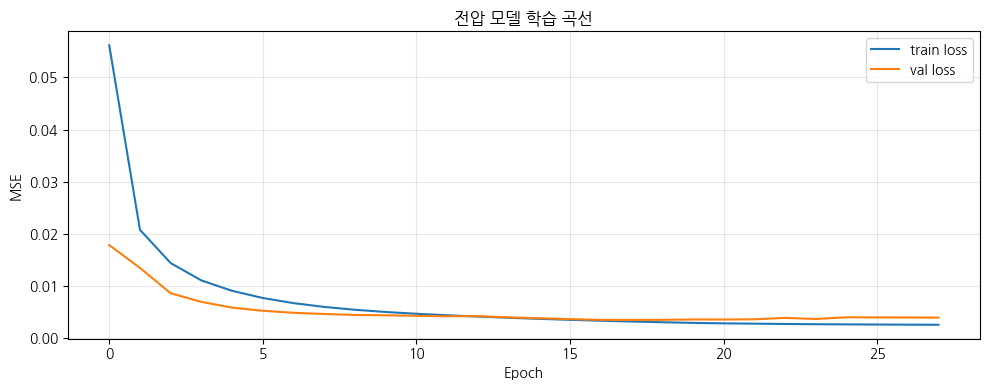

최종 train=0.002628, val=0.003994


In [36]:
# ── 전압 모델 빌드 ──
VOLT_DIM = X_train_volt.shape[2]   # 32 (cell_dev 16 + mod_dev 16)
TEMP_DIM = X_train_temp.shape[2]   # 16 (temp_dev 16)

def build_lstm_autoencoder(window_size, features_dim, latent_dim, name='model'):
    inputs = Input(shape=(window_size, features_dim), name='input')

    x = LSTM(64, return_sequences=True, name='enc_lstm1')(inputs)
    x = Dropout(0.2)(x)
    x = LSTM(32, return_sequences=False, name='enc_lstm2')(x)
    x = Dropout(0.2)(x)
    encoded = Dense(latent_dim, activation='relu', name='latent')(x)

    x = RepeatVector(window_size, name='repeat')(encoded)
    x = LSTM(32, return_sequences=True, name='dec_lstm1')(x)
    x = Dropout(0.2)(x)
    x = LSTM(64, return_sequences=True, name='dec_lstm2')(x)
    x = Dropout(0.2)(x)
    decoded = TimeDistributed(Dense(features_dim), name='output')(x)

    model = Model(inputs, decoded, name=name)
    return model


# 전압 모델
model_volt = build_lstm_autoencoder(WIN_SIZE, VOLT_DIM, LATENT_DIM, name='volt_autoencoder')
model_volt.compile(optimizer=tf.keras.optimizers.Adam(0.0001), loss='mse')
model_volt.summary()

# 학습
print("\n전압 모델 학습 시작 ...")
callbacks_volt = [
    EarlyStopping(monitor='val_loss', patience=10, min_delta=1e-6,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=os.path.join(ckpt_dir, 'best_volt_model.keras'),
                    monitor='val_loss', save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                      min_lr=1e-6, verbose=1)
]

history_volt = model_volt.fit(
    X_train_volt, X_train_volt,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=callbacks_volt,
    shuffle=True,
    verbose=1
)

# 학습 곡선
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_volt.history['loss'],     label='train loss')
ax.plot(history_volt.history['val_loss'], label='val loss')
ax.set_title('전압 모델 학습 곡선')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"최종 train={history_volt.history['loss'][-1]:.6f}, val={history_volt.history['val_loss'][-1]:.6f}")

Model: "temp_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 100, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm1 (LSTM)                │ (None, 100, 64)        │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm2 (LSTM)                │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm1 (LSTM)                │ (None, 100, 32)        │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm2 (LSTM)                │ (None, 100, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 100, 16)        │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,400 (267.19 KB)

 Trainable params: 68,400 (267.19 KB)

 Non-trainable params: 0 (0.00 B)


온도 모델 학습 시작 ...
Epoch 1/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 25s 104ms/step - loss: 0.0889 - val_loss: 0.0210 - learning_rate: 1.0000e-04
Epoch 2/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - loss: 0.0332 - val_loss: 0.0171 - learning_rate: 1.0000e-04
Epoch 3/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 18s 82ms/step - loss: 0.0273 - val_loss: 0.0154 - learning_rate: 1.0000e-04
Epoch 4/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 15s 68ms/step - loss: 0.0240 - val_loss: 0.0142 - learning_rate: 1.0000e-04
Epoch 5/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - loss: 0.0211 - val_loss: 0.0127 - learning_rate: 1.0000e-04
Epoch 6/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 24s 106ms/step - loss: 0.0188 - val_loss: 0.0115 - learning_rate: 1.0000e-04
Epoch 7/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - loss: 0.0174 - val_loss: 0.0107 - learning_rate: 1.0000e-04
Epoch 8/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 17s 75ms/step - loss: 0.0162 - val_loss: 0.0102 - learning_rate: 1.0000e-04
Epoch 9/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 17s 75ms/step

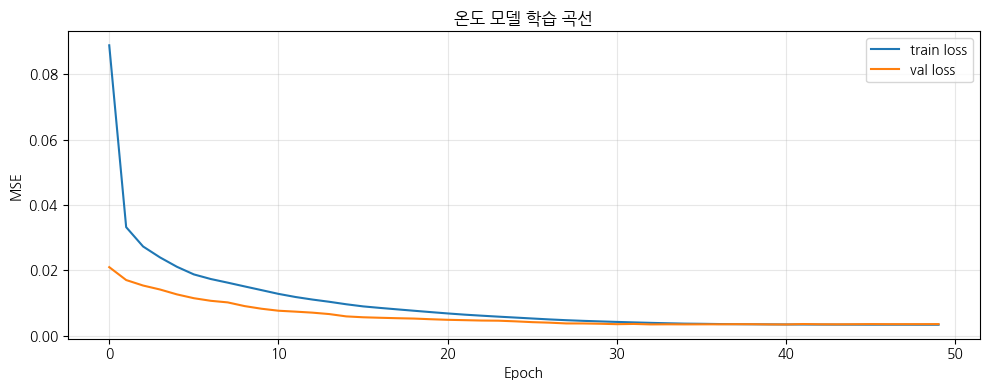

최종 train=0.003361, val=0.003561


In [37]:
# ── 온도 모델 빌드 및 학습 ──
model_temp = build_lstm_autoencoder(WIN_SIZE, TEMP_DIM, LATENT_DIM, name='temp_autoencoder')
model_temp.compile(optimizer=tf.keras.optimizers.Adam(0.0001), loss='mse')
model_temp.summary()

print("\n온도 모델 학습 시작 ...")
callbacks_temp = [
    EarlyStopping(monitor='val_loss', patience=10, min_delta=1e-6,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=os.path.join(ckpt_dir, 'best_temp_model.keras'),
                    monitor='val_loss', save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                      min_lr=1e-6, verbose=1)
]

history_temp = model_temp.fit(
    X_train_temp, X_train_temp,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=callbacks_temp,
    shuffle=True,
    verbose=1
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_temp.history['loss'],     label='train loss')
ax.plot(history_temp.history['val_loss'], label='val loss')
ax.set_title('온도 모델 학습 곡선')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"최종 train={history_temp.history['loss'][-1]:.6f}, val={history_temp.history['val_loss'][-1]:.6f}")

train 재구성 오차 계산 중 ...

전압 임계값: 0.012477
온도 임계값: 0.009682


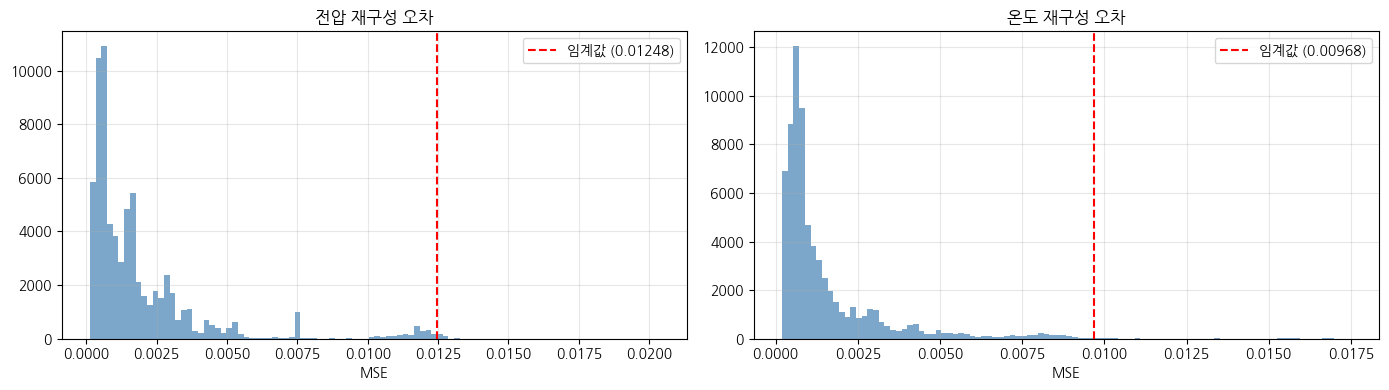

In [38]:
# ── 전압/온도 각각 임계값 설정 ──
print("train 재구성 오차 계산 중 ...")

# 전압 임계값
X_pred_volt  = model_volt.predict(X_train_volt, batch_size=BATCH_SIZE, verbose=0)
errors_volt  = np.mean(np.mean((X_train_volt - X_pred_volt) ** 2, axis=2), axis=1)
threshold_v  = np.percentile(errors_volt, 99.5)
if threshold_v < history_volt.history['val_loss'][-1]:
    threshold_v = history_volt.history['val_loss'][-1] * 1.5
    print(f"전압 임계값 val_loss 기준 조정: {threshold_v:.6f}")

# 온도 임계값
X_pred_temp  = model_temp.predict(X_train_temp, batch_size=BATCH_SIZE, verbose=0)
errors_temp  = np.mean(np.mean((X_train_temp - X_pred_temp) ** 2, axis=2), axis=1)
threshold_t  = np.percentile(errors_temp, 99.5)
if threshold_t < history_temp.history['val_loss'][-1]:
    threshold_t = history_temp.history['val_loss'][-1] * 1.5
    print(f"온도 임계값 val_loss 기준 조정: {threshold_t:.6f}")

print(f"\n전압 임계값: {threshold_v:.6f}")
print(f"온도 임계값: {threshold_t:.6f}")

# 오차 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, errors, threshold, title in zip(
    axes,
    [errors_volt, errors_temp],
    [threshold_v, threshold_t],
    ['전압 재구성 오차', '온도 재구성 오차']
):
    ax.hist(errors, bins=100, alpha=0.7, color='steelblue')
    ax.axvline(threshold, color='red', linestyle='--',
               label=f'임계값 ({threshold:.5f})')
    ax.set_title(title); ax.set_xlabel('MSE')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [42]:
TEST_DIR = os.path.join(os.getcwd(), "data", "raw_data", "test")
LABEL_DIR = os.path.join(os.getcwd(), "data", "preprocessed", "test")
# ── test 이상탐지 실행 (전압 + 온도 합산) ──
def detect_anomalies_dual(df, label=''):
    """전압/온도 모델 각각 재구성 오차 계산 후 합산"""
    df = add_derived_features(df)

    # 전압 시퀀스
    vc    = list(dict.fromkeys(get_volt_cols(df)))
    X_v   = scaler_v.transform(imputer_v.transform(df[vc]))
    seq_v = make_sequences(X_v, WIN_SIZE, step_size=1)

    # 온도 시퀀스
    tc    = list(dict.fromkeys(get_temp_cols(df)))
    X_t   = scaler_t.transform(imputer_t.transform(df[tc]))
    seq_t = make_sequences(X_t, WIN_SIZE, step_size=1)

    if len(seq_v) == 0 or len(seq_t) == 0:
        print(f"[{label}] 데이터 부족")
        return [], np.array([]), np.array([]), np.array([])

    # 재구성 오차
    pred_v = model_volt.predict(seq_v, batch_size=BATCH_SIZE, verbose=0)
    pred_t = model_temp.predict(seq_t, batch_size=BATCH_SIZE, verbose=0)

    huber  = tf.keras.losses.Huber()
    err_v  = np.array([float(huber(seq_v[i], pred_v[i]).numpy()) for i in range(len(seq_v))])
    err_t  = np.array([float(huber(seq_t[i], pred_t[i]).numpy()) for i in range(len(seq_t))])

    # 각각 정규화 후 합산
    z_v = (err_v - err_v.mean()) / (err_v.std() + 1e-8)
    z_t = (err_t - err_t.mean()) / (err_t.std() + 1e-8)
    combined = z_v + z_t   # 합산

    # 임계값 초과 구간 → 이상 구간
    # 각각 임계값 초과 여부 OR 조건
    is_anomaly = (err_v > threshold_v) | (err_t > threshold_t)
    anomalies  = []
    in_ng      = False
    for t in range(len(is_anomaly)):
        if is_anomaly[t] and not in_ng:
            ng_start = t; in_ng = True
        elif not is_anomaly[t] and in_ng:
            anomalies.append((ng_start, t - 1))
            in_ng = False
    if in_ng:
        anomalies.append((ng_start, len(is_anomaly) - 1))

    print(f"[{label}] 탐지 구간={len(anomalies)}")
    for s, e in anomalies:
        print(f"  → {s} ~ {e} (길이: {e-s+1})")

    return anomalies, err_v, err_t, combined


# ── 전체 test 실행 ──
all_results = {}

for fname in sorted(os.listdir(TEST_DIR)):
    if not fname.endswith('.csv'):
        continue
    stem       = fname.replace('.csv', '')
    label_path = os.path.join(LABEL_DIR, stem + '_Label.csv')
    if not os.path.exists(label_path):
        print(f"[skip] 라벨 없음: {fname}")
        continue

    test_df  = pd.read_csv(os.path.join(TEST_DIR, fname))
    gt_label = pd.read_csv(label_path)['label'].values

    anomalies, err_v, err_t, combined = detect_anomalies_dual(test_df, label=stem)

    all_results[stem] = {
        'anomalies': anomalies,
        'err_volt' : err_v,
        'err_temp' : err_t,
        'combined' : combined,
        'gt_label' : gt_label,
    }

print("\n" + "=" * 60)
print("이상탐지 요약")
print("=" * 60)
for name, res in all_results.items():
    ng_gt   = int(res['gt_label'].sum())
    ng_pred = sum(e - s + 1 for s, e in res['anomalies'])
    print(f"  {name}: GT={ng_gt}행, 예측={ng_pred}행, 구간={len(res['anomalies'])}")

[Test01_OK_chg] 탐지 구간=1
  → 399 ~ 606 (길이: 208)
[Test02_OK_dchg] 탐지 구간=0
[Test03_OK_chg] 탐지 구간=0
[Test04_OK_dchg] 탐지 구간=0
[Test05_NG_chg] 탐지 구간=0
[Test06_NG_chg] 탐지 구간=1
  → 0 ~ 753 (길이: 754)
[Test07_NG_dchg] 탐지 구간=1
  → 4391 ~ 4493 (길이: 103)
[Test08_NG_chg] 탐지 구간=2
  → 0 ~ 185 (길이: 186)
  → 368 ~ 2295 (길이: 1928)
[Test09_NG_dchg] 탐지 구간=3
  → 0 ~ 296 (길이: 297)
  → 360 ~ 662 (길이: 303)
  → 2146 ~ 4763 (길이: 2618)

이상탐지 요약
  Test01_OK_chg: GT=0행, 예측=208행, 구간=1
  Test02_OK_dchg: GT=0행, 예측=0행, 구간=0
  Test03_OK_chg: GT=0행, 예측=0행, 구간=0
  Test04_OK_dchg: GT=0행, 예측=0행, 구간=0
  Test05_NG_chg: GT=4259행, 예측=0행, 구간=0
  Test06_NG_chg: GT=854행, 예측=754행, 구간=1
  Test07_NG_dchg: GT=227행, 예측=103행, 구간=1
  Test08_NG_chg: GT=2396행, 예측=2114행, 구간=2
  Test09_NG_dchg: GT=4864행, 예측=3218행, 구간=3


In [ ]:
# ── 결과 시각화 (전압/온도 오차 + 합산 점수) ──
for name, res in all_results.items():
    err_v    = res['err_volt']
    err_t    = res['err_temp']
    combined = res['combined']
    anomalies = res['anomalies']
    gt_label  = res['gt_label']

    if len(err_v) == 0:
        continue

    fig, axes = plt.subplots(3, 1, figsize=(22, 10), sharex=True)

    labels_data = [
        (err_v,    threshold_v, '전압 재구성 오차 (MSE)', 'steelblue'),
        (err_t,    threshold_t, '온도 재구성 오차 (MSE)', 'darkorange'),
        (combined, None,        '합산 Z-score',           'purple'),
    ]

    for ax, (data, thresh, title, color) in zip(axes, labels_data):
        ax.plot(data, color=color, linewidth=0.8, alpha=0.8, label=title)
        if thresh:
            ax.axhline(thresh, color='red', linestyle='--',
                       linewidth=1.2, label=f'임계값 ({thresh:.5f})')

        # GT 음영 (빨강)
        gt_len = min(len(gt_label), len(data))
        in_ng  = False
        for t in range(gt_len):
            if gt_label[t] == 1 and not in_ng:
                ng_start = t; in_ng = True
            elif gt_label[t] == 0 and in_ng:
                ax.axvspan(ng_start, t, color='red', alpha=0.15, label='GT 이상')
                in_ng = False
        if in_ng:
            ax.axvspan(ng_start, gt_len, color='red', alpha=0.15, label='GT 이상')

        # 예측 음영 (파랑)
        for s, e in anomalies:
            ax.axvspan(max(0, s), min(e, len(data)-1),
                       color='blue', alpha=0.15, label='예측 이상')

        handles, labels_leg = ax.get_legend_handles_labels()
        ax.legend(dict(zip(labels_leg, handles)).values(),
                  dict(zip(labels_leg, handles)).keys(), loc='upper left')
        ax.set_ylabel(title)
        ax.grid(True, alpha=0.3)

    axes[0].set_title(f'{name} | 빨강=GT, 파랑=예측', fontsize=13)
    axes[2].set_xlabel('Time Step')
    plt.tight_layout()
    plt.show()

    ng_gt   = int(gt_label.sum())
    ng_pred = sum(e - s + 1 for s, e in anomalies)
    print(f"{name} | GT={ng_gt}행, 예측={ng_pred}행\n")

In [44]:
# ── 모델 저장 ──
model_volt.save(os.path.join(ckpt_dir, 'volt_autoencoder_final.keras'))
model_temp.save(os.path.join(ckpt_dir, 'temp_autoencoder_final.keras'))
print(f"전압 모델 저장 완료 → {ckpt_dir}/volt_autoencoder_final.keras")
print(f"온도 모델 저장 완료 → {ckpt_dir}/temp_autoencoder_final.keras")

# 나중에 불러올 때
# model_volt = tf.keras.models.load_model(os.path.join(ckpt_dir, 'volt_autoencoder_final.keras'))
# model_temp = tf.keras.models.load_model(os.path.join(ckpt_dir, 'temp_autoencoder_final.keras'))

전압 모델 저장 완료 → /mnt/c/Users/Administrator/github/project2/checkpoints_lstm/volt_autoencoder_final.keras
온도 모델 저장 완료 → /mnt/c/Users/Administrator/github/project2/checkpoints_lstm/temp_autoencoder_final.keras


- LSTM은 추세를 반영하는 모델이다보니 추세에 대해서만 반영하고 크기에 대해서는 고려되지 않는다. 따라서 크기에 대한 보강, 그리고 적은 특징성에 대해서 보완이 필요하다.

# 2. Hybrid 모델링

In [33]:
OUTPUT_DIR = './hybrid_outputs'

INPUT_DIR = "./data/raw_data/train"
TEST_RAW_DIR = "./data/raw_data/test"
TEST_LABEL_DIR = "./data/preprocessed/test"

In [34]:
# 모델링을 위한 클래스 및 함수 세팅
from __future__ import annotations

import os
import re
import json
from dataclasses import dataclass, field, asdict
from typing import Dict, List, Optional, Tuple

import joblib
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
import matplotlib.pyplot as plt

CV_RE = re.compile(r"^M(\d{2})CV(\d{2})$")
T_RE = re.compile(r"^M(\d{2})T(\d{2})$")
TRAIN_FILE_RE = re.compile(r"^(?P<id>\d{4})_(?P<mode>chg|dchg)\.csv$", re.IGNORECASE)
OK_FILE_RE = re.compile(r"^Test\d+_OK_(?P<mode>chg|dchg)\.csv$", re.IGNORECASE)

DEFAULT_BAD_IDS = {
    "chg": {"1009", "1017", "1019", "1026", "1030", "1035", "1036", "1038", "1043"},
    "dchg": {"1013", "1014", "1015", "1016", "1017", "1036", "1043"},
}


@dataclass
class HybridConfig:
    input_dir: str = "."
    mode: str = "charge"  # charge | discharge
    train_files: Optional[List[str]] = None
    include_ok_as_normal: bool = True
    scaler_type: str = "robust"  # robust | standard | minmax
    pca_components: int = 12
    window: int = 100
    step: int = 5
    contamination: float = 0.01
    random_state: int = 42
    output_dir: str = "./hybrid_outputs"
    use_defect_features: bool = True  # 4개 defect score를 각각 feature로 사용
    defect_type_threshold: float = 2.5
    exclude_ids: Dict[str, set] = field(default_factory=lambda: {k: set(v) for k, v in DEFAULT_BAD_IDS.items()})


@dataclass
class HybridModel:
    config: HybridConfig
    raw_scaler: object
    eng_scaler: object
    pca: PCA
    iforest: IsolationForest
    window_threshold: float
    train_score_summary: Dict[str, float]
    defect_baseline: Dict[str, Dict[str, float]]
    raw_feature_names: List[str]
    eng_feature_names: List[str]
    defect_feature_names: List[str]
    train_files: List[str]


def _mode_to_suffix(mode: str) -> str:
    mode = mode.lower()
    if mode in ("charge", "chg"):
        return "chg"
    if mode in ("discharge", "dchg"):
        return "dchg"
    raise ValueError("mode must be one of: charge, discharge, chg, dchg")


def _sorted_sensor_cols(columns, regex):
    matched = []
    for c in columns:
        m = regex.match(c)
        if m:
            matched.append((int(m.group(1)), int(m.group(2)), c))
    return [c for _, _, c in sorted(matched)]


def _get_module_cols(columns, module_no: int, kind: str) -> List[str]:
    regex = CV_RE if kind == "CV" else T_RE
    cols = []
    for c in columns:
        m = regex.match(c)
        if m and int(m.group(1)) == module_no:
            cols.append((int(m.group(2)), c))
    return [c for _, c in sorted(cols)]


def _choose_scaler(name: str):
    name = name.lower()
    if name == "robust":
        return RobustScaler()
    if name == "standard":
        return StandardScaler()
    if name == "minmax":
        return MinMaxScaler(feature_range=(-1, 1))
    raise ValueError("scaler_type must be one of: robust, standard, minmax")


def collect_train_files(cfg: HybridConfig) -> List[str]:
    if cfg.train_files:
        return [f for f in cfg.train_files if os.path.exists(f)]

    suffix = _mode_to_suffix(cfg.mode)
    found = []
    for fn in sorted(os.listdir(cfg.input_dir)):
        p = os.path.join(cfg.input_dir, fn)
        if not os.path.isfile(p):
            continue
        m = TRAIN_FILE_RE.match(fn)
        if m and m.group("mode").lower() == suffix and m.group("id") not in cfg.exclude_ids[suffix]:
            found.append(p)
            continue
        if cfg.include_ok_as_normal:
            m2 = OK_FILE_RE.match(fn)
            if m2 and m2.group("mode").lower() == suffix:
                found.append(p)
    return found


def read_df(path: str) -> pd.DataFrame:
    return pd.read_csv(path)


def get_voltage_temp_cols(df: pd.DataFrame) -> Tuple[List[str], List[str]]:
    volt_cols = _sorted_sensor_cols(df.columns, CV_RE)
    temp_cols = _sorted_sensor_cols(df.columns, T_RE)
    return volt_cols, temp_cols


def build_row_normalized_raw(df: pd.DataFrame) -> pd.DataFrame:
    volt_cols, temp_cols = get_voltage_temp_cols(df)

    V = df[volt_cols].apply(pd.to_numeric, errors="coerce").copy()
    T = df[temp_cols].apply(pd.to_numeric, errors="coerce").copy()

    # Pack-relative normalization to preserve local imbalance patterns.
    V = V.sub(V.median(axis=1), axis=0)
    T = T.sub(T.mean(axis=1), axis=0)

    Vd = V.diff().fillna(0.0).add_suffix("_d")
    Td = T.diff().fillna(0.0).add_suffix("_d")

    X = pd.concat([V, T, Vd, Td], axis=1)

    # inf / -inf -> NaN
    X = X.replace([np.inf, -np.inf], np.nan)

    # 1차 보간 + 앞뒤 채움 + 최종 0 대체
    X = X.interpolate(limit_direction="both")
    X = X.ffill().bfill().fillna(0.0)

    return X


def build_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    volt_cols, temp_cols = get_voltage_temp_cols(df)
    V = df[volt_cols].astype(float)
    T = df[temp_cols].astype(float)

    out = {
        "pack_v_mean": V.mean(axis=1),
        "pack_v_std": V.std(axis=1),
        "pack_v_rng": V.max(axis=1) - V.min(axis=1),
        "pack_t_mean": T.mean(axis=1),
        "pack_t_std": T.std(axis=1),
        "pack_t_rng": T.max(axis=1) - T.min(axis=1),
    }
    if "Voltage" in df.columns:
        out["pack_voltage"] = df["Voltage"].astype(float)
        out["pack_voltage_d"] = df["Voltage"].astype(float).diff().fillna(0.0)
    if "Current" in df.columns:
        out["pack_current"] = df["Current"].astype(float)
        out["pack_current_d"] = df["Current"].astype(float).diff().fillna(0.0)

    for mod in range(1, 17):
        mcols = _get_module_cols(df.columns, mod, "CV")
        if mcols:
            M = df[mcols].astype(float)
            out[f"M{mod:02d}_v_mean"] = M.mean(axis=1)
            out[f"M{mod:02d}_v_std"] = M.std(axis=1)
            out[f"M{mod:02d}_v_rng"] = M.max(axis=1) - M.min(axis=1)
            arr = M.to_numpy()
            if arr.shape[1] > 1:
                adj = np.abs(arr[:, 1:] - arr[:, :-1])
                out[f"M{mod:02d}_adj_max"] = adj.max(axis=1)
                out[f"M{mod:02d}_adj_mean"] = adj.mean(axis=1)

        tcols = _get_module_cols(df.columns, mod, "T")
        if len(tcols) >= 2:
            Tm = df[tcols].astype(float)
            out[f"M{mod:02d}_t_mean"] = Tm.mean(axis=1)
            out[f"M{mod:02d}_t_rng"] = Tm.max(axis=1) - Tm.min(axis=1)
            out[f"M{mod:02d}_t_pairdiff"] = np.abs(Tm.iloc[:, 0] - Tm.iloc[:, 1])

    F = pd.DataFrame(out).fillna(0.0)
    # Add first-order dynamics without fragmenting the DataFrame.
    diff_df = F.diff().fillna(0.0)
    diff_df.columns = [f"{c}_d" for c in F.columns]
    return pd.concat([F, diff_df], axis=1)


def aggregate_windows(X: pd.DataFrame, window: int, step: int) -> Tuple[np.ndarray, List[str], List[Tuple[int, int]]]:
    arr = np.asarray(X, dtype=float)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)

    if arr.ndim != 2:
        arr = np.atleast_2d(arr)

    if len(arr) < window:
        # fallback to one padded window
        pad = np.repeat(arr[-1:, :], window - len(arr), axis=0) if len(arr) > 0 else np.zeros((window, X.shape[1]))
        arr = np.vstack([arr, pad])

    ranges = []
    rows = []
    names = list(X.columns)
    for start in range(0, len(arr) - window + 1, step):
        seg = arr[start:start + window]
        seg = np.nan_to_num(seg, nan=0.0, posinf=0.0, neginf=0.0)
        feat = np.concatenate([
            np.nan_to_num(seg.mean(axis=0), nan=0.0, posinf=0.0, neginf=0.0),
            np.nan_to_num(seg.std(axis=0), nan=0.0, posinf=0.0, neginf=0.0),
            np.nan_to_num(seg.max(axis=0), nan=0.0, posinf=0.0, neginf=0.0),
            np.nan_to_num(seg.min(axis=0), nan=0.0, posinf=0.0, neginf=0.0),
            np.nan_to_num(seg[-1] - seg[0], nan=0.0, posinf=0.0, neginf=0.0),
        ])
        feat = np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0)
        rows.append(feat)
        ranges.append((start, start + window - 1))

    cols = []
    for stat in ["mean", "std", "max", "min", "delta"]:
        cols.extend([f"{c}_{stat}" for c in names])

    rows = np.asarray(rows, dtype=float)
    rows = np.nan_to_num(rows, nan=0.0, posinf=0.0, neginf=0.0)
    return rows, cols, ranges
def compute_defect_scores(df: pd.DataFrame) -> Dict[str, object]:
    volt_cols, temp_cols = get_voltage_temp_cols(df)
    V = df[volt_cols].astype(float).to_numpy()
    n = len(df)
    head = max(10, n // 5)
    tail = max(10, n // 5)

    # 1) Capacity defect: charge-tail divergence / imbalance growth.
    global_med = np.median(V, axis=1, keepdims=True)
    # Capacity imbalance is usually gradual, so clip extreme spikes that belong
    # more naturally to wire/measurement faults than to true capacity drift.
    global_dev = np.clip(np.abs(V - global_med), 0.0, 0.05)
    global_growth = float(global_dev[-tail:].mean() - global_dev[:head].mean())
    global_top1_growth = float(
        np.quantile(global_dev[-tail:].max(axis=1), 0.95)
        - np.quantile(global_dev[:head].max(axis=1), 0.95)
    )
    best_capacity_score = -np.inf
    best_capacity_cell = None
    for mod in range(1, 17):
        mcols = _get_module_cols(df.columns, mod, "CV")
        if len(mcols) < 2:
            continue
        arr = df[mcols].astype(float).to_numpy()
        med = np.median(arr, axis=1, keepdims=True)
        dev = np.clip(np.abs(arr - med), 0.0, 0.05)
        growth = dev[-tail:].mean(axis=0) - dev[:head].mean(axis=0)
        idx = int(np.argmax(growth))
        score = float(np.quantile(growth, 0.95))
        if score > best_capacity_score:
            best_capacity_score = score
            best_capacity_cell = mcols[idx]
    capacity_score = float(global_growth + global_top1_growth + best_capacity_score)

    # 2) Welding / persistent low-voltage defect.
    best_weld_score = -np.inf
    best_weld_cell = None
    for mod in range(1, 17):
        mcols = _get_module_cols(df.columns, mod, "CV")
        if len(mcols) < 2:
            continue
        arr = df[mcols].astype(float).to_numpy()
        med = np.median(arr, axis=1, keepdims=True)
        drop = np.maximum(med - arr, 0.0)
        jump = np.diff(drop, axis=0, prepend=drop[[0], :])
        cell_scores = drop.mean(axis=0) + np.quantile(drop, 0.99, axis=0) + np.quantile(jump, 0.99, axis=0)
        idx = int(np.argmax(cell_scores))
        score = float(cell_scores[idx])
        if score > best_weld_score:
            best_weld_score = score
            best_weld_cell = mcols[idx]

    # 3) Sensing wire defect: adjacent pair separation + abrupt jump.
    best_wire_score = -np.inf
    best_wire_pair = None
    for mod in range(1, 17):
        mcols = _get_module_cols(df.columns, mod, "CV")
        if len(mcols) < 2:
            continue
        arr = df[mcols].astype(float).to_numpy()
        adj = np.abs(arr[:, 1:] - arr[:, :-1])
        adj_jump = np.abs(np.diff(adj, axis=0)) if len(arr) > 1 else np.zeros_like(adj)
        pair_scores = np.quantile(adj, 0.99, axis=0) + np.quantile(adj_jump, 0.99, axis=0)
        idx = int(np.argmax(pair_scores))
        score = float(pair_scores[idx])
        if score > best_wire_score:
            best_wire_score = score
            best_wire_pair = (mcols[idx], mcols[idx + 1])

    # 4) Sensor fault: same-module temperature pair offset.
    best_sensor_score = -np.inf
    best_sensor = None
    best_sensor_peer = None
    for mod in range(1, 17):
        tcols = _get_module_cols(df.columns, mod, "T")
        if len(tcols) < 2:
            continue
        t1 = df[tcols[0]].astype(float).to_numpy()
        t2 = df[tcols[1]].astype(float).to_numpy()
        diff = np.abs(t1 - t2)
        score = float(diff.mean() + np.quantile(diff, 0.99))
        if score > best_sensor_score:
            best_sensor_score = score
            module_mean = (t1 + t2) / 2.0
            d1 = np.mean(np.abs(t1 - module_mean))
            d2 = np.mean(np.abs(t2 - module_mean))
            best_sensor = tcols[0] if d1 >= d2 else tcols[1]
            best_sensor_peer = tcols[1] if best_sensor == tcols[0] else tcols[0]

    return {
        "capacity_score": capacity_score,
        "capacity_cell": best_capacity_cell,
        "weld_score": float(best_weld_score),
        "weld_cell": best_weld_cell,
        "wire_score": float(best_wire_score),
        "wire_pair": best_wire_pair,
        "sensor_score": float(best_sensor_score),
        "sensor_sensor": best_sensor,
        "sensor_peer": best_sensor_peer,
    }


def fit_defect_baseline(train_files: List[str]) -> Dict[str, Dict[str, float]]:
    rows = []
    for f in train_files:
        rows.append(compute_defect_scores(read_df(f)))
    df = pd.DataFrame(rows)
    baseline = {}
    for col in ["capacity_score", "weld_score", "wire_score", "sensor_score"]:
        vals = df[col].astype(float).values
        med = float(np.median(vals))
        iqr = float(np.subtract(*np.percentile(vals, [75, 25])))
        scale = max(iqr, 0.1 * abs(med), 1e-6)
        baseline[col] = {
            "median": med,
            "scale": float(scale),
            "q95": float(np.quantile(vals, 0.95)),
            "max": float(np.max(vals)),
        }
    return baseline


def defect_ratios(scores: Dict[str, object], baseline: Dict[str, Dict[str, float]]) -> Dict[str, float]:
    mapping = {
        "capacity": "capacity_score",
        "weld": "weld_score",
        "wire": "wire_score",
        "sensor": "sensor_score",
    }
    ratios = {}
    for name, col in mapping.items():
        raw_score = scores.get(col, 0.0)
        try:
            raw_score = float(raw_score)
        except Exception:
            raw_score = 0.0
        if not np.isfinite(raw_score):
            raw_score = 0.0

        med = float(baseline.get(col, {}).get("median", 0.0))
        scale = float(baseline.get(col, {}).get("scale", 1.0))

        if not np.isfinite(med):
            med = 0.0
        if (not np.isfinite(scale)) or (abs(scale) < 1e-8):
            scale = 1.0

        z = (raw_score - med) / scale
        if not np.isfinite(z):
            z = 0.0
        ratios[name] = float(z)
    return ratios


DEFECT_FEATURE_NAMES = [
    "defect_capacity_z",
    "defect_weld_z",
    "defect_wire_z",
    "defect_sensor_z",
]
def build_defect_feature_frame(
    df: pd.DataFrame,
    baseline: Dict[str, Dict[str, float]],
    n_rows: Optional[int] = None,
) -> pd.DataFrame:
    defect = compute_defect_scores(df)
    ratios = defect_ratios(defect, baseline)
    if n_rows is None:
        n_rows = len(df)
    values = np.column_stack([
        np.full(n_rows, float(ratios.get("capacity", 0.0)), dtype=float),
        np.full(n_rows, float(ratios.get("weld", 0.0)), dtype=float),
        np.full(n_rows, float(ratios.get("wire", 0.0)), dtype=float),
        np.full(n_rows, float(ratios.get("sensor", 0.0)), dtype=float),
    ])
    values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
    return pd.DataFrame(values, columns=DEFECT_FEATURE_NAMES)
def prepare_training_matrices(
    train_files: List[str],
    cfg: HybridConfig,
    defect_baseline: Optional[Dict[str, Dict[str, float]]] = None,
):
    raw_all = []
    eng_all = []
    defect_all = []
    use_defect_features = bool(cfg.use_defect_features and defect_baseline is not None)

    for f in train_files:
        df = read_df(f)
        raw_all.append(build_row_normalized_raw(df))
        eng_all.append(build_engineered_features(df))
        if use_defect_features:
            defect_all.append(build_defect_feature_frame(df, defect_baseline, n_rows=len(df)))

    raw_concat = pd.concat(raw_all, axis=0, ignore_index=True)
    eng_concat = pd.concat(eng_all, axis=0, ignore_index=True)

    raw_concat = raw_concat.replace([np.inf, -np.inf], np.nan)
    eng_concat = eng_concat.replace([np.inf, -np.inf], np.nan)

    raw_concat = raw_concat.interpolate(limit_direction="both").ffill().bfill().fillna(0.0)
    eng_concat = eng_concat.interpolate(limit_direction="both").ffill().bfill().fillna(0.0)

    raw_scaler = _choose_scaler(cfg.scaler_type)
    eng_scaler = _choose_scaler(cfg.scaler_type)

    raw_scaled = raw_scaler.fit_transform(raw_concat)
    eng_scaled = eng_scaler.fit_transform(eng_concat)

    raw_scaled = np.nan_to_num(raw_scaled, nan=0.0, posinf=0.0, neginf=0.0)
    eng_scaled = np.nan_to_num(eng_scaled, nan=0.0, posinf=0.0, neginf=0.0)

    pca = PCA(
        n_components=min(cfg.pca_components, raw_scaled.shape[1]),
        random_state=cfg.random_state
    )
    pca.fit(raw_scaled)

    window_rows = []
    window_cols = None
    defect_feature_names = list(DEFECT_FEATURE_NAMES) if use_defect_features else []
    for f in train_files:
        df = read_df(f)
        raw = raw_scaler.transform(build_row_normalized_raw(df))
        raw = np.nan_to_num(raw, nan=0.0, posinf=0.0, neginf=0.0)
        pcs = pca.transform(raw)
        pcs = np.nan_to_num(pcs, nan=0.0, posinf=0.0, neginf=0.0)

        eng = eng_scaler.transform(build_engineered_features(df))
        eng = np.nan_to_num(eng, nan=0.0, posinf=0.0, neginf=0.0)

        blocks = [pcs, eng]
        cols = [f"pc{i+1}" for i in range(pcs.shape[1])] + list(eng_concat.columns)

        if use_defect_features:
            defect_df = build_defect_feature_frame(df, defect_baseline, n_rows=len(df))
            defect_arr = np.nan_to_num(defect_df.to_numpy(dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
            blocks.append(defect_arr)
            cols += defect_feature_names

        combined_arr = np.hstack(blocks)
        combined_arr = np.nan_to_num(combined_arr, nan=0.0, posinf=0.0, neginf=0.0)
        combined = pd.DataFrame(combined_arr, columns=cols)

        W, cols, _ = aggregate_windows(combined, cfg.window, cfg.step)
        W = np.nan_to_num(np.asarray(W, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)

        valid_mask = np.isfinite(W).all(axis=1)
        if not np.all(valid_mask):
            print(f"[WARN] Dropping invalid windows in {os.path.basename(f)}: {(~valid_mask).sum()} rows")
            W = W[valid_mask]

        if W.size == 0:
            print(f"[WARN] No valid windows from {os.path.basename(f)}; skipping")
            continue

        window_rows.append(W)
        window_cols = cols

    if not window_rows:
        raise ValueError("No valid training windows were created after NaN/inf filtering.")

    windows = np.vstack(window_rows)
    windows = np.nan_to_num(np.asarray(windows, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)

    valid_mask = np.isfinite(windows).all(axis=1)
    if not np.all(valid_mask):
        print(f"[WARN] Dropping invalid stacked windows: {(~valid_mask).sum()} rows")
        windows = windows[valid_mask]

    if windows.size == 0:
        raise ValueError("All training windows were removed because they contain NaN/inf.")

    return (
        raw_scaler,
        eng_scaler,
        pca,
        windows,
        window_cols,
        list(raw_concat.columns),
        list(eng_concat.columns),
        defect_feature_names,
    )
def train_hybrid_model(cfg: HybridConfig) -> HybridModel:
    os.makedirs(cfg.output_dir, exist_ok=True)
    train_files = collect_train_files(cfg)
    if not train_files:
        raise FileNotFoundError(f"No valid train files found in {cfg.input_dir} for mode={cfg.mode}")

    defect_baseline = fit_defect_baseline(train_files)

    (
        raw_scaler,
        eng_scaler,
        pca,
        windows,
        _,
        raw_feature_names,
        eng_feature_names,
        defect_feature_names,
    ) = prepare_training_matrices(train_files, cfg, defect_baseline=defect_baseline)

    windows = np.asarray(windows, dtype=float)
    windows = np.nan_to_num(windows, nan=0.0, posinf=0.0, neginf=0.0)
    valid_mask = np.isfinite(windows).all(axis=1)
    if not np.all(valid_mask):
        print(f"[WARN] Removed {(~valid_mask).sum()} invalid rows before IForest fit")
        windows = windows[valid_mask]

    if windows.size == 0 or len(windows) == 0:
        raise ValueError("No valid training rows remain after NaN/inf filtering.")

    iforest = IsolationForest(
        n_estimators=300,
        contamination=cfg.contamination,
        random_state=cfg.random_state,
    )
    iforest.fit(windows)
    train_scores = -iforest.score_samples(windows)
    train_scores = np.nan_to_num(train_scores, nan=0.0, posinf=0.0, neginf=0.0)
    window_threshold = float(np.quantile(train_scores, 0.995))

    model = HybridModel(
        config=cfg,
        raw_scaler=raw_scaler,
        eng_scaler=eng_scaler,
        pca=pca,
        iforest=iforest,
        window_threshold=window_threshold,
        train_score_summary={
            "mean": float(train_scores.mean()),
            "std": float(train_scores.std() + 1e-9),
            "q95": float(np.quantile(train_scores, 0.95)),
            "q99": float(np.quantile(train_scores, 0.99)),
        },
        defect_baseline=defect_baseline,
        raw_feature_names=raw_feature_names,
        eng_feature_names=eng_feature_names,
        defect_feature_names=defect_feature_names,
        train_files=train_files,
    )
    return model
def _combined_window_features(df: pd.DataFrame, model: HybridModel):
    raw_df = build_row_normalized_raw(df).replace([np.inf, -np.inf], np.nan)
    eng_df = build_engineered_features(df).replace([np.inf, -np.inf], np.nan)

    raw_df = raw_df.interpolate(limit_direction="both").ffill().bfill().fillna(0.0)
    eng_df = eng_df.interpolate(limit_direction="both").ffill().bfill().fillna(0.0)

    raw = model.raw_scaler.transform(raw_df)
    raw = np.nan_to_num(raw, nan=0.0, posinf=0.0, neginf=0.0)

    pcs = model.pca.transform(raw)
    pcs = np.nan_to_num(pcs, nan=0.0, posinf=0.0, neginf=0.0)

    eng = model.eng_scaler.transform(eng_df)
    eng = np.nan_to_num(eng, nan=0.0, posinf=0.0, neginf=0.0)

    blocks = [pcs, eng]
    cols = [f"pc{i+1}" for i in range(pcs.shape[1])] + model.eng_feature_names

    if model.config.use_defect_features and model.defect_feature_names:
        defect_df = build_defect_feature_frame(df, model.defect_baseline, n_rows=len(df))
        defect_arr = np.nan_to_num(defect_df.to_numpy(dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
        blocks.append(defect_arr)
        cols += model.defect_feature_names

    combined = pd.DataFrame(np.hstack(blocks), columns=cols)
    combined = combined.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    W, agg_cols, ranges = aggregate_windows(combined, model.config.window, model.config.step)
    W = np.nan_to_num(np.asarray(W, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
    valid_mask = np.isfinite(W).all(axis=1)
    if not np.all(valid_mask):
        W = W[valid_mask]
        ranges = [r for r, keep in zip(ranges, valid_mask) if keep]
    return W, agg_cols, ranges
def timestep_scores_from_windows(window_scores: np.ndarray, ranges: List[Tuple[int, int]], n_rows: int) -> np.ndarray:
    out = np.zeros(n_rows, dtype=float)
    counts = np.zeros(n_rows, dtype=float)
    for s, (a, b) in zip(window_scores, ranges):
        out[a:b + 1] += s
        counts[a:b + 1] += 1
    counts[counts == 0] = 1.0
    return out / counts


def score_file(model: HybridModel, file_path: str, label_path: Optional[str] = None) -> Dict[str, object]:
    df = read_df(file_path)
    W, _, ranges = _combined_window_features(df, model)
    window_scores = -model.iforest.score_samples(W)
    timestep_scores = timestep_scores_from_windows(window_scores, ranges, len(df))

    defect = compute_defect_scores(df)
    ratios = defect_ratios(defect, model.defect_baseline)
    weighted = ratios.copy()
    if _mode_to_suffix(model.config.mode) == "chg":
        weighted["capacity"] *= 1.2
    else:
        weighted["wire"] *= 1.1
    pred_type = max(weighted, key=weighted.get)
    type_score = max(0.0, max(weighted.values()))

    # Hybrid anomaly score: generic window anomaly + defect-type anomaly.
    window_q99 = float(np.quantile(window_scores, 0.99))
    generic_score = (window_q99 - model.train_score_summary["q95"]) / max(model.train_score_summary["std"], 1e-6)
    hybrid_score = max(type_score, generic_score)
    is_anomaly = bool((window_q99 > model.window_threshold) or (type_score > 2.5))

    metrics = None
    if label_path and os.path.exists(label_path):
        lab = pd.read_csv(label_path)
        y_true = lab.iloc[:, -1].astype(int).to_numpy()
        y_pred = (timestep_scores >= np.quantile(timestep_scores, 0.98)).astype(int)
        n = min(len(y_true), len(y_pred))
        y_true = y_true[:n]
        y_pred = y_pred[:n]
        tp = int(((y_true == 1) & (y_pred == 1)).sum())
        tn = int(((y_true == 0) & (y_pred == 0)).sum())
        fp = int(((y_true == 0) & (y_pred == 1)).sum())
        fn = int(((y_true == 1) & (y_pred == 0)).sum())
        precision = tp / (tp + fp + 1e-9)
        recall = tp / (tp + fn + 1e-9)
        f1 = 2 * precision * recall / (precision + recall + 1e-9)
        acc = (tp + tn) / max(len(y_true), 1)
        metrics = {
            "accuracy": float(acc),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
        }

    return {
        "file": file_path,
        "df": df,
        "window_scores": window_scores,
        "window_ranges": ranges,
        "timestep_scores": timestep_scores,
        "window_q99": window_q99,
        "generic_score": float(generic_score),
        "type_score": float(type_score),
        "hybrid_score": float(hybrid_score),
        "is_anomaly": is_anomaly,
        "pred_type": pred_type,
        "type_ratios": ratios,
        "defect": defect,
        "metrics": metrics,
    }


def plot_defect_dashboard(result: Dict[str, object], title: Optional[str] = None):
    df = result["df"]
    defect = result["defect"]
    ratios = result["type_ratios"]
    volt_cols, temp_cols = get_voltage_temp_cols(df)

    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    plt.subplots_adjust(hspace=0.35, wspace=0.25)

    # 1) Capacity defect
    for c in volt_cols:
        axes[0, 0].plot(df.index, df[c], color="lightgray", alpha=0.25)
    if defect["capacity_cell"] is not None:
        axes[0, 0].plot(
            df.index,
            df[defect["capacity_cell"]],
            color="red",
            linewidth=2.2,
            label=f"{defect['capacity_cell']} | score={ratios['capacity']:.2f}",
        )
    axes[0, 0].set_title(
        "1. Capacity defect (end-of-discharge deviation growth)",
        fontsize=14,
        fontweight="bold",
    )
    axes[0, 0].legend(loc="best")

    # 2) Weld / low voltage defect
    for c in volt_cols:
        axes[0, 1].plot(df.index, df[c], color="lightgray", alpha=0.25)
    if defect["weld_cell"] is not None:
        axes[0, 1].plot(
            df.index,
            df[defect["weld_cell"]],
            color="blue",
            linewidth=2.2,
            label=f"{defect['weld_cell']} | score={ratios['weld']:.2f}",
        )
    axes[0, 1].set_title(
        "2. Weld / low-voltage defect",
        fontsize=14,
        fontweight="bold",
    )
    axes[0, 1].legend(loc="best")

    # 3) Sensing wire defect
    for c in volt_cols:
        axes[1, 0].plot(df.index, df[c], color="lightgray", alpha=0.20)
    if defect["wire_pair"] is not None:
        a, b = defect["wire_pair"]
        axes[1, 0].plot(df.index, df[a], color="purple", linewidth=2.0, label=a)
        axes[1, 0].plot(
            df.index,
            df[b],
            color="green",
            linewidth=2.0,
            label=f"{b} | score={ratios['wire']:.2f}",
        )
    axes[1, 0].set_title(
        "3. Sensing wire defect (adjacent cell pair)",
        fontsize=14,
        fontweight="bold",
    )
    axes[1, 0].legend(loc="best")

    # 4) Temperature sensor defect
    for c in temp_cols:
        axes[1, 1].plot(df.index, df[c], color="lightgray", alpha=0.25)
    if defect["sensor_sensor"] is not None:
        s1 = defect["sensor_sensor"]
        s2 = defect["sensor_peer"]
        axes[1, 1].plot(
            df.index,
            df[s1],
            color="orange",
            linewidth=2.5,
            label=f"{s1} | score={ratios['sensor']:.2f}",
        )
        axes[1, 1].plot(
            df.index,
            df[s2],
            color="black",
            linewidth=1.4,
            linestyle="--",
            label=f"peer={s2}",
        )
    axes[1, 1].set_title(
        "4. Temperature sensor defect (module pair comparison)",
        fontsize=14,
        fontweight="bold",
    )
    axes[1, 1].legend(loc="best")

    t = title or os.path.basename(result["file"])
    plt.suptitle(
        f"{t}\nPredicted defect type: {result['pred_type']} | hybrid_score={result['hybrid_score']:.2f} | anomaly={result['is_anomaly']}",
        fontsize=20,
        fontweight="bold",
    )

    plt.show()


def plot_anomaly_timeline(result: Dict[str, object], threshold_quantile: float = 0.98):
    scores = np.asarray(result["timestep_scores"], dtype=float)
    df = result["df"]
    thr = float(np.quantile(scores, threshold_quantile))
    plt.figure(figsize=(16, 4))
    plt.plot(df.index, scores, label="timestep anomaly score")
    plt.axhline(thr, color="red", linestyle="--", label=f"q{int(threshold_quantile*100)}")
    plt.title(f"Anomaly timeline: {os.path.basename(result['file'])}")
    plt.xlabel("time index")
    plt.ylabel("score")
    plt.legend()
    plt.tight_layout()
    plt.show()


def save_model(model: HybridModel, path: str):
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    joblib.dump(model, path)


def load_model(path: str) -> HybridModel:
    return joblib.load(path)


def demo_train_and_score(input_dir: str, output_dir: str = "./hybrid_outputs"):
    # Charge model
    chg_cfg = HybridConfig(input_dir=input_dir, output_dir=output_dir, mode="charge", include_ok_as_normal=True)
    dchg_cfg = HybridConfig(input_dir=input_dir, output_dir=output_dir, mode="discharge", include_ok_as_normal=True)
    chg_model = train_hybrid_model(chg_cfg)
    dchg_model = train_hybrid_model(dchg_cfg)

    tests = [
        ("charge", os.path.join(input_dir, "Test05_NG_chg.csv"), None),
        ("charge", os.path.join(input_dir, "Test06_NG_chg.csv"), None),
        ("discharge", os.path.join(input_dir, "Test07_NG_dchg.csv"), None),
        ("charge", os.path.join(input_dir, "Test08_NG_chg.csv"), os.path.join(input_dir, "Test08_NG_chg_Label.csv")),
        ("discharge", os.path.join(input_dir, "Test09_NG_dchg.csv"), os.path.join(input_dir, "Test09_NG_dchg_Label.csv")),
    ]
    rows = []
    for mode, csv_path, label_path in tests:
        model = chg_model if mode == "charge" else dchg_model
        if os.path.exists(csv_path):
            res = score_file(model, csv_path, label_path)
            rows.append({
                "file": os.path.basename(csv_path),
                "pred_type": res["pred_type"],
                "hybrid_score": res["hybrid_score"],
                "is_anomaly": res["is_anomaly"],
                **{f"ratio_{k}": v for k, v in res["type_ratios"].items()},
            })
    summary = pd.DataFrame(rows)
    os.makedirs(output_dir, exist_ok=True)
    summary.to_csv(os.path.join(output_dir, "demo_summary.csv"), index=False)
    return summary

- charge 모델 학습

In [35]:
chg_cfg = HybridConfig(
    input_dir=INPUT_DIR,
    output_dir=OUTPUT_DIR,
    mode='charge',
    include_ok_as_normal=True,
    scaler_type='robust',
    pca_components=12,
    window=100,
    step=5,
)

chg_model = train_hybrid_model(chg_cfg)
chg_model.train_score_summary


{'mean': 0.4269871218282957,
 'std': 0.031906153038322005,
 'q95': 0.49131519078597186,
 'q99': 0.5469091670607077}

- decharge 모델 학습

In [36]:
dchg_cfg = HybridConfig(
    input_dir=INPUT_DIR,
    output_dir=OUTPUT_DIR,
    mode='discharge',
    include_ok_as_normal=True,
    scaler_type='robust',
    pca_components=12,
    window=100,
    step=5,
)

dchg_model = train_hybrid_model(dchg_cfg)
dchg_model.train_score_summary


{'mean': 0.42605769355896955,
 'std': 0.03508702109623863,
 'q95': 0.5099428905475897,
 'q99': 0.5482089804003398}

- 모델 저장

In [37]:
chg_model_path = os.path.join(OUTPUT_DIR, 'hybrid_charge_model.joblib')
dchg_model_path = os.path.join(OUTPUT_DIR, 'hybrid_discharge_model.joblib')

save_model(chg_model, chg_model_path)
save_model(dchg_model, dchg_model_path)

print(chg_model_path)
print(dchg_model_path)


./hybrid_outputs/hybrid_charge_model.joblib
./hybrid_outputs/hybrid_discharge_model.joblib


# 3. one_class의 다변량 시계열 데이터 사용

In [38]:
# one_class를 사용하기 위한 세팅
from __future__ import annotations

import itertools
import math
import pickle
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

SEED = 0
np.random.seed(SEED)

font_candidates = ['Noto Sans CJK KR', 'NanumSquare', 'NanumGothic', 'Malgun Gothic', 'AppleGothic']
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
selected_font = next((name for name in font_candidates if name in available_fonts), None)
if selected_font is not None:
    plt.rcParams['font.family'] = selected_font
plt.rcParams['axes.unicode_minus'] = False

PROJECT_DIR = Path.cwd().resolve()
project_candidates = [PROJECT_DIR, *PROJECT_DIR.parents]
for candidate in project_candidates:
    if (candidate / 'data' / 'raw_data' / 'train').exists():
        PROJECT_DIR = candidate
        break
else:
    child_matches = list(Path.cwd().resolve().glob('**/data/raw_data/train'))
    if child_matches:
        PROJECT_DIR = child_matches[0].parents[2]

TRAIN_DIR = PROJECT_DIR / 'data' / 'raw_data' / 'train'
TEST_DIR = PROJECT_DIR / 'data' / 'raw_data' / 'test'
TEST_LABEL_DIR = PROJECT_DIR / 'data' / 'preprocessed' / 'test'
FAULT_BASELINE_CACHE = {}
TRAIN_DERIVED_MODEL_PATH = PROJECT_DIR / 'Battery_THK.pkl'
EXCLUDED_PAIR_IDS: set[int] = set()
MODE_NAME = {'chg': '충전', 'dchg': '방전'}
FAULT_NAME = {
    'capacity_fault': '용량불량',
    'weld_fault': '용접불량',
    'sensing_wire_fault': '센싱와이어불량',
    'sensor_fault': '센서불량',
}
TEST_FILES = [
    'Test01_OK_chg.csv', 'Test02_OK_dchg.csv', 'Test03_OK_chg.csv', 'Test04_OK_dchg.csv',
    'Test05_NG_chg.csv', 'Test06_NG_chg.csv', 'Test07_NG_dchg.csv', 'Test08_NG_chg.csv', 'Test09_NG_dchg.csv',
]

AUTO_DERIVED_CFG = {
    'win_size': 30,
    'step_size': 1,
    'active_padding': 10,
    'max_fit_windows': 2000,
    'calibration_ratio': 0.20,
    'min_calibration_ids': 2,
    'pca_component_grid': (4, 6, 8, 10, 12, 16, 20, 24, 28, 32, 40, 48, 56, 64),
    'nu_grid': (0.005, 0.0075, 0.01, 0.015, 0.02, 0.03, 0.05, 0.07, 0.10, 0.15),
    'threshold_quantile_grid': (0.9800, 0.9850, 0.9900, 0.9925, 0.9950, 0.9970, 0.9980, 0.9990, 0.9995),
    'generalized_low_ratio_grid': (0.45, 0.55, 0.65, 0.75, 0.85),
    'generalized_merge_gap_rows_grid': (30, 60, 90, 120),
    'generalized_min_interval_len_grid': (10, 20, 30, 45, 60),
    'generalized_persistent_ratio_grid': (0.35, 0.45, 0.55, 0.70),
    'generalized_head_start_ratio_grid': (0.03, 0.05, 0.08),
    'generalized_tail_end_ratio_grid': (0.85, 0.90, 0.93, 0.95),
    'fault_reject_support_quantile_grid': (0.90, 0.95, 0.975),
    'fault_reject_pred_ratio_quantile_grid': (0.90, 0.95, 0.99),
    'fault_boost_normal_support_quantile_grid': (0.90, 0.95, 0.975),
    'fault_boost_synthetic_support_quantile_grid': (0.10, 0.25, 0.40),
    'fault_fragmented_merge_min_intervals_grid': (2, 3, 4),
    'fault_local_fragment_gap_rows_grid': (30, 60, 90, 120),
    'fault_tail_backpad_ratio_grid': (0.01, 0.02, 0.03, 0.05, 0.08),
    'fault_tail_backpad_cap_rows_grid': (30, 60, 90, 120, 150),
}

In [39]:
# 결측과 시간축 정리
def trim_all_null_tail(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    non_null_mask = ~df.isna().all(axis=1)
    if not non_null_mask.any():
        return df.iloc[0:0].copy()
    last_valid_idx = non_null_mask[non_null_mask].index[-1]
    return df.loc[:last_valid_idx].copy().reset_index(drop=True)

def handle_missing_numeric(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    numeric_cols = out.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        numeric = out[numeric_cols].replace([np.inf, -np.inf], np.nan)
        numeric = numeric.interpolate(limit_direction='both', axis=0)
        numeric = numeric.ffill().bfill()
        numeric = numeric.fillna(0.0)
        out[numeric_cols] = numeric
    return out

def prepare_raw_frame(csv_path: Path | str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df = trim_all_null_tail(df)
    if 'Date' in df.columns and 'Time' in df.columns:
        dt = pd.to_datetime(
            df['Date'].astype(str).str.strip() + ' ' + df['Time'].astype(str).str.strip(),
            errors='coerce',
        )
        df = df.loc[dt.notna()].copy()
    df = handle_missing_numeric(df)
    return df.reset_index(drop=True)

def extract_signal_groups(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    cv_cols = sorted([col for col in df.columns if col.startswith('M') and 'CV' in col])
    temp_cols = sorted([col for col in df.columns if col.startswith('M') and 'T' in col])
    return cv_cols, temp_cols

In [40]:
# 새로운 행단위 피쳐 생성
def build_row_feature_frame(raw_df: pd.DataFrame) -> pd.DataFrame:
    cv_cols, temp_cols = extract_signal_groups(raw_df)

    current = raw_df['Current'].fillna(0.0) if 'Current' in raw_df.columns else pd.Series([0.0] * len(raw_df))
    power = raw_df['Power'].fillna(0.0) if 'Power' in raw_df.columns else pd.Series([0.0] * len(raw_df))
    voltage = raw_df['Voltage'].fillna(0.0) if 'Voltage' in raw_df.columns else pd.Series([0.0] * len(raw_df))

    if cv_cols:
        cell_v = raw_df[cv_cols].apply(pd.to_numeric, errors='coerce').astype(float)
        cell_v_spread = cell_v.max(axis=1) - cell_v.min(axis=1)
        cell_v_std = cell_v.std(axis=1).fillna(0.0)
        if len(cv_cols) > 1:
            cell_adj_gap = cell_v.diff(axis=1).abs().iloc[:, 1:]
            cell_adj_gap_max = cell_adj_gap.max(axis=1).fillna(0.0)
            cell_adj_gap_mean = cell_adj_gap.mean(axis=1).fillna(0.0)
        else:
            cell_adj_gap_max = pd.Series(0.0, index=cell_v.index)
            cell_adj_gap_mean = pd.Series(0.0, index=cell_v.index)
        cell_jump_max = cell_v.diff().abs().max(axis=1).fillna(0.0)
    else:
        zero = pd.Series(0.0, index=raw_df.index)
        cell_v_spread = zero
        cell_v_std = zero
        cell_adj_gap_max = zero
        cell_adj_gap_mean = zero
        cell_jump_max = zero

    if temp_cols:
        temp = raw_df[temp_cols].apply(pd.to_numeric, errors='coerce').astype(float)
        temp_spread = temp.max(axis=1) - temp.min(axis=1)
        temp_median = temp.median(axis=1)
        temp_outlier = temp.sub(temp_median, axis=0).abs().max(axis=1)
        temp_jump_max = temp.diff().abs().max(axis=1).fillna(0.0)
    else:
        zero = pd.Series(0.0, index=raw_df.index)
        temp_spread = zero
        temp_outlier = zero
        temp_jump_max = zero

    active = ((current.abs() > 1e-9) | (power.abs() > 0.05)).astype(float)
    row_features = pd.DataFrame(
        {
            'current': current.astype(float),
            'power': power.astype(float),
            'current_abs': current.abs().astype(float),
            'power_abs': power.abs().astype(float),
            'voltage_jump': voltage.diff().abs().fillna(0.0).astype(float),
            'cell_v_spread': cell_v_spread.astype(float),
            'cell_v_std': cell_v_std.astype(float),
            'cell_adj_gap_max': cell_adj_gap_max.astype(float),
            'cell_adj_gap_mean': cell_adj_gap_mean.astype(float),
            'cell_jump_max': cell_jump_max.astype(float),
            'temp_spread': temp_spread.astype(float),
            'temp_outlier': temp_outlier.astype(float),
            'temp_jump_max': temp_jump_max.astype(float),
            'active': active.astype(float),
        }
    )
    return row_features.replace([np.inf, -np.inf], np.nan).fillna(0.0)

In [41]:
# 활성 구간 및 윈도우 변환
def _quantile_activity_mask(values: np.ndarray, floor: float) -> np.ndarray:
    arr = np.asarray(values, dtype=float)
    positives = arr[arr > floor]
    if positives.size == 0:
        return np.zeros(len(arr), dtype=int)
    threshold = max(float(np.quantile(positives, 0.10)), floor)
    return (arr >= threshold).astype(int)

def dilate_binary(values: np.ndarray, padding: int) -> np.ndarray:
    arr = np.asarray(values, dtype=int)
    if padding <= 0 or arr.sum() == 0:
        return arr.copy()
    out = arr.copy()
    for idx in np.where(arr == 1)[0]:
        start = max(0, idx - padding)
        end = min(len(out), idx + padding + 1)
        out[start:end] = 1
    return out

def build_active_mask(row_features: pd.DataFrame, padding: int = 10, return_debug: bool = False):
    metadata_active = row_features['active'].to_numpy(dtype=int)
    structural_masks = {
        'voltage_jump': _quantile_activity_mask(row_features['voltage_jump'].to_numpy(dtype=float), 1e-6),
        'cell_jump_max': _quantile_activity_mask(row_features['cell_jump_max'].to_numpy(dtype=float), 1e-6),
        'temp_jump_max': _quantile_activity_mask(row_features['temp_jump_max'].to_numpy(dtype=float), 1e-6),
    }
    structural_active = np.maximum.reduce(list(structural_masks.values()))

    if metadata_active.sum() > 0:
        combined = np.maximum(metadata_active, structural_active)
        strategy = 'hybrid'
    elif structural_active.sum() > 0:
        combined = structural_active
        strategy = 'structural_fallback'
    else:
        combined = np.ones(len(row_features), dtype=int)
        strategy = 'all_rows_fallback'

    dilated = dilate_binary(combined, padding)
    debug = {
        'strategy': strategy,
        'metadata_active_ratio': float(metadata_active.mean()) if len(metadata_active) else 0.0,
        'structural_active_ratio': float(structural_active.mean()) if len(structural_active) else 0.0,
        'mask_ratio': float(dilated.mean()) if len(dilated) else 0.0,
    }
    if return_debug:
        return dilated, debug
    return dilated

def make_windows(row_features: pd.DataFrame, win_size: int, step_size: int = 1) -> tuple[np.ndarray, np.ndarray]:
    values = row_features.to_numpy(dtype=np.float32)
    starts = []
    windows = []
    max_start = len(values) - win_size + 1
    for start in range(0, max(0, max_start), step_size):
        windows.append(values[start:start + win_size].reshape(-1))
        starts.append(start)
    if not windows:
        return np.empty((0, win_size * values.shape[1]), dtype=np.float32), np.empty((0,), dtype=int)
    return np.asarray(windows, dtype=np.float32), np.asarray(starts, dtype=int)

def window_scores_to_point_scores(window_scores: np.ndarray, n_rows: int, win_size: int, starts: np.ndarray) -> np.ndarray:
    totals = np.zeros(n_rows, dtype=float)
    counts = np.zeros(n_rows, dtype=float)
    for score, start in zip(window_scores, starts):
        end = min(n_rows, int(start) + win_size)
        totals[int(start):end] += float(score)
        counts[int(start):end] += 1.0
    counts[counts == 0] = 1.0
    return totals / counts

def binary_to_intervals(values: np.ndarray) -> list[list[float]]:
    intervals = []
    active = False
    start = 0
    for idx, value in enumerate(np.asarray(values, dtype=int)):
        if value == 1 and not active:
            start = idx
            active = True
        elif value == 0 and active:
            intervals.append([float(start), float(idx - 1)])
            active = False
    if active:
        intervals.append([float(start), float(len(values) - 1)])
    return intervals

def merge_close_intervals(intervals: list[tuple[int, int]] | list[list[float]], gap_rows: int) -> list[tuple[int, int]]:
    if not intervals:
        return []
    normalized = sorted([(int(s), int(e)) for s, e in intervals], key=lambda x: x[0])
    merged = [normalized[0]]
    for start, end in normalized[1:]:
        prev_start, prev_end = merged[-1]
        if start - prev_end - 1 <= int(gap_rows):
            merged[-1] = (prev_start, max(prev_end, end))
        else:
            merged.append((start, end))
    return merged

In [42]:
def safe_mean(mask: pd.Series | np.ndarray) -> float:
    if len(mask) == 0:
        return 0.0
    return float(np.mean(mask))

def extract_battery_id(file_name: str) -> int:
    return int(file_name.split('_')[0])

def combine_datetime(df: pd.DataFrame) -> pd.Series:
    if {'Date', 'Time'}.issubset(df.columns):
        return pd.to_datetime(
            df['Date'].astype(str).str.strip() + ' ' + df['Time'].astype(str).str.strip(),
            errors='coerce',
        )
    return pd.Series([pd.NaT] * len(df))

def compute_train_file_metrics(path: Path) -> dict[str, float | int | str]:
    df = pd.read_csv(path)

    cv_cols = [col for col in df.columns if col.startswith('M') and 'CV' in col]
    temp_cols = [col for col in df.columns if col.startswith('M') and 'T' in col]
    sensor_cols = cv_cols + temp_cols

    missing_per_row = df.isna().sum(axis=1)
    fully_missing_rows = int((missing_per_row == len(df.columns)).sum())
    partially_missing_rows = int(((missing_per_row > 0) & (missing_per_row < len(df.columns))).sum())

    dt = combine_datetime(df)
    duplicate_datetime = int(dt.duplicated().sum()) if len(dt) else 0
    datetime_parse_failures = int(dt.isna().sum())
    datetime_non_monotonic = int((dt.diff().dt.total_seconds().fillna(1) < 0).sum()) if len(dt) else 0

    cv_std = df[cv_cols].std(numeric_only=True) if cv_cols else pd.Series(dtype=float)
    temp_std = df[temp_cols].std(numeric_only=True) if temp_cols else pd.Series(dtype=float)
    const_cv_cols = int((cv_std.fillna(0) <= 1e-12).sum())
    const_temp_cols = int((temp_std.fillna(0) <= 1e-12).sum())

    current_zero_mask = (df['Current'] == 0) if 'Current' in df.columns else pd.Series([False] * len(df))
    power_zero_mask = (df['Power'] == 0) if 'Power' in df.columns else pd.Series([False] * len(df))
    zero_mismatch_mask = current_zero_mask ^ power_zero_mask

    rsoc_diff = df['RSOCavg'].diff().dropna() if 'RSOCavg' in df.columns else pd.Series(dtype=float)
    rsoc_start = float(df['RSOCavg'].iloc[0]) if 'RSOCavg' in df.columns else math.nan
    rsoc_end = float(df['RSOCavg'].iloc[-1]) if 'RSOCavg' in df.columns else math.nan
    rsoc_delta = rsoc_end - rsoc_start if not (math.isnan(rsoc_start) or math.isnan(rsoc_end)) else math.nan

    cell_voltage_values = df[cv_cols].to_numpy(dtype=float) if cv_cols else np.empty((0, 0))
    temp_values = df[temp_cols].to_numpy(dtype=float) if temp_cols else np.empty((0, 0))

    return {
        'file': path.name,
        'battery_id': extract_battery_id(path.name),
        'mode': 'chg' if '_chg' in path.name else 'dchg',
        'rows': int(len(df)),
        'cols': int(len(df.columns)),
        'missing_cells': int(df.isna().sum().sum()),
        'missing_rows': int((missing_per_row > 0).sum()),
        'missing_rows_ratio': safe_mean(missing_per_row > 0),
        'fully_missing_rows': fully_missing_rows,
        'partially_missing_rows': partially_missing_rows,
        'missing_cols': int((df.isna().sum() > 0).sum()),
        'duplicate_datetime': duplicate_datetime,
        'duplicate_datetime_ratio': duplicate_datetime / len(df) if len(df) else 0.0,
        'datetime_parse_failures': datetime_parse_failures,
        'datetime_non_monotonic': datetime_non_monotonic,
        'const_cv_cols': const_cv_cols,
        'const_cv_ratio': const_cv_cols / len(cv_cols) if cv_cols else 0.0,
        'const_temp_cols': const_temp_cols,
        'const_temp_ratio': const_temp_cols / len(temp_cols) if temp_cols else 0.0,
        'sensor_constant_ratio': (const_cv_cols + const_temp_cols) / len(sensor_cols) if sensor_cols else 0.0,
        'median_cv_std': float(cv_std.median()) if not cv_std.empty else math.nan,
        'median_temp_std': float(temp_std.median()) if not temp_std.empty else math.nan,
        'current_zero_ratio': safe_mean(current_zero_mask),
        'power_zero_ratio': safe_mean(power_zero_mask),
        'current_power_zero_mismatch_ratio': safe_mean(zero_mismatch_mask),
        'rsocavg_start': rsoc_start,
        'rsocavg_end': rsoc_end,
        'rsocavg_delta': rsoc_delta,
        'rsoc_positive_step_ratio': safe_mean(rsoc_diff > 0),
        'rsoc_negative_step_ratio': safe_mean(rsoc_diff < 0),
        'pack_voltage_min': float(df['Voltage'].min()) if 'Voltage' in df.columns else math.nan,
        'pack_voltage_max': float(df['Voltage'].max()) if 'Voltage' in df.columns else math.nan,
        'current_min': float(df['Current'].min()) if 'Current' in df.columns else math.nan,
        'current_max': float(df['Current'].max()) if 'Current' in df.columns else math.nan,
        'power_min': float(df['Power'].min()) if 'Power' in df.columns else math.nan,
        'power_max': float(df['Power'].max()) if 'Power' in df.columns else math.nan,
        'cell_voltage_min': float(np.nanmin(cell_voltage_values)) if cv_cols else math.nan,
        'cell_voltage_max': float(np.nanmax(cell_voltage_values)) if cv_cols else math.nan,
        'temp_min': float(np.nanmin(temp_values)) if temp_cols else math.nan,
        'temp_max': float(np.nanmax(temp_values)) if temp_cols else math.nan,
    }

In [43]:
def attach_group_thresholds(summary: pd.DataFrame) -> pd.DataFrame:
    summary = summary.copy()
    grouped = summary.groupby('mode')
    summary['rows_p10'] = grouped['rows'].transform(lambda s: s.quantile(0.10))
    summary['zero_mismatch_p90'] = grouped['current_power_zero_mismatch_ratio'].transform(lambda s: s.quantile(0.90))
    return summary

def build_flags(row: pd.Series) -> tuple[str, str, int]:
    drop_flags: list[str] = []
    review_flags: list[str] = []

    if row['cols'] != 231:
        drop_flags.append('schema_mismatch')
    if row['fully_missing_rows'] > 0 or row['missing_rows_ratio'] >= 0.05:
        drop_flags.append('heavy_missing_rows')
    elif row['missing_cells'] > 0:
        review_flags.append('has_missing_cells')
    if row['duplicate_datetime_ratio'] >= 0.05:
        drop_flags.append('heavy_duplicate_datetime')
    elif row['duplicate_datetime'] > 0:
        review_flags.append('duplicate_datetime')
    if row['datetime_parse_failures'] > 0:
        review_flags.append('datetime_parse_failures')
    if row['datetime_non_monotonic'] > 0:
        review_flags.append('datetime_not_monotonic')
    if row['const_cv_ratio'] >= 0.50:
        drop_flags.append('too_many_constant_cell_voltages')
    elif row['const_cv_ratio'] >= 0.10:
        review_flags.append('many_constant_cell_voltages')
    if row['const_temp_ratio'] >= 0.50:
        drop_flags.append('too_many_constant_temperatures')
    elif row['const_temp_ratio'] >= 0.10:
        review_flags.append('many_constant_temperatures')
    if row['rows'] < row['rows_p10']:
        review_flags.append('short_sequence')
    if row['current_power_zero_mismatch_ratio'] > max(0.02, row['zero_mismatch_p90']):
        review_flags.append('power_current_zero_mismatch')
    if row['mode'] == 'chg':
        if pd.notna(row['rsocavg_delta']) and row['rsocavg_delta'] <= 0:
            drop_flags.append('charge_soc_not_increasing')
        elif row['rsoc_positive_step_ratio'] < 0.50:
            review_flags.append('charge_soc_step_direction_weak')
    else:
        if pd.notna(row['rsocavg_delta']) and row['rsocavg_delta'] >= 0:
            drop_flags.append('discharge_soc_not_decreasing')
        elif row['rsoc_negative_step_ratio'] < 0.50:
            review_flags.append('discharge_soc_step_direction_weak')

    flags = drop_flags + review_flags
    if drop_flags:
        recommendation = 'drop'
    elif review_flags:
        recommendation = 'review'
    else:
        recommendation = 'keep'
    return recommendation, ';'.join(flags), len(flags)

def build_train_audit_table() -> pd.DataFrame:
    rows = [compute_train_file_metrics(path) for path in sorted(TRAIN_DIR.glob('*.csv'))]
    audit_df = pd.DataFrame(rows)
    audit_df = attach_group_thresholds(audit_df)
    rec = audit_df.apply(build_flags, axis=1, result_type='expand')
    rec.columns = ['recommendation', 'flags', 'flag_count']
    audit_df = pd.concat([audit_df, rec], axis=1)
    return audit_df.sort_values(['recommendation', 'flag_count', 'file'], ascending=[True, False, True]).reset_index(drop=True)

In [44]:
def build_train_pair_inventory(audit_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for battery_id, group in audit_df.groupby('battery_id'):
        mode_rows = {row['mode']: row for _, row in group.iterrows()}
        chg_row = mode_rows.get('chg')
        dchg_row = mode_rows.get('dchg')
        both_modes_present = chg_row is not None and dchg_row is not None
        any_drop = any(row is not None and row['recommendation'] == 'drop' for row in (chg_row, dchg_row))
        pair_status = 'use' if both_modes_present and not any_drop else 'exclude'
        exclusion_tokens = []
        if not both_modes_present:
            exclusion_tokens.append('missing_mode_pair')
        if chg_row is not None and chg_row['recommendation'] == 'drop':
            exclusion_tokens.append(f"chg:{chg_row['flags']}")
        if dchg_row is not None and dchg_row['recommendation'] == 'drop':
            exclusion_tokens.append(f"dchg:{dchg_row['flags']}")
        exclusion_reason = ';'.join([token for token in exclusion_tokens if token])
        rows.append({
            'battery_id': int(battery_id),
            'pair_status': pair_status,
            'chg_rows': None if chg_row is None else int(chg_row['rows']),
            'dchg_rows': None if dchg_row is None else int(dchg_row['rows']),
            'review_pair': bool(any(row is not None and row['recommendation'] == 'review' for row in (chg_row, dchg_row))),
            'exclusion_reason': exclusion_reason,
        })
    return pd.DataFrame(rows).sort_values(['pair_status', 'battery_id'], ascending=[True, True]).reset_index(drop=True)

def list_train_ids(mode: str, excluded_pair_ids: set[int] | None = None) -> list[int]:
    excluded_pair_ids = excluded_pair_ids or set()
    allowed_ids = set(SELECTED_TRAIN_PAIR_IDS)
    ids = []
    for csv_path in sorted(TRAIN_DIR.glob(f'*_{mode}.csv')):
        battery_id = extract_battery_id(csv_path.name)
        if battery_id in excluded_pair_ids or battery_id not in allowed_ids:
            continue
        ids.append(battery_id)
    return ids

def raw_file_row_count(csv_path: Path) -> int:
    return len(prepare_raw_frame(csv_path))

In [45]:
TRAIN_AUDIT_DF = build_train_audit_table()
TRAIN_PAIR_DF = build_train_pair_inventory(TRAIN_AUDIT_DF)
SELECTED_TRAIN_PAIR_IDS = TRAIN_PAIR_DF.loc[TRAIN_PAIR_DF['pair_status'] == 'use', 'battery_id'].astype(int).tolist()

assert TRAIN_DIR.exists(), TRAIN_DIR
assert TEST_DIR.exists(), TEST_DIR
assert TEST_LABEL_DIR.exists(), TEST_LABEL_DIR
for test_name in TEST_FILES:
    assert (TEST_DIR / test_name).exists(), test_name
    assert (TEST_LABEL_DIR / test_name.replace('.csv', '_Label.csv')).exists(), test_name

selected_sample_id = SELECTED_TRAIN_PAIR_IDS[0]
sample_train = prepare_raw_frame(TRAIN_DIR / f'{selected_sample_id}_chg.csv')
cv_cols, temp_cols = extract_signal_groups(sample_train)

schema_df = pd.DataFrame([{
    '선정된 학습 pair 수': len(SELECTED_TRAIN_PAIR_IDS),
    '원본 열 수': len(sample_train.columns),
    '셀 전압 열 수': len(cv_cols),
    '온도 열 수': len(temp_cols),
    '생성 특징 수': build_row_feature_frame(sample_train).shape[1],
}])

pair_summary_df = pd.DataFrame([
    {'구분': '학습 사용', 'pair 수': int((TRAIN_PAIR_DF['pair_status'] == 'use').sum())},
    {'구분': '학습 제외', 'pair 수': int((TRAIN_PAIR_DF['pair_status'] == 'exclude').sum())},
])

excluded_pair_df = TRAIN_PAIR_DF.loc[
    TRAIN_PAIR_DF['pair_status'] == 'exclude',
    ['battery_id', 'chg_rows', 'dchg_rows', 'exclusion_reason'],
].rename(columns={
    'battery_id': 'battery_id',
    'chg_rows': '충전 행 수',
    'dchg_rows': '방전 행 수',
    'exclusion_reason': '제외 사유',
})

train_inventory_df = pd.DataFrame([
    {
        'mode': mode,
        'selected_pair_count': len(SELECTED_TRAIN_PAIR_IDS),
        'selected_file_count': len(list_train_ids(mode)),
        'selected_row_mean': float(np.mean([raw_file_row_count(TRAIN_DIR / f'{battery_id}_{mode}.csv') for battery_id in list_train_ids(mode)])),
        'selected_row_median': float(np.median([raw_file_row_count(TRAIN_DIR / f'{battery_id}_{mode}.csv') for battery_id in list_train_ids(mode)])),
    }
    for mode in ['chg', 'dchg']
]).rename(columns={
    'mode': '모드',
    'selected_pair_count': '선정 pair 수',
    'selected_file_count': '선정 파일 수',
    'selected_row_mean': '평균 길이',
    'selected_row_median': '중앙 길이',
})

display(schema_df)
display(pair_summary_df)
display(excluded_pair_df)
display(train_inventory_df)

used_pairs = int((TRAIN_PAIR_DF['pair_status'] == 'use').sum())
excluded_pairs = int((TRAIN_PAIR_DF['pair_status'] == 'exclude').sum())
print(f"학습 데이터 사용 pair: {used_pairs}개")
print(f"학습 데이터 제외 pair: {excluded_pairs}개")

,선정된 학습 pair 수,원본 열 수,셀 전압 열 수,온도 열 수,생성 특징 수
0,38,231,176,32,14


,구분,pair 수
0,학습 사용,38
1,학습 제외,13


,battery_id,충전 행 수,방전 행 수,제외 사유
0,1013,8240,5964,dchg:too_many_constant_cell_voltages;too_many_...
1,1014,8408,5332,dchg:too_many_constant_cell_voltages;too_many_...
2,1015,8334,5382,dchg:too_many_constant_cell_voltages;too_many_...
3,1016,5022,6964,dchg:too_many_constant_cell_voltages;too_many_...
4,1017,7246,1432,chg:too_many_constant_cell_voltages;too_many_c...
5,1019,10914,1156,chg:too_many_constant_cell_voltages;too_many_c...
6,1030,1240,1111,chg:too_many_constant_temperatures
7,1032,6620,7021,chg:too_many_constant_cell_voltages;too_many_c...
8,1035,7271,6449,chg:too_many_constant_cell_voltages
9,1036,11316,6272,chg:too_many_constant_cell_voltages;charge_soc...


,모드,선정 pair 수,선정 파일 수,평균 길이,중앙 길이
0,chg,38,38,5913.605263,6008.5
1,dchg,38,38,2777.000000,1436.0


학습 데이터 사용 pair: 38개
학습 데이터 제외 pair: 13개


In [46]:
def summarize_preprocess_effect(path: Path, split_name: str) -> dict:
    raw_df = pd.read_csv(path)
    tail_trimmed_df = trim_all_null_tail(raw_df)
    datetime_removed = 0
    if {'Date', 'Time'}.issubset(tail_trimmed_df.columns):
        dt = pd.to_datetime(
            tail_trimmed_df['Date'].astype(str).str.strip() + ' ' + tail_trimmed_df['Time'].astype(str).str.strip(),
            errors='coerce',
        )
        datetime_removed = int((~dt.notna()).sum())
    prepared_df = prepare_raw_frame(path)
    feature_df = build_row_feature_frame(prepared_df) if len(prepared_df) else pd.DataFrame()
    return {
        'split': split_name,
        'file': path.name,
        'raw_rows': int(len(raw_df)),
        'after_tail_trim_rows': int(len(tail_trimmed_df)),
        'final_rows': int(len(prepared_df)),
        'tail_removed_rows': int(len(raw_df) - len(tail_trimmed_df)),
        'datetime_removed_rows': int(datetime_removed),
        'raw_missing_cells': int(raw_df.isna().sum().sum()),
        'final_missing_cells': int(prepared_df.isna().sum().sum()),
        'feature_columns': int(feature_df.shape[1]),
    }

preprocess_rows = []
selected_train_files = []
for battery_id in SELECTED_TRAIN_PAIR_IDS:
    for mode in ('chg', 'dchg'):
        path = TRAIN_DIR / f'{battery_id}_{mode}.csv'
        if path.exists():
            selected_train_files.append(path)
for path in sorted(selected_train_files):
    preprocess_rows.append(summarize_preprocess_effect(path, 'train_selected'))

preprocess_df = pd.DataFrame(preprocess_rows)
preprocess_summary_df = preprocess_df.groupby('split', as_index=False).agg({
    'file': 'count',
    'raw_rows': 'mean',
    'tail_removed_rows': 'sum',
    'datetime_removed_rows': 'sum',
    'raw_missing_cells': 'sum',
    'final_missing_cells': 'sum',
}).rename(columns={
    'split': '구분',
    'file': '파일 수',
    'raw_rows': '평균 원본 행 수',
    'tail_removed_rows': 'tail 제거 행 수 합계',
    'datetime_removed_rows': '시간축 제거 행 수 합계',
    'raw_missing_cells': '원본 결측 셀 수 합계',
    'final_missing_cells': '전처리 후 결측 셀 수 합계',
})
preprocess_summary_df['구분'] = preprocess_summary_df['구분'].map({
    'train_selected': '학습 사용 train',
}).fillna(preprocess_summary_df['구분'])

preprocess_df['행 수 감소'] = preprocess_df['raw_rows'] - preprocess_df['final_rows']
preprocess_df['결측 정리 셀 수'] = preprocess_df['raw_missing_cells'] - preprocess_df['final_missing_cells']

preprocess_row_change_df = preprocess_df.loc[
    preprocess_df['행 수 감소'] > 0
].sort_values(
    ['행 수 감소', 'tail_removed_rows', 'datetime_removed_rows', 'file'],
    ascending=[False, False, False, True],
).head(6).rename(columns={
    'split': '구분',
    'file': '파일',
    'raw_rows': '원본 행 수',
    'after_tail_trim_rows': 'tail 정리 후 행 수',
    'final_rows': '최종 행 수',
    'tail_removed_rows': 'tail 제거 행 수',
    'datetime_removed_rows': '시간축 제거 행 수',
    '행 수 감소': '총 행 감소',
    'raw_missing_cells': '원본 결측 셀 수',
    'final_missing_cells': '최종 결측 셀 수',
    'feature_columns': '특징 수',
})
preprocess_row_change_df['구분'] = preprocess_row_change_df['구분'].map({
    'train_selected': '학습 사용 train',
}).fillna(preprocess_row_change_df['구분'])

preprocess_missing_change_df = preprocess_df.loc[
    preprocess_df['결측 정리 셀 수'] > 0
].sort_values(
    ['결측 정리 셀 수', 'raw_missing_cells', 'file'],
    ascending=[False, False, True],
).head(6).rename(columns={
    'split': '구분',
    'file': '파일',
    'raw_rows': '원본 행 수',
    'after_tail_trim_rows': 'tail 정리 후 행 수',
    'final_rows': '최종 행 수',
    'tail_removed_rows': 'tail 제거 행 수',
    'datetime_removed_rows': '시간축 제거 행 수',
    '결측 정리 셀 수': '정리된 결측 셀 수',
    'raw_missing_cells': '원본 결측 셀 수',
    'final_missing_cells': '최종 결측 셀 수',
    'feature_columns': '특징 수',
})
preprocess_missing_change_df['구분'] = preprocess_missing_change_df['구분'].map({
    'train_selected': '학습 사용 train',
}).fillna(preprocess_missing_change_df['구분'])

display(preprocess_summary_df)
display(Markdown('### 행 수 변화가 있었던 파일'))
display(preprocess_row_change_df)
display(Markdown('### 결측이 정리된 파일'))
display(preprocess_missing_change_df)

preprocess_focus_row = preprocess_df.sort_values(
    ['행 수 감소', '결측 정리 셀 수', 'file'],
    ascending=[False, False, True],
).iloc[0]

print(
    f"전처리 요약: 전체 {len(preprocess_df)}개 학습 사용 파일 중 가장 크게 바뀐 파일은 "
    f"{preprocess_focus_row['file']}이며, 총 {int(preprocess_focus_row['행 수 감소'])}행이 줄었습니다."
)
print(
    f"학습 사용 train 결측 셀은 {int(preprocess_df.loc[preprocess_df['split'] == 'train_selected', 'raw_missing_cells'].sum()):,}개에서 "
    f"{int(preprocess_df.loc[preprocess_df['split'] == 'train_selected', 'final_missing_cells'].sum()):,}개로 줄어듭니다."
)

,구분,파일 수,평균 원본 행 수,tail 제거 행 수 합계,시간축 제거 행 수 합계,원본 결측 셀 수 합계,전처리 후 결측 셀 수 합계
0,학습 사용 train,76,4345.315789,0,1,698,0


### 행 수 변화가 있었던 파일

,구분,파일,원본 행 수,tail 정리 후 행 수,최종 행 수,tail 제거 행 수,시간축 제거 행 수,원본 결측 셀 수,최종 결측 셀 수,특징 수,총 행 감소,결측 정리 셀 수
25,학습 사용 train,1012_dchg.csv,1967,1967,1966,0,1,230,0,14,1,230


### 결측이 정리된 파일

,구분,파일,원본 행 수,tail 정리 후 행 수,최종 행 수,tail 제거 행 수,시간축 제거 행 수,원본 결측 셀 수,최종 결측 셀 수,특징 수,행 수 감소,정리된 결측 셀 수
25,학습 사용 train,1012_dchg.csv,1967,1967,1966,0,1,230,0,14,1,230
38,학습 사용 train,1025_chg.csv,1805,1805,1805,0,0,208,0,14,0,208
40,학습 사용 train,1026_chg.csv,1285,1285,1285,0,0,208,0,14,0,208
51,학습 사용 train,1033_dchg.csv,9458,9458,9458,0,0,52,0,14,0,52


전처리 요약: 전체 76개 학습 사용 파일 중 가장 크게 바뀐 파일은 1012_dchg.csv이며, 총 1행이 줄었습니다.
학습 사용 train 결측 셀은 698개에서 0개로 줄어듭니다.


In [47]:
def score_file(raw_file: Path | str, suite: ModeSuite, label_file: Path | str | None = None) -> dict:
    raw_df = prepare_raw_frame(raw_file)
    row_features = build_row_feature_frame(raw_df)
    windows, starts = make_windows(row_features, win_size=suite.win_size, step_size=suite.step_size)
    active_mask, active_debug = build_active_mask(row_features, padding=suite.active_padding, return_debug=True)

    transformed = suite.reducer.transform(suite.scaler.transform(windows))
    window_scores = -suite.model.decision_function(transformed).reshape(-1)
    raw_point_scores = window_scores_to_point_scores(window_scores, len(row_features), suite.win_size, starts)
    point_scores = raw_point_scores * active_mask

    pred_bin = (point_scores >= suite.threshold).astype(int)
    pred_bin = pred_bin * active_mask

    result = {
        'test_name': Path(raw_file).name,
        'mode': suite.mode,
        'num_rows': len(row_features),
        'active_mask': active_mask,
        'active_ratio': float(np.mean(active_mask)),
        'active_strategy': active_debug['strategy'],
        'point_scores': point_scores,
        'raw_point_scores': raw_point_scores,
        'score_threshold': suite.threshold,
        'pred_bin': pred_bin,
        'pred_intervals': binary_to_intervals(pred_bin),
        'pred_ratio': float(np.mean(pred_bin)),
        'raw_score_q95': float(np.quantile(raw_point_scores, 0.95)),
        'raw_score_q99': float(np.quantile(raw_point_scores, 0.99)),
        'raw_score_max': float(np.max(raw_point_scores)),
        'score_q95': float(np.quantile(point_scores, 0.95)),
        'score_q99': float(np.quantile(point_scores, 0.99)),
        'score_max': float(np.max(point_scores)),
    }
    if label_file is not None and Path(label_file).exists():
        labels = pd.read_csv(label_file)['label'].to_numpy(dtype=int)
        size = min(len(labels), len(pred_bin))
        gt = labels[:size]
        pred = pred_bin[:size]
        result['gt_ratio'] = float(np.mean(gt))
        result['precision'] = float(precision_score(gt, pred, zero_division=0))
        result['recall'] = float(recall_score(gt, pred, zero_division=0))
        result['f1'] = float(f1_score(gt, pred, zero_division=0))
    return result

def summarize_pred_intervals(pred_intervals: list[list[float]], n_rows: int) -> dict:
    if n_rows <= 0 or not pred_intervals:
        return {
            'n_pred_intervals': 0,
            'largest_interval_ratio': 0.0,
            'largest_interval_end_ratio': 0.0,
            'tail_interval_exists': False,
        }
    rows = []
    for start, end in pred_intervals:
        start_i = int(start)
        end_i = int(end)
        length = max(0, end_i - start_i + 1)
        rows.append({
            'start': start_i,
            'end': end_i,
            'length_ratio': length / max(n_rows, 1),
            'end_ratio': end_i / max(n_rows - 1, 1),
        })
    interval_df = pd.DataFrame(rows)
    largest = interval_df.sort_values('length_ratio', ascending=False).iloc[0]
    return {
        'n_pred_intervals': int(len(interval_df)),
        'largest_interval_ratio': float(largest['length_ratio']),
        'largest_interval_end_ratio': float(largest['end_ratio']),
        'tail_interval_exists': bool(((interval_df['end_ratio'] >= 0.90) & (interval_df['length_ratio'] >= 0.02)).any()),
    }

In [48]:
def _safe_quantile(values, q: float) -> float:
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return 0.0
    return float(np.quantile(arr, q))

def _safe_mean(values) -> float:
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return 0.0
    return float(np.mean(arr))

def compute_fault_features(raw_df: pd.DataFrame) -> dict[str, float]:
    cv_cols, temp_cols = extract_signal_groups(raw_df)
    features: dict[str, float] = {}

    if cv_cols:
        voltage = raw_df[cv_cols].apply(pd.to_numeric, errors='coerce')
        row_spread = voltage.max(axis=1) - voltage.min(axis=1)
        tail_n = max(10, len(voltage) // 5)
        tail_spread = row_spread.tail(tail_n)
        row_jump = voltage.diff().abs().max(axis=1)
        row_median = voltage.median(axis=1)
        low_gap = row_median - voltage.min(axis=1)
        adjacent = voltage.reindex(sorted(cv_cols), axis=1).diff(axis=1).abs()
        adjacent = adjacent.iloc[:, 1:] if adjacent.shape[1] > 1 else adjacent
        cell_means = voltage.mean(axis=0)
        features['voltage_spread_p95'] = _safe_quantile(row_spread, 0.95)
        features['tail_voltage_spread_mean'] = _safe_mean(tail_spread)
        features['voltage_jump_p99'] = _safe_quantile(row_jump, 0.99)
        features['adjacent_gap_p99'] = _safe_quantile(adjacent.max(axis=1), 0.99) if adjacent.shape[1] > 0 else 0.0
        features['adjacent_gap_mean'] = _safe_mean(adjacent.max(axis=1)) if adjacent.shape[1] > 0 else 0.0
        features['persistent_low_cell_gap'] = float(max(0.0, cell_means.median() - cell_means.min()))
        features['single_cell_low_gap_p95'] = _safe_quantile(low_gap, 0.95)
    else:
        for key in ('voltage_spread_p95','tail_voltage_spread_mean','voltage_jump_p99','adjacent_gap_p99','adjacent_gap_mean','persistent_low_cell_gap','single_cell_low_gap_p95'):
            features[key] = 0.0

    if temp_cols:
        temp = raw_df[temp_cols].apply(pd.to_numeric, errors='coerce')
        temp_median = temp.median(axis=1)
        temp_dev = temp.sub(temp_median, axis=0).abs().max(axis=1)
        temp_range = temp.max(axis=1) - temp.min(axis=1)
        temp_means = temp.mean(axis=0)
        temp_gap = max(float(temp_means.max() - temp_means.median()), float(temp_means.median() - temp_means.min()))
        features['temp_outlier_p99'] = _safe_quantile(temp_dev, 0.99)
        features['temp_range_p95'] = _safe_quantile(temp_range, 0.95)
        features['temp_persistent_gap'] = temp_gap
    else:
        features['temp_outlier_p99'] = 0.0
        features['temp_range_p95'] = 0.0
        features['temp_persistent_gap'] = 0.0

    return features

def robust_stat_summary(values) -> dict[str, float]:
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return {'median': 0.0, 'iqr': 1e-6}
    q1, q3 = np.quantile(arr, [0.25, 0.75])
    return {'median': float(np.median(arr)), 'iqr': float(max(q3 - q1, 1e-6))}

def robust_excess(value: float, baseline: dict[str, float]) -> float:
    return float(max(0.0, (value - baseline['median']) / baseline['iqr']))

FAULT_CONTRIBUTIONS = {
    'capacity_fault': {'tail_voltage_spread_mean': 0.55, 'voltage_jump_p99': 0.30, 'voltage_spread_p95': 0.15},
    'weld_fault': {'persistent_low_cell_gap': 0.45, 'single_cell_low_gap_p95': 0.25},
    'sensing_wire_fault': {'adjacent_gap_p99': 0.65, 'adjacent_gap_mean': 0.20, 'voltage_spread_p95': 0.15},
    'sensor_fault': {'temp_outlier_p99': 0.55, 'temp_range_p95': 0.25, 'temp_persistent_gap': 0.20},
}

def build_fault_baseline(mode: str) -> dict[str, dict[str, float]]:
    feature_rows = []
    for battery_id in list_train_ids(mode, EXCLUDED_PAIR_IDS):
        raw_df = prepare_raw_frame(TRAIN_DIR / f'{battery_id}_{mode}.csv')
        feature_rows.append(compute_fault_features(raw_df))
    feature_names = feature_rows[0].keys()
    return {feature_name: robust_stat_summary([row[feature_name] for row in feature_rows]) for feature_name in feature_names}

def get_fault_baseline(mode: str) -> dict[str, dict[str, float]]:
    if mode not in FAULT_BASELINE_CACHE:
        FAULT_BASELINE_CACHE[mode] = build_fault_baseline(mode)
    return FAULT_BASELINE_CACHE[mode]

def compute_fault_support(raw_df: pd.DataFrame, mode: str) -> dict:
    features = compute_fault_features(raw_df)
    baseline = get_fault_baseline(mode)
    scores = {
        fault_name: float(sum(weight * robust_excess(features[feature_name], baseline[feature_name]) for feature_name, weight in weight_map.items()))
        for fault_name, weight_map in FAULT_CONTRIBUTIONS.items()
    }
    top_fault = max(scores, key=scores.get)
    return {'fault_scores': scores, 'top_fault_name': top_fault, 'top_fault_score': float(scores[top_fault])}

In [49]:
@dataclass
class ModeSuite:
    mode: str
    train_ids: list[int]
    fit_ids: list[int]
    calib_ids: list[int]
    feature_columns: list[str]
    win_size: int
    step_size: int
    active_padding: int
    pca_components: int
    nu: float
    threshold_quantile: float
    max_fit_windows: int
    scaler: StandardScaler
    reducer: PCA
    model: OneClassSVM
    threshold: float

def score_record(
    source: pd.DataFrame | dict,
    suite: ModeSuite,
    labels: np.ndarray | None = None,
    name: str = 'raw',
) -> dict:
    if isinstance(source, dict):
        row_features = source['row_features']
        windows = source['windows']
        starts = source['starts']
        active_mask = source['active_mask']
        active_debug = source['active_debug']
    else:
        row_features = build_row_feature_frame(source)
        windows, starts = make_windows(row_features, win_size=suite.win_size, step_size=suite.step_size)
        active_mask, active_debug = build_active_mask(row_features, padding=suite.active_padding, return_debug=True)

    if len(windows) == 0:
        raw_point_scores = np.zeros(len(row_features), dtype=float)
    else:
        transformed = suite.reducer.transform(suite.scaler.transform(windows))
        window_scores = -suite.model.decision_function(transformed).reshape(-1)
        raw_point_scores = window_scores_to_point_scores(window_scores, len(row_features), suite.win_size, starts)

    point_scores = raw_point_scores * active_mask
    pred_bin = (point_scores >= suite.threshold).astype(int) * active_mask

    result = {
        'test_name': name,
        'mode': suite.mode,
        'num_rows': len(row_features),
        'active_mask': active_mask,
        'active_ratio': float(np.mean(active_mask)) if len(active_mask) else 0.0,
        'active_strategy': active_debug['strategy'],
        'row_features': row_features,
        'point_scores': point_scores,
        'raw_point_scores': raw_point_scores,
        'score_threshold': suite.threshold,
        'pred_bin': pred_bin,
        'pred_intervals': binary_to_intervals(pred_bin),
        'pred_ratio': float(np.mean(pred_bin)) if len(pred_bin) else 0.0,
        'raw_score_q95': float(np.quantile(raw_point_scores, 0.95)) if len(raw_point_scores) else 0.0,
        'raw_score_q99': float(np.quantile(raw_point_scores, 0.99)) if len(raw_point_scores) else 0.0,
        'raw_score_max': float(np.max(raw_point_scores)) if len(raw_point_scores) else 0.0,
        'score_q95': float(np.quantile(point_scores, 0.95)) if len(point_scores) else 0.0,
        'score_q99': float(np.quantile(point_scores, 0.99)) if len(point_scores) else 0.0,
        'score_max': float(np.max(point_scores)) if len(point_scores) else 0.0,
    }
    if isinstance(source, dict):
        for key in ('fault_scores', 'top_fault_name', 'top_fault_score'):
            if key in source:
                result[key] = source[key]
    if labels is not None:
        size = min(len(labels), len(pred_bin))
        gt = labels[:size].astype(int)
        pred = pred_bin[:size].astype(int)
        result['gt_ratio'] = float(np.mean(gt)) if len(gt) else 0.0
        result['precision'] = float(precision_score(gt, pred, zero_division=0))
        result['recall'] = float(recall_score(gt, pred, zero_division=0))
        result['f1'] = float(f1_score(gt, pred, zero_division=0))
    return result

In [50]:
def split_train_ids_for_calibration(mode: str, cfg: dict) -> tuple[list[int], list[int]]:
    ids = list_train_ids(mode, excluded_pair_ids=EXCLUDED_PAIR_IDS)
    rng = np.random.default_rng(SEED + (0 if mode == 'chg' else 1))
    ids = list(rng.permutation(ids))
    calib_n = max(int(round(len(ids) * float(cfg['calibration_ratio']))), int(cfg['min_calibration_ids']))
    calib_n = min(max(calib_n, 1), max(len(ids) - 1, 1))
    calib_ids = sorted(ids[:calib_n])
    fit_ids = sorted(ids[calib_n:])
    if not fit_ids:
        fit_ids = calib_ids[:-1]
        calib_ids = calib_ids[-1:]
    return fit_ids, calib_ids

def build_record_from_raw_df(
    raw_df: pd.DataFrame,
    *,
    battery_id: int,
    mode: str,
    win_size: int,
    step_size: int,
    active_padding: int,
) -> dict | None:
    row_features = build_row_feature_frame(raw_df)
    windows, starts = make_windows(row_features, win_size=win_size, step_size=step_size)
    if len(windows) == 0:
        return None
    active_mask, active_debug = build_active_mask(row_features, padding=active_padding, return_debug=True)
    support = compute_fault_support(raw_df, mode)
    return {
        'battery_id': battery_id,
        'mode': mode,
        'raw_df': raw_df,
        'row_features': row_features,
        'windows': windows,
        'starts': starts,
        'win_size': int(win_size),
        'step_size': int(step_size),
        'active_padding': int(active_padding),
        'active_mask': active_mask,
        'active_debug': active_debug,
        'fault_scores': support['fault_scores'],
        'top_fault_name': support['top_fault_name'],
        'top_fault_score': support['top_fault_score'],
    }

def build_training_records(train_ids: list[int], mode: str, win_size: int, step_size: int, active_padding: int) -> list[dict]:
    records = []
    for battery_id in train_ids:
        raw_path = TRAIN_DIR / f'{battery_id}_{mode}.csv'
        raw_df = prepare_raw_frame(raw_path)
        record = build_record_from_raw_df(
            raw_df,
            battery_id=battery_id,
            mode=mode,
            win_size=win_size,
            step_size=step_size,
            active_padding=active_padding,
        )
        if record is not None:
            records.append(record)
    return records

def resolve_pca_component_grid(fit_X: np.ndarray, cfg: dict) -> list[int]:
    n_samples, n_features = fit_X.shape
    max_components = max(2, min(n_samples, n_features) - 1)
    candidates = sorted({
        int(value)
        for value in cfg['pca_component_grid']
        if 2 <= int(value) <= max_components
    })
    if not candidates:
        raise ValueError(
            f'No valid PCA components in pca_component_grid for fit shape {fit_X.shape}. '
            f'Max allowed component is {max_components}.'
        )
    return candidates

def resolve_detector_grids(cfg: dict) -> tuple[list[float], list[float]]:
    nu_grid = sorted({
        round(float(value), 6)
        for value in cfg['nu_grid']
        if 0.0 < float(value) <= 1.0
    })
    threshold_grid = sorted({
        round(float(value), 6)
        for value in cfg['threshold_quantile_grid']
        if 0.0 < float(value) < 1.0
    })
    if not nu_grid:
        raise ValueError('nu_grid is empty.')
    if not threshold_grid:
        raise ValueError('threshold_quantile_grid is empty.')
    return nu_grid, threshold_grid

def pca_candidate_rank(row: dict) -> tuple[float, float, float, float]:
    return (
        float(row['objective']),
        float(row['retained_variance']),
        -float(row['reconstruction_mse']),
        -float(row['compression_ratio']),
        -float(row['pca_components']),
    )

def selection_candidate_rank(row: dict) -> tuple[float, float, float, float, float, float]:
    return (
        float(row['objective']),
        float(row['synthetic_f1']),
        float(row['synthetic_recall']),
        float(row['synthetic_precision']),
        -float(row['normal_alarm_rate']),
        -float(row['normal_pred_ratio']),
        -float(row['normal_max_pred_ratio']),
    )

def evaluate_pca_stage(fit_records: list[dict], calib_records: list[dict], cfg: dict) -> dict:
    X_train = np.concatenate([record['windows'] for record in fit_records], axis=0)
    rng = np.random.default_rng(SEED)
    fit_X = X_train if len(X_train) <= cfg['max_fit_windows'] else X_train[rng.choice(len(X_train), cfg['max_fit_windows'], replace=False)]
    calib_X = np.concatenate([record['windows'] for record in calib_records], axis=0)

    search_rows = []
    best = None
    pca_candidates = resolve_pca_component_grid(fit_X, cfg)
    for pca_components in pca_candidates:
        scaler = StandardScaler()
        scaled_fit = scaler.fit_transform(fit_X)
        reducer = PCA(n_components=int(pca_components), random_state=SEED)
        reducer.fit(scaled_fit)
        retained_variance = float(np.sum(reducer.explained_variance_ratio_))

        scaled_calib = scaler.transform(calib_X)
        reduced_calib = reducer.transform(scaled_calib)
        recon_calib = reducer.inverse_transform(reduced_calib)
        reconstruction_mse = float(np.mean((scaled_calib - recon_calib) ** 2))
        compression_ratio = float(pca_components / max(fit_X.shape[1], 1))
        objective = retained_variance / (1.0 + reconstruction_mse)

        row = {
            'pca_components': int(pca_components),
            'retained_variance': retained_variance,
            'reconstruction_mse': reconstruction_mse,
            'compression_ratio': compression_ratio,
            'objective': objective,
        }
        search_rows.append(row)
        if best is None or pca_candidate_rank(row) > pca_candidate_rank(best):
            best = row

    return {
        'best_row': dict(best),
        'search_df': pd.DataFrame(search_rows).sort_values('objective', ascending=False).reset_index(drop=True),
    }

In [51]:
def _clip_range(n_rows: int, start_ratio: float, end_ratio: float) -> tuple[int, int]:
    start = max(0, min(n_rows - 2, int(round(n_rows * start_ratio))))
    end = max(start + 1, min(n_rows - 1, int(round(n_rows * end_ratio))))
    return start, end

def inject_fault_case(raw_df: pd.DataFrame, fault_type: str, mode: str, seed: int) -> tuple[pd.DataFrame, np.ndarray]:
    out = raw_df.copy()
    labels = np.zeros(len(out), dtype=int)
    cv_cols, temp_cols = extract_signal_groups(out)
    rng = np.random.default_rng(seed)
    n_rows = len(out)
    if n_rows < 40:
        return out, labels

    if cv_cols:
        cell_v = out[cv_cols].apply(pd.to_numeric, errors='coerce').astype(float)
        spread = (cell_v.max(axis=1) - cell_v.min(axis=1)).to_numpy(dtype=float)
        delta_v = float(np.clip(max(np.quantile(spread, 0.95) * 1.2, 0.02), 0.02, 0.08))
    else:
        delta_v = 0.04
    if temp_cols:
        temp = out[temp_cols].apply(pd.to_numeric, errors='coerce').astype(float)
        temp_range = (temp.max(axis=1) - temp.min(axis=1)).to_numpy(dtype=float)
        delta_t = float(np.clip(max(np.quantile(temp_range, 0.95) * 1.5, 3.0), 3.0, 15.0))
    else:
        delta_t = 6.0

    if fault_type == 'capacity_fault' and cv_cols:
        start, end = _clip_range(n_rows, 0.70, 0.95)
        col = cv_cols[int(rng.integers(0, len(cv_cols)))]
        ramp = np.linspace(0.0, delta_v * 1.5, end - start + 1)
        sign = 1.0 if mode == 'chg' else -1.0
        out.loc[start:end, col] = pd.to_numeric(out.loc[start:end, col], errors='coerce').astype(float) + sign * ramp
        labels[start:end + 1] = 1
    elif fault_type == 'weld_fault' and cv_cols:
        start, end = _clip_range(n_rows, 0.35, 0.80)
        col = cv_cols[int(rng.integers(0, len(cv_cols)))]
        out.loc[start:end, col] = pd.to_numeric(out.loc[start:end, col], errors='coerce').astype(float) - delta_v * 1.5
        labels[start:end + 1] = 1
    elif fault_type == 'sensing_wire_fault' and len(cv_cols) >= 2:
        start, end = _clip_range(n_rows, 0.55, 0.92)
        col = cv_cols[int(rng.integers(1, len(cv_cols)))]
        out.loc[start:end, col] = pd.to_numeric(out.loc[start:end, col], errors='coerce').astype(float) + delta_v * 2.0
        labels[start:end + 1] = 1
    elif fault_type == 'sensor_fault' and temp_cols:
        start, end = _clip_range(n_rows, 0.50, 0.90)
        col = temp_cols[int(rng.integers(0, len(temp_cols)))]
        out.loc[start:end, col] = pd.to_numeric(out.loc[start:end, col], errors='coerce').astype(float) + delta_t
        labels[start:end + 1] = 1
    else:
        # 해당 고장 유형에 맞는 신호 컬럼이 없으면 케이스 생성 건너뜀
        return out, np.zeros(len(out), dtype=int)
    return handle_missing_numeric(out), labels

def build_synthetic_cases(calib_records: list[dict], mode: str) -> list[dict]:
    cases = []
    fault_types = ('capacity_fault', 'weld_fault', 'sensing_wire_fault', 'sensor_fault')
    for record in calib_records:
        for fault_idx, fault_type in enumerate(fault_types):
            raw_df, labels = inject_fault_case(
                record['raw_df'],
                fault_type=fault_type,
                mode=mode,
                seed=SEED + record['battery_id'] * 10 + fault_idx,
            )
            if labels.sum() == 0:
                continue
            case_record = build_record_from_raw_df(
                raw_df,
                battery_id=record['battery_id'],
                mode=mode,
                win_size=record['win_size'],
                step_size=record['step_size'],
                active_padding=record['active_padding'],
            )
            if case_record is None:
                continue
            case_record['fault_type'] = fault_type
            case_record['labels'] = labels
            cases.append(case_record)
    return cases

In [52]:
def train_mode_suite_from_records(
    mode: str,
    train_ids: list[int],
    fit_ids: list[int],
    calib_ids: list[int],
    fit_records: list[dict],
    *,
    pca_components: int,
    nu: float,
    threshold_quantile: float,
    win_size: int,
    step_size: int,
    active_padding: int,
    max_fit_windows: int,
) -> ModeSuite:
    X_train = np.concatenate([record['windows'] for record in fit_records], axis=0)
    rng = np.random.default_rng(SEED)
    fit_X = X_train if len(X_train) <= max_fit_windows else X_train[rng.choice(len(X_train), max_fit_windows, replace=False)]

    scaler = StandardScaler()
    reducer = PCA(n_components=int(pca_components), random_state=SEED)
    model = OneClassSVM(kernel='rbf', gamma='scale', nu=float(nu))

    scaled_fit = scaler.fit_transform(fit_X)
    reduced_fit = reducer.fit_transform(scaled_fit)
    model.fit(reduced_fit)

    train_active_scores = []
    for record in fit_records:
        transformed = reducer.transform(scaler.transform(record['windows']))
        window_scores = -model.decision_function(transformed).reshape(-1)
        point_scores = window_scores_to_point_scores(window_scores, len(record['row_features']), win_size, record['starts'])
        point_scores = point_scores * record['active_mask']
        active_scores = point_scores[record['active_mask'] == 1]
        if len(active_scores) == 0:
            active_scores = point_scores
        train_active_scores.append(active_scores)

    concat_scores = np.concatenate(train_active_scores, axis=0)
    threshold = float(np.quantile(concat_scores, float(threshold_quantile)))

    return ModeSuite(
        mode=mode,
        train_ids=train_ids,
        fit_ids=fit_ids,
        calib_ids=calib_ids,
        feature_columns=fit_records[0]['row_features'].columns.tolist(),
        win_size=win_size,
        step_size=step_size,
        active_padding=active_padding,
        pca_components=int(pca_components),
        nu=float(nu),
        threshold_quantile=float(threshold_quantile),
        max_fit_windows=int(max_fit_windows),
        scaler=scaler,
        reducer=reducer,
        model=model,
        threshold=threshold,
    )

In [53]:
def middle_grid_value(values) -> float | int:
    ordered = list(values)
    if not ordered:
        raise ValueError('Grid is empty.')
    return ordered[len(ordered) // 2]

def build_generalized_anchor_cfg(cfg: dict) -> dict:
    return {
        'low_ratio': float(middle_grid_value(cfg['generalized_low_ratio_grid'])),
        'merge_gap_rows': int(middle_grid_value(cfg['generalized_merge_gap_rows_grid'])),
        'min_interval_len': int(middle_grid_value(cfg['generalized_min_interval_len_grid'])),
        'persistent_ratio_threshold': float(middle_grid_value(cfg['generalized_persistent_ratio_grid'])),
        'head_interval_start_ratio_max': float(middle_grid_value(cfg['generalized_head_start_ratio_grid'])),
        'tail_interval_end_ratio_min': float(middle_grid_value(cfg['generalized_tail_end_ratio_grid'])),
    }

def _candidate_metrics(candidate: dict) -> dict:
    return {
        'objective': float(candidate['objective']),
        'normal_pred_ratio': float(candidate['normal_pred_ratio']),
        'normal_alarm_rate': float(candidate['normal_alarm_rate']),
        'normal_max_pred_ratio': float(candidate['normal_max_pred_ratio']),
        'synthetic_f1': float(candidate['synthetic_f1']),
        'synthetic_precision': float(candidate['synthetic_precision']),
        'synthetic_recall': float(candidate['synthetic_recall']),
    }

def _generalized_search_row(post_cfg: dict, candidate: dict) -> dict:
    return {
        'low_ratio': float(post_cfg['low_ratio']),
        'merge_gap_rows': int(post_cfg['merge_gap_rows']),
        'min_interval_len': int(post_cfg['min_interval_len']),
        'persistent_ratio_threshold': float(post_cfg['persistent_ratio_threshold']),
        'head_interval_start_ratio_max': float(post_cfg['head_interval_start_ratio_max']),
        'tail_interval_end_ratio_min': float(post_cfg['tail_interval_end_ratio_min']),
        **_candidate_metrics(candidate),
    }

def evaluate_raw_candidate_objective(normal_details: list[dict], synthetic_details: list[dict]) -> dict:
    normal_pred = float(np.mean([detail['pred_ratio'] for detail in normal_details])) if normal_details else 0.0
    normal_alarm_rate = float(np.mean([detail['pred_ratio'] > 0.01 for detail in normal_details])) if normal_details else 0.0
    normal_max_pred = float(np.max([detail['pred_ratio'] for detail in normal_details])) if normal_details else 0.0

    synth_metrics = []
    for detail in synthetic_details:
        gt = np.asarray(detail['labels'], dtype=int)
        pred = np.asarray(detail['pred_bin'], dtype=int)
        size = min(len(gt), len(pred))
        gt = gt[:size]
        pred = pred[:size]
        synth_metrics.append({
            'precision': float(precision_score(gt, pred, zero_division=0)),
            'recall': float(recall_score(gt, pred, zero_division=0)),
            'f1': float(f1_score(gt, pred, zero_division=0)),
        })
    synth_f1 = float(np.mean([m['f1'] for m in synth_metrics])) if synth_metrics else 0.0
    synth_recall = float(np.mean([m['recall'] for m in synth_metrics])) if synth_metrics else 0.0
    synth_precision = float(np.mean([m['precision'] for m in synth_metrics])) if synth_metrics else 0.0
    objective = synth_f1 - normal_alarm_rate
    return {
        'objective': objective,
        'normal_pred_ratio': normal_pred,
        'normal_alarm_rate': normal_alarm_rate,
        'normal_max_pred_ratio': normal_max_pred,
        'synthetic_f1': synth_f1,
        'synthetic_precision': synth_precision,
        'synthetic_recall': synth_recall,
        'normal_details': normal_details,
        'synthetic_details': synthetic_details,
    }

def evaluate_candidate_objective(normal_details: list[dict], synthetic_details: list[dict], post_cfg: dict) -> dict:
    normal_outputs = [generalized_postfilter(detail, post_cfg) for detail in normal_details]
    synth_outputs = [generalized_postfilter(detail, post_cfg) for detail in synthetic_details]

    normal_pred = float(np.mean([detail['final_pred_ratio'] for detail in normal_outputs])) if normal_outputs else 0.0
    normal_alarm_rate = float(np.mean([detail['final_pred_ratio'] > 0.01 for detail in normal_outputs])) if normal_outputs else 0.0
    normal_max_pred = float(np.max([detail['final_pred_ratio'] for detail in normal_outputs])) if normal_outputs else 0.0
    synth_metrics = []
    for detail in synth_outputs:
        gt = np.asarray(detail['labels'], dtype=int)
        pred = np.asarray(detail['final_pred_bin'], dtype=int)
        size = min(len(gt), len(pred))
        gt = gt[:size]
        pred = pred[:size]
        synth_metrics.append({
            'precision': float(precision_score(gt, pred, zero_division=0)),
            'recall': float(recall_score(gt, pred, zero_division=0)),
            'f1': float(f1_score(gt, pred, zero_division=0)),
        })
    synth_f1 = float(np.mean([m['f1'] for m in synth_metrics])) if synth_metrics else 0.0
    synth_recall = float(np.mean([m['recall'] for m in synth_metrics])) if synth_metrics else 0.0
    synth_precision = float(np.mean([m['precision'] for m in synth_metrics])) if synth_metrics else 0.0
    objective = synth_f1 - normal_alarm_rate
    return {
        'objective': objective,
        'normal_pred_ratio': normal_pred,
        'normal_alarm_rate': normal_alarm_rate,
        'normal_max_pred_ratio': normal_max_pred,
        'synthetic_f1': synth_f1,
        'synthetic_precision': synth_precision,
        'synthetic_recall': synth_recall,
        'normal_outputs': normal_outputs,
        'synthetic_outputs': synth_outputs,
    }

def search_detector_stage(
    mode: str,
    *,
    train_ids: list[int],
    fit_ids: list[int],
    calib_ids: list[int],
    fit_records: list[dict],
    calib_records: list[dict],
    synthetic_cases: list[dict],
    pca_components: int,
    cfg: dict,
) -> dict:
    rng = np.random.default_rng(SEED)
    X_train = np.concatenate([r['windows'] for r in fit_records], axis=0)
    max_fit = int(cfg['max_fit_windows'])
    fit_X = X_train if len(X_train) <= max_fit else X_train[rng.choice(len(X_train), max_fit, replace=False)]

    nu_candidates, threshold_candidates = resolve_detector_grids(cfg)

    # Fit scaler+PCA once — independent of nu and threshold
    scaler = StandardScaler()
    scaled_fit = scaler.fit_transform(fit_X)
    reducer = PCA(n_components=int(pca_components), random_state=SEED)
    reduced_fit = reducer.fit_transform(scaled_fit)

    # Pre-transform calib and synthetic windows
    calib_reduced = [reducer.transform(scaler.transform(r['windows'])) for r in calib_records]
    synth_reduced = [reducer.transform(scaler.transform(c['windows'])) for c in synthetic_cases]

    win_size = int(cfg['win_size'])
    search_rows = []
    best = None

    for nu in nu_candidates:
        # Fit only the OCSVM per nu (scaler/PCA reused from above)
        model = OneClassSVM(kernel='rbf', gamma='scale', nu=float(nu))
        model.fit(reduced_fit)

        # Compute train scores once per nu (threshold_quantile is applied post-hoc)
        train_active_scores = []
        for record in fit_records:
            ws = -model.decision_function(reducer.transform(scaler.transform(record['windows']))).reshape(-1)
            ps = window_scores_to_point_scores(ws, len(record['row_features']), win_size, record['starts'])
            active = ps[record['active_mask'] == 1]
            train_active_scores.append(active if len(active) else ps)
        concat_train_scores = np.concatenate(train_active_scores)

        # Compute calib/synthetic window scores once per nu
        calib_wscores = [-model.decision_function(r).reshape(-1) for r in calib_reduced]
        synth_wscores = [-model.decision_function(r).reshape(-1) for r in synth_reduced]

        for threshold_quantile in threshold_candidates:
            threshold = float(np.quantile(concat_train_scores, float(threshold_quantile)))

            suite = ModeSuite(
                mode=mode, train_ids=train_ids, fit_ids=fit_ids, calib_ids=calib_ids,
                feature_columns=fit_records[0]['row_features'].columns.tolist(),
                win_size=win_size, step_size=int(cfg['step_size']),
                active_padding=int(cfg['active_padding']), pca_components=int(pca_components),
                nu=float(nu), threshold_quantile=float(threshold_quantile),
                max_fit_windows=max_fit, scaler=scaler, reducer=reducer, model=model,
                threshold=threshold,
            )

            normal_details = []
            for i, record in enumerate(calib_records):
                ps_raw = window_scores_to_point_scores(
                    calib_wscores[i], len(record['row_features']), win_size, record['starts'],
                )
                ps = ps_raw * record['active_mask']
                pred = (ps >= threshold).astype(int) * record['active_mask']
                detail = {
                    'test_name': f"{record['battery_id']}_{mode}_normal",
                    'mode': mode,
                    'num_rows': len(record['row_features']),
                    'active_mask': record['active_mask'],
                    'active_ratio': float(np.mean(record['active_mask'])),
                    'active_strategy': record['active_debug']['strategy'],
                    'row_features': record['row_features'],
                    'point_scores': ps,
                    'raw_point_scores': ps_raw,
                    'score_threshold': threshold,
                    'pred_bin': pred,
                    'pred_intervals': binary_to_intervals(pred),
                    'pred_ratio': float(np.mean(pred)),
                    'gt_ratio': 0.0, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0,
                }
                for key in ('fault_scores', 'top_fault_name', 'top_fault_score'):
                    if key in record:
                        detail[key] = record[key]
                normal_details.append(detail)

            synthetic_details = []
            for i, case in enumerate(synthetic_cases):
                ps_raw = window_scores_to_point_scores(
                    synth_wscores[i], len(case['row_features']), win_size, case['starts'],
                )
                ps = ps_raw * case['active_mask']
                pred = (ps >= threshold).astype(int) * case['active_mask']
                labels = case['labels']
                size = min(len(labels), len(pred))
                gt, pr = labels[:size].astype(int), pred[:size].astype(int)
                detail = {
                    'test_name': f"{case['battery_id']}_{case['fault_type']}",
                    'mode': mode,
                    'num_rows': len(case['row_features']),
                    'active_mask': case['active_mask'],
                    'active_ratio': float(np.mean(case['active_mask'])),
                    'active_strategy': case['active_debug']['strategy'],
                    'row_features': case['row_features'],
                    'point_scores': ps,
                    'raw_point_scores': ps_raw,
                    'score_threshold': threshold,
                    'pred_bin': pred,
                    'pred_intervals': binary_to_intervals(pred),
                    'pred_ratio': float(np.mean(pred)),
                    'labels': labels,
                    'gt_ratio': float(np.mean(gt)),
                    'precision': float(precision_score(gt, pr, zero_division=0)),
                    'recall': float(recall_score(gt, pr, zero_division=0)),
                    'f1': float(f1_score(gt, pr, zero_division=0)),
                }
                for key in ('fault_scores', 'top_fault_name', 'top_fault_score'):
                    if key in case:
                        detail[key] = case[key]
                synthetic_details.append(detail)

            candidate = evaluate_raw_candidate_objective(normal_details, synthetic_details)
            row = {
                'mode': mode,
                'pca_components': int(pca_components),
                'nu': float(nu),
                'threshold_quantile': float(threshold_quantile),
                **_candidate_metrics(candidate),
            }
            search_rows.append(row)
            if best is None or selection_candidate_rank(row) > selection_candidate_rank(best['row']):
                best = {
                    'row': row,
                    'suite': suite,
                    'normal_details': candidate['normal_details'],
                    'synthetic_details': candidate['synthetic_details'],
                }

    return {
        'best_row': dict(best['row']),
        'suite': best['suite'],
        'normal_details': best['normal_details'],
        'synthetic_details': best['synthetic_details'],
        'search_df': pd.DataFrame(search_rows).sort_values('objective', ascending=False).reset_index(drop=True),
    }

def search_generalized_postfilter_stage(normal_details: list[dict], synthetic_details: list[dict], cfg: dict) -> dict:
    search_rows = []
    anchor_cfg = build_generalized_anchor_cfg(cfg)

    def _eval(stage: int, post_cfg: dict):
        candidate = evaluate_candidate_objective(normal_details, synthetic_details, post_cfg)
        row = {'stage': stage, **_generalized_search_row(post_cfg, candidate)}
        return row, candidate

    best = None
    for low_ratio, merge_gap_rows, min_interval_len, persistent_ratio, head_start_ratio, tail_end_ratio in itertools.product(
        cfg['generalized_low_ratio_grid'],
        cfg['generalized_merge_gap_rows_grid'],
        cfg['generalized_min_interval_len_grid'],
        cfg['generalized_persistent_ratio_grid'],
        cfg['generalized_head_start_ratio_grid'],
        cfg['generalized_tail_end_ratio_grid'],
    ):
        post_cfg = {
            **anchor_cfg,
            'low_ratio': float(low_ratio),
            'merge_gap_rows': int(merge_gap_rows),
            'min_interval_len': int(min_interval_len),
            'persistent_ratio_threshold': float(persistent_ratio),
            'head_interval_start_ratio_max': float(head_start_ratio),
            'tail_interval_end_ratio_min': float(tail_end_ratio),
        }
        row, candidate = _eval(0, post_cfg)
        search_rows.append(row)
        if best is None or selection_candidate_rank(row) > selection_candidate_rank(best['row']):
            best = {'row': row, 'cfg': dict(post_cfg), 'normal_outputs': candidate['normal_outputs'], 'synthetic_outputs': candidate['synthetic_outputs']}

    return {
        'best_row': dict(best['row']),
        'generalized_cfg': best['cfg'],
        'normal_outputs': best['normal_outputs'],
        'synthetic_outputs': best['synthetic_outputs'],
        'search_df': pd.DataFrame(search_rows).sort_values('objective', ascending=False).reset_index(drop=True),
    }

### 기본 후처리 규칙

- 입력: raw 예측 마스크
- 처리: 짧은 잡음 제거, 가까운 구간 병합, 너무 약한 구간 제거
- 산출: 일반 후처리 최종 예측 구간

In [54]:
def generalized_postfilter(detail: dict, cfg: dict) -> dict:
    scores = np.asarray(detail['point_scores'], dtype=float)
    high = float(detail['score_threshold'])
    low = high * float(cfg['low_ratio'])

    above_high = scores >= high
    above_low = scores >= low
    pred = np.zeros(len(scores), dtype=int)
    for start, end in [(int(s), int(e)) for s, e in binary_to_intervals(above_low.astype(int))]:
        if above_high[start:end + 1].any():
            pred[start:end + 1] = 1

    merged = merge_close_intervals([(int(s), int(e)) for s, e in binary_to_intervals(pred)], int(cfg['merge_gap_rows']))
    filtered = np.zeros_like(pred)
    for start, end in merged:
        if end - start + 1 >= int(cfg['min_interval_len']):
            filtered[start:end + 1] = 1

    intervals = [(int(s), int(e)) for s, e in binary_to_intervals(filtered)]
    bridged_head_tail = False
    accept_reason = 'reject_fragmented'

    if intervals:
        first_start, last_end = intervals[0][0], intervals[-1][1]
        persistent = float(np.mean(filtered)) >= float(cfg['persistent_ratio_threshold'])
        head_ok = first_start / max(len(filtered) - 1, 1) <= float(cfg['head_interval_start_ratio_max'])
        tail_ok = last_end / max(len(filtered) - 1, 1) >= float(cfg['tail_interval_end_ratio_min'])

        if persistent and head_ok and tail_ok:
            filtered[first_start:last_end + 1] = 1
            intervals = [(first_start, last_end)]
            accept_reason = 'generalized_bridged'
            bridged_head_tail = True
        else:
            tail_intervals = [
                (start, end)
                for start, end in intervals
                if end / max(len(filtered) - 1, 1) >= float(cfg['tail_interval_end_ratio_min'])
            ]
            if tail_intervals:
                filtered = np.zeros_like(filtered)
                for start, end in tail_intervals:
                    filtered[start:end + 1] = 1
                intervals = tail_intervals
                accept_reason = 'tail_interval_detected'
            else:
                filtered = np.zeros_like(filtered)
                intervals = []
                accept_reason = 'reject_non_tail'

    return {
        **detail,
        'accept_postfilter': bool(filtered.sum() > 0),
        'accept_reason': accept_reason,
        'merged_fragment_chain': False,
        'tail_backpadded': False,
        'bridged_head_tail': bool(bridged_head_tail),
        'final_pred_bin': filtered,
        'final_pred_intervals': [[float(s), float(e)] for s, e in intervals],
        'final_pred_ratio': float(np.mean(filtered)) if len(filtered) else 0.0,
        **summarize_pred_intervals([[float(s), float(e)] for s, e in intervals], len(filtered)),
    }

### 고장 인지 후처리 규칙

- 입력: raw 예측 마스크와 고장 단서 점수
- 처리: 고장 가능성이 높을 때는 구간을 보강하고, 약할 때는 기각
- 산출: 고장 단서를 반영한 최종 예측 구간

In [55]:
def fault_aware_postfilter(base_detail: dict, support: dict, cfg: dict) -> dict:
    out = dict(base_detail)
    out['fault_scores'] = support['fault_scores']
    out['top_fault_name'] = support['top_fault_name']
    out['top_fault_score'] = support['top_fault_score']
    out['merged_fragment_chain'] = False
    out['tail_backpadded'] = False

    if support['top_fault_score'] < float(cfg['fault_reject_threshold']) and out['final_pred_ratio'] < float(cfg['fault_reject_pred_ratio_max']):
        pred = np.zeros_like(out['final_pred_bin'])
        out['final_pred_bin'] = pred
        out['final_pred_intervals'] = []
        out['final_pred_ratio'] = 0.0
        out['accept_postfilter'] = False
        out['accept_reason'] = 'fault_gate_reject'
        out['n_pred_intervals'] = 0
        out['largest_interval_ratio'] = 0.0
        out['largest_interval_end_ratio'] = 0.0
        out['tail_interval_exists'] = False
        return out

    raw_intervals = [(int(s), int(e)) for s, e in out['pred_intervals']]
    n_rows = len(out['final_pred_bin'])

    if support['top_fault_score'] >= float(cfg['fault_boost_threshold']) and raw_intervals:
        if out['tail_interval_exists'] and len(raw_intervals) >= int(cfg['fragmented_merge_min_intervals']):
            merged_components = merge_close_intervals(raw_intervals, int(cfg['local_fragment_gap_rows']))
            if len(merged_components) >= 2:
                anchor_start = merged_components[-2][0]
                end_idx = merged_components[-1][1]
                merged_components = merged_components[:-2] + [(anchor_start, end_idx)]
            pred = np.zeros_like(out['final_pred_bin'])
            for start_idx, end_idx in merged_components:
                pred[start_idx:end_idx + 1] = 1
            out['final_pred_bin'] = pred
            out['final_pred_intervals'] = [[float(s), float(e)] for s, e in merged_components]
            out['final_pred_ratio'] = float(np.mean(pred)) if len(pred) else 0.0
            out['accept_postfilter'] = True
            out['accept_reason'] = 'fault_support_component_merge'
            out['merged_fragment_chain'] = True
        elif out['tail_interval_exists'] and float(out['pred_ratio']) < 0.10:
            start_idx, end_idx = raw_intervals[0][0], raw_intervals[-1][1]
            backpad = min(int(round(n_rows * float(cfg['tail_backpad_ratio']))), int(cfg['tail_backpad_cap_rows']))
            padded_start = max(0, start_idx - backpad)
            pred = np.zeros_like(out['final_pred_bin'])
            pred[padded_start:end_idx + 1] = 1
            out['final_pred_bin'] = pred
            out['final_pred_intervals'] = [[float(padded_start), float(end_idx)]]
            out['final_pred_ratio'] = float(np.mean(pred)) if len(pred) else 0.0
            out['accept_postfilter'] = True
            out['accept_reason'] = 'fault_support_tail_backpad'
            out['tail_backpadded'] = True

    intervals = [[float(s), float(e)] for s, e in binary_to_intervals(out['final_pred_bin'])]
    out['final_pred_intervals'] = intervals
    if intervals:
        lengths = [int(end) - int(start) + 1 for start, end in intervals]
        largest_idx = int(np.argmax(lengths))
        out['n_pred_intervals'] = len(intervals)
        out['largest_interval_ratio'] = lengths[largest_idx] / max(len(out['final_pred_bin']), 1)
        out['largest_interval_end_ratio'] = int(intervals[largest_idx][1]) / max(len(out['final_pred_bin']) - 1, 1)
        out['tail_interval_exists'] = bool(any(end / max(len(out['final_pred_bin']) - 1, 1) >= float(cfg['tail_interval_end_ratio_min']) for _, end in intervals))
    else:
        out['n_pred_intervals'] = 0
        out['largest_interval_ratio'] = 0.0
        out['largest_interval_end_ratio'] = 0.0
        out['tail_interval_exists'] = False
    return out

def _detail_support(detail: dict) -> dict:
    return {
        'fault_scores': detail.get('fault_scores', {}),
        'top_fault_name': detail.get('top_fault_name'),
        'top_fault_score': float(detail.get('top_fault_score', 0.0) or 0.0),
    }

def _safe_quantile(values: np.ndarray, q: float, default: float = 0.0) -> float:
    if values.size == 0:
        return float(default)
    return float(np.quantile(values, float(q)))

def build_fault_anchor_cfg(generalized_result: dict, cfg: dict) -> dict:
    normal_outputs = generalized_result['normal_outputs']
    synthetic_outputs = generalized_result['synthetic_outputs']
    generalized_cfg = generalized_result['generalized_cfg']
    normal_supports = np.asarray([detail['top_fault_score'] for detail in normal_outputs], dtype=float)
    synthetic_supports = np.asarray([detail['top_fault_score'] for detail in synthetic_outputs], dtype=float)
    normal_pred_ratios = np.asarray([detail['final_pred_ratio'] for detail in normal_outputs], dtype=float)
    reject_support_q = float(middle_grid_value(cfg['fault_reject_support_quantile_grid']))
    reject_pred_ratio_q = float(middle_grid_value(cfg['fault_reject_pred_ratio_quantile_grid']))
    boost_normal_q = float(middle_grid_value(cfg['fault_boost_normal_support_quantile_grid']))
    boost_synth_q = float(middle_grid_value(cfg['fault_boost_synthetic_support_quantile_grid']))
    return {
        **generalized_cfg,
        'fault_reject_threshold': _safe_quantile(normal_supports, reject_support_q, default=0.0),
        'fault_reject_pred_ratio_max': _safe_quantile(normal_pred_ratios, reject_pred_ratio_q, default=0.0),
        'fault_boost_threshold': max(
            _safe_quantile(normal_supports, boost_normal_q, default=0.0),
            _safe_quantile(synthetic_supports, boost_synth_q, default=0.0),
        ),
        'fragmented_merge_min_intervals': int(middle_grid_value(cfg['fault_fragmented_merge_min_intervals_grid'])),
        'local_fragment_gap_rows': int(middle_grid_value(cfg['fault_local_fragment_gap_rows_grid'])),
        'tail_backpad_ratio': float(middle_grid_value(cfg['fault_tail_backpad_ratio_grid'])),
        'tail_backpad_cap_rows': int(middle_grid_value(cfg['fault_tail_backpad_cap_rows_grid'])),
        'fault_reject_support_quantile': reject_support_q,
        'fault_reject_pred_ratio_quantile': reject_pred_ratio_q,
        'fault_boost_normal_support_quantile': boost_normal_q,
        'fault_boost_synthetic_support_quantile': boost_synth_q,
    }

def _fault_search_row(stage: str, fault_cfg: dict, candidate: dict) -> dict:
    return {
        'stage': stage,
        'fault_reject_threshold': float(fault_cfg['fault_reject_threshold']),
        'fault_reject_pred_ratio_max': float(fault_cfg['fault_reject_pred_ratio_max']),
        'fault_boost_threshold': float(fault_cfg['fault_boost_threshold']),
        'fragmented_merge_min_intervals': int(fault_cfg['fragmented_merge_min_intervals']),
        'local_fragment_gap_rows': int(fault_cfg['local_fragment_gap_rows']),
        'tail_backpad_ratio': float(fault_cfg['tail_backpad_ratio']),
        'tail_backpad_cap_rows': int(fault_cfg['tail_backpad_cap_rows']),
        'fault_reject_support_quantile': float(fault_cfg['fault_reject_support_quantile']),
        'fault_reject_pred_ratio_quantile': float(fault_cfg['fault_reject_pred_ratio_quantile']),
        'fault_boost_normal_support_quantile': float(fault_cfg['fault_boost_normal_support_quantile']),
        'fault_boost_synthetic_support_quantile': float(fault_cfg['fault_boost_synthetic_support_quantile']),
        **_candidate_metrics(candidate),
    }

def evaluate_fault_aware_candidate(normal_details: list[dict], synthetic_details: list[dict], fault_cfg: dict) -> dict:
    normal_outputs = [fault_aware_postfilter(detail, _detail_support(detail), fault_cfg) for detail in normal_details]
    synthetic_outputs = [fault_aware_postfilter(detail, _detail_support(detail), fault_cfg) for detail in synthetic_details]

    normal_pred = float(np.mean([detail['final_pred_ratio'] for detail in normal_outputs])) if normal_outputs else 0.0
    normal_alarm_rate = float(np.mean([detail['final_pred_ratio'] > 0.01 for detail in normal_outputs])) if normal_outputs else 0.0
    normal_max_pred = float(np.max([detail['final_pred_ratio'] for detail in normal_outputs])) if normal_outputs else 0.0
    synth_metrics = []
    for detail in synthetic_outputs:
        gt = np.asarray(detail['labels'], dtype=int)
        pred = np.asarray(detail['final_pred_bin'], dtype=int)
        size = min(len(gt), len(pred))
        gt = gt[:size]
        pred = pred[:size]
        synth_metrics.append({
            'precision': float(precision_score(gt, pred, zero_division=0)),
            'recall': float(recall_score(gt, pred, zero_division=0)),
            'f1': float(f1_score(gt, pred, zero_division=0)),
        })
    synth_f1 = float(np.mean([m['f1'] for m in synth_metrics])) if synth_metrics else 0.0
    synth_recall = float(np.mean([m['recall'] for m in synth_metrics])) if synth_metrics else 0.0
    synth_precision = float(np.mean([m['precision'] for m in synth_metrics])) if synth_metrics else 0.0
    return {
        'objective': synth_f1 - normal_alarm_rate,
        'normal_pred_ratio': normal_pred,
        'normal_alarm_rate': normal_alarm_rate,
        'normal_max_pred_ratio': normal_max_pred,
        'synthetic_f1': synth_f1,
        'synthetic_precision': synth_precision,
        'synthetic_recall': synth_recall,
        'normal_outputs': normal_outputs,
        'synthetic_outputs': synthetic_outputs,
    }

def search_fault_aware_postfilter_stage(generalized_result: dict, cfg: dict) -> dict:
    search_rows = []
    anchor_cfg = build_fault_anchor_cfg(generalized_result, cfg)
    normal_outputs = generalized_result['normal_outputs']
    synthetic_outputs = generalized_result['synthetic_outputs']
    normal_supports = np.asarray([detail['top_fault_score'] for detail in normal_outputs], dtype=float)
    synthetic_supports = np.asarray([detail['top_fault_score'] for detail in synthetic_outputs], dtype=float)
    normal_pred_ratios = np.asarray([detail['final_pred_ratio'] for detail in normal_outputs], dtype=float)

    gate_best = None
    for reject_support_q, reject_pred_ratio_q, boost_normal_q, boost_synth_q in itertools.product(
        cfg['fault_reject_support_quantile_grid'],
        cfg['fault_reject_pred_ratio_quantile_grid'],
        cfg['fault_boost_normal_support_quantile_grid'],
        cfg['fault_boost_synthetic_support_quantile_grid'],
    ):
        fault_cfg = {
            **anchor_cfg,
            'fault_reject_threshold': _safe_quantile(normal_supports, reject_support_q, default=0.0),
            'fault_reject_pred_ratio_max': _safe_quantile(normal_pred_ratios, reject_pred_ratio_q, default=0.0),
            'fault_boost_threshold': max(
                _safe_quantile(normal_supports, boost_normal_q, default=0.0),
                _safe_quantile(synthetic_supports, boost_synth_q, default=0.0),
            ),
            'fault_reject_support_quantile': float(reject_support_q),
            'fault_reject_pred_ratio_quantile': float(reject_pred_ratio_q),
            'fault_boost_normal_support_quantile': float(boost_normal_q),
            'fault_boost_synthetic_support_quantile': float(boost_synth_q),
        }
        candidate = evaluate_fault_aware_candidate(normal_outputs, synthetic_outputs, fault_cfg)
        row = _fault_search_row('1_fault_gate', fault_cfg, candidate)
        search_rows.append(row)
        if gate_best is None or selection_candidate_rank(row) > selection_candidate_rank(gate_best['row']):
            gate_best = {
                'row': row,
                'cfg': dict(fault_cfg),
                'normal_outputs': candidate['normal_outputs'],
                'synthetic_outputs': candidate['synthetic_outputs'],
            }

    action_best = None
    for merge_min_intervals, fragment_gap_rows, backpad_ratio, backpad_cap_rows in itertools.product(
        cfg['fault_fragmented_merge_min_intervals_grid'],
        cfg['fault_local_fragment_gap_rows_grid'],
        cfg['fault_tail_backpad_ratio_grid'],
        cfg['fault_tail_backpad_cap_rows_grid'],
    ):
        fault_cfg = {
            **gate_best['cfg'],
            'fragmented_merge_min_intervals': int(merge_min_intervals),
            'local_fragment_gap_rows': int(fragment_gap_rows),
            'tail_backpad_ratio': float(backpad_ratio),
            'tail_backpad_cap_rows': int(backpad_cap_rows),
        }
        candidate = evaluate_fault_aware_candidate(normal_outputs, synthetic_outputs, fault_cfg)
        row = _fault_search_row('2_fault_support', fault_cfg, candidate)
        search_rows.append(row)
        if action_best is None or selection_candidate_rank(row) > selection_candidate_rank(action_best['row']):
            action_best = {
                'row': row,
                'cfg': dict(fault_cfg),
                'normal_outputs': candidate['normal_outputs'],
                'synthetic_outputs': candidate['synthetic_outputs'],
            }

    return {
        'best_row': dict(action_best['row']),
        'fault_cfg': action_best['cfg'],
        'normal_outputs': action_best['normal_outputs'],
        'synthetic_outputs': action_best['synthetic_outputs'],
        'search_df': pd.DataFrame(search_rows).sort_values(['stage', 'objective'], ascending=[True, False]).reset_index(drop=True),
    }

### 최종 설정 선택

- 입력: 단계별 후보 평가 결과
- 처리: PCA 차원 → OCSVM nu·임계값 → 기본 후처리 6종 파라미터 → 고장 인지 파라미터 순서로 최적값 확정
- 산출: 충전/방전별 최종 설정과 탐색 이력

In [56]:
def auto_calibrate_mode(mode: str, cfg: dict) -> dict:
    import time as _time
    _t = _time.time()
    _label = MODE_NAME.get(mode, mode)
    print(f'[{_label}] 탐색 시작')

    fit_ids, calib_ids = split_train_ids_for_calibration(mode, cfg)
    all_train_ids = list_train_ids(mode, excluded_pair_ids=EXCLUDED_PAIR_IDS)
    fit_records = build_training_records(fit_ids, mode, cfg['win_size'], cfg['step_size'], cfg['active_padding'])
    calib_records = build_training_records(calib_ids, mode, cfg['win_size'], cfg['step_size'], cfg['active_padding'])
    if not fit_records or not calib_records:
        raise ValueError(f'Insufficient records for auto calibration: mode={mode}')

    synthetic_cases = build_synthetic_cases(calib_records, mode)
    print(f'  [{_label}] 데이터 준비 → 전체 {len(all_train_ids)}개 중 학습용 {len(fit_ids)}개 / 검증용 {len(calib_ids)}개, 합성 케이스 {len(synthetic_cases)}개')

    pca_stage = evaluate_pca_stage(fit_records, calib_records, cfg)
    _pca = pca_stage['best_row']
    print(f'  [{_label}] PCA 완료 ({_time.time() - _t:.1f}초) → 차원 {int(_pca["pca_components"])}, 분산 보존 {float(_pca["retained_variance"]):.3f}')
    detector_stage = search_detector_stage(
        mode,
        train_ids=all_train_ids,
        fit_ids=fit_ids,
        calib_ids=calib_ids,
        fit_records=fit_records,
        calib_records=calib_records,
        synthetic_cases=synthetic_cases,
        pca_components=int(pca_stage['best_row']['pca_components']),
        cfg=cfg,
    )
    _det = detector_stage['best_row']
    print(f'  [{_label}] OCSVM 완료 ({_time.time() - _t:.1f}초) → nu {float(_det["nu"]):.4f}, threshold_q {float(_det["threshold_quantile"]):.4f}, F1 {float(_det["synthetic_f1"]):.3f}')
    postfilter_stage = search_generalized_postfilter_stage(
        detector_stage['normal_details'],
        detector_stage['synthetic_details'],
        cfg,
    )
    _pf = postfilter_stage['best_row']
    print(f'  [{_label}] 후처리 완료 ({_time.time() - _t:.1f}초) → low {float(_pf["low_ratio"]):.2f}, gap {int(_pf["merge_gap_rows"])}, min_len {int(_pf["min_interval_len"])}, F1 {float(_pf["synthetic_f1"]):.3f}')
    generalized_cfg = dict(postfilter_stage['generalized_cfg'])
    generalized_result = {
        'generalized_cfg': generalized_cfg,
        'normal_outputs': postfilter_stage['normal_outputs'],
        'synthetic_outputs': postfilter_stage['synthetic_outputs'],
    }
    fault_stage = search_fault_aware_postfilter_stage(generalized_result, cfg)
    _fa = fault_stage['best_row']
    print(f'  [{_label}] 고장 인지 완료 ({_time.time() - _t:.1f}초) → F1 {float(_fa["synthetic_f1"]):.3f}, 정상경보율 {float(_fa["normal_alarm_rate"]):.3f}')
    fault_cfg = dict(fault_stage['fault_cfg'])

    final_records = build_training_records(all_train_ids, mode, cfg['win_size'], cfg['step_size'], cfg['active_padding'])
    final_suite = train_mode_suite_from_records(
        mode=mode,
        train_ids=all_train_ids,
        fit_ids=fit_ids,
        calib_ids=calib_ids,
        fit_records=final_records,
        pca_components=int(pca_stage['best_row']['pca_components']),
        nu=float(detector_stage['best_row']['nu']),
        threshold_quantile=float(detector_stage['best_row']['threshold_quantile']),
        win_size=cfg['win_size'],
        step_size=cfg['step_size'],
        active_padding=cfg['active_padding'],
        max_fit_windows=cfg['max_fit_windows'],
    )

    result = {
        'mode': mode,
        'suite': final_suite,
        'fit_ids': fit_ids,
        'calib_ids': calib_ids,
        'fit_record_count': len(fit_records),
        'calib_record_count': len(calib_records),
        'final_record_count': len(final_records),
        'synthetic_case_count': len(synthetic_cases),
        'generalized_cfg': generalized_cfg,
        'fault_cfg': fault_cfg,
        'pca_search_df': pca_stage['search_df'],
        'detector_search_df': detector_stage['search_df'],
        'postfilter_search_df': postfilter_stage['search_df'],
        'fault_search_df': fault_stage['search_df'],
        'pca_selection': pca_stage['best_row'],
        'detector_selection': detector_stage['best_row'],
        'postfilter_selection': postfilter_stage['best_row'],
        'fault_selection': fault_stage['best_row'],
    }
    print(f'  [{_label}] 최종 재학습 → 전체 {len(all_train_ids)}개 사용, PCA {int(pca_stage["best_row"]["pca_components"])}, nu {float(detector_stage["best_row"]["nu"]):.4f}')
    print(f'[{_label}] 완료 ({_time.time() - _t:.1f}초)')
    print()
    return result

### 평가와 시각화 함수

- 입력: 최종 설정 bundle과 test 파일
- 처리: 파일별 점수 계산, 성능 요약, 결과 표 생성
- 산출: 최종 비교표와 파일별 결과 집계 함수

In [57]:
def fit_train_derived_bundle(cfg: dict) -> dict:
    import time as _time
    _t0 = _time.time()
    bundle = {
        'config': dict(cfg),
        'modes': {},
    }
    for mode in ('chg', 'dchg'):
        bundle['modes'][mode] = auto_calibrate_mode(mode, cfg)
    print(f'전체 완료: {_time.time() - _t0:.1f}초')
    return bundle

def evaluate_train_derived_bundle(bundle: dict, postfilter_type: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    for test_name in TEST_FILES:
        mode = 'chg' if '_chg' in test_name else 'dchg'
        mode_bundle = bundle['modes'][mode]
        suite = mode_bundle['suite']
        raw_file = TEST_DIR / test_name
        label_file = TEST_LABEL_DIR / test_name.replace('.csv', '_Label.csv')
        labels = pd.read_csv(label_file)['label'].to_numpy(dtype=int)
        detail = score_file(Path(raw_file), suite, label_file=label_file)

        if postfilter_type == 'generalized':
            detail = generalized_postfilter(detail, mode_bundle['generalized_cfg'])
            detail['top_fault_name'] = None
            detail['top_fault_score'] = np.nan
        elif postfilter_type == 'fault_aware':
            base_detail = generalized_postfilter(detail, mode_bundle['generalized_cfg'])
            support = compute_fault_support(prepare_raw_frame(raw_file), mode)
            detail = fault_aware_postfilter(base_detail, support, mode_bundle['fault_cfg'])
        else:
            raise ValueError(postfilter_type)

        size = min(len(labels), len(detail['final_pred_bin']))
        gt = labels[:size]
        pred = detail['final_pred_bin'][:size]
        rows.append({
            'pipeline': f'train_derived_{postfilter_type}',
            'test_name': test_name,
            'mode': mode,
            'pca_components': suite.pca_components,
            'nu': suite.nu,
            'threshold_quantile': suite.threshold_quantile,
            'active_strategy': detail['active_strategy'],
            'active_ratio': detail['active_ratio'],
            'pred_ratio_raw': detail['pred_ratio'],
            'final_pred_ratio': detail['final_pred_ratio'],
            'accept_postfilter': detail['accept_postfilter'],
            'accept_reason': detail['accept_reason'],
            'merged_fragment_chain': detail['merged_fragment_chain'],
            'tail_backpadded': detail['tail_backpadded'],
            'bridged_head_tail': detail['bridged_head_tail'],
            'n_pred_intervals': int(detail['n_pred_intervals']),
            'largest_interval_ratio': detail['largest_interval_ratio'],
            'largest_interval_end_ratio': detail['largest_interval_end_ratio'],
            'top_fault_name': detail.get('top_fault_name'),
            'top_fault_score': detail.get('top_fault_score', np.nan),
            'gt_ratio': float(np.mean(gt)),
            'final_accuracy': float(accuracy_score(gt, pred)),
            'final_precision': float(precision_score(gt, pred, zero_division=0)),
            'final_recall': float(recall_score(gt, pred, zero_division=0)),
            'final_f1': float(f1_score(gt, pred, zero_division=0)),
            'detail': detail,
        })

    results_df = pd.DataFrame(rows)
    ok_sub = results_df[results_df['gt_ratio'] == 0.0]
    ng_sub = results_df[results_df['gt_ratio'] > 0.0]
    summary_df = pd.DataFrame([{
        'pipeline': f'train_derived_{postfilter_type}',
        'ok_pred_ratio_mean': float(ok_sub['final_pred_ratio'].mean()),
        'ok_alarm_rate': float((ok_sub['final_pred_ratio'] > 0.01).mean()),
        'ng_accuracy_mean': float(ng_sub['final_accuracy'].mean()),
        'ng_precision_mean': float(ng_sub['final_precision'].mean()),
        'ng_recall_mean': float(ng_sub['final_recall'].mean()),
        'ng_f1_mean': float(ng_sub['final_f1'].mean()),
        'generalization_score': float(ng_sub['final_f1'].mean() - ok_sub['final_pred_ratio'].mean()),
    }])

    return results_df, summary_df

def summarize_bundle(bundle: dict) -> pd.DataFrame:
    rows = []
    for mode, mode_bundle in bundle['modes'].items():
        suite = mode_bundle['suite']
        rows.append({
            'mode': mode,
            'fit_ids': mode_bundle['fit_ids'],
            'calib_ids': mode_bundle['calib_ids'],
            'pca_components': suite.pca_components,
            'nu': suite.nu,
            'threshold_quantile': suite.threshold_quantile,
            'threshold': suite.threshold,
            'fault_reject_threshold': mode_bundle['fault_cfg']['fault_reject_threshold'],
            'fault_boost_threshold': mode_bundle['fault_cfg']['fault_boost_threshold'],
            'tail_backpad_ratio': mode_bundle['fault_cfg']['tail_backpad_ratio'],
            'tail_backpad_cap_rows': mode_bundle['fault_cfg']['tail_backpad_cap_rows'],
            'pca_objective': mode_bundle['pca_selection']['objective'],
            'detector_objective': mode_bundle['detector_selection']['objective'],
            'postfilter_objective': mode_bundle['postfilter_selection']['objective'],
            'fault_objective': mode_bundle['fault_selection']['objective'],
            'normal_alarm_rate_calib': mode_bundle['postfilter_selection']['normal_alarm_rate'],
            'normal_pred_ratio_calib': mode_bundle['postfilter_selection']['normal_pred_ratio'],
            'pca_candidate_count': int(len(mode_bundle['pca_search_df'])),
            'detector_candidate_count': int(len(mode_bundle['detector_search_df'])),
            'postfilter_candidate_count': int(len(mode_bundle['postfilter_search_df'])),
            'fault_candidate_count': int(len(mode_bundle['fault_search_df'])),
        })
    return pd.DataFrame(rows)

### 파일별 좌우 비교 시각화 함수

- 입력: 같은 파일에 대한 기본 후처리 결과와 고장 인지 후처리 결과
- 처리: 두 결과를 한 figure 안에서 좌우로 배치
- 산출: 파일별 비교 시각화 함수

In [58]:
def _resolve_detail_gt(detail: dict) -> np.ndarray | None:
    gt = detail.get('labels')
    if gt is None and 'test_name' in detail:
        label_file = TEST_LABEL_DIR / detail['test_name'].replace('.csv', '_Label.csv')
        if label_file.exists():
            gt = pd.read_csv(label_file)['label'].to_numpy(dtype=int)[:len(detail['point_scores'])]
    return gt

def _plot_detail_on_axis(ax, detail: dict, title_prefix: str = '', show_ylabel: bool = True) -> None:
    point_scores = np.asarray(detail['point_scores'], dtype=float)
    raw_point_scores = np.asarray(detail['raw_point_scores'], dtype=float)
    raw_pred_bin = np.asarray(detail['pred_bin'], dtype=int)
    pred_bin = np.asarray(detail['final_pred_bin'], dtype=int)
    active_mask = np.asarray(detail['active_mask'], dtype=int)

    gt = _resolve_detail_gt(detail)
    ax.plot(raw_point_scores, color='#7f8c8d', linewidth=1.4, alpha=0.70)
    ax.plot(point_scores, color='#e67e22', linewidth=1.6)
    ax.axhline(detail['score_threshold'], color='black', linestyle='--', linewidth=1.2)

    if gt is not None:
        for start, end in binary_to_intervals(np.asarray(gt, dtype=int)):
            ax.axvspan(start, end, facecolor='#e74c3c', edgecolor='none', alpha=0.18)

    for start, end in binary_to_intervals(raw_pred_bin):
        ax.axvspan(start, end, facecolor='none', edgecolor='#8e44ad', linewidth=1.4, alpha=0.95)

    for start, end in binary_to_intervals(pred_bin):
        ax.axvspan(start, end, facecolor='#3498db', edgecolor='none', alpha=0.18)

    if float(np.mean(active_mask)) < 0.98:
        ymin, ymax = ax.get_ylim()
        band_height = (ymax - ymin) * 0.04
        for start, end in binary_to_intervals(active_mask):
            ax.fill_between([start, end], ymin, ymin + band_height, color='#2ecc71', alpha=0.35, linewidth=0)

    ax.set_title(title_prefix)
    ax.set_xlabel('row index')
    ax.set_ylabel('anomaly score' if show_ylabel else '')
    if not show_ylabel:
        ax.tick_params(axis='y', labelleft=False)
    return None

def plot_detail(detail: dict, title_prefix: str = '') -> None:
    fig, ax = plt.subplots(figsize=(18, 6))
    _plot_detail_on_axis(ax, detail, title_prefix=title_prefix, show_ylabel=True)
    legend_handles = [
        Line2D([0], [0], color='#7f8c8d', linewidth=1.4, label='raw score'),
        Line2D([0], [0], color='#e67e22', linewidth=1.6, label='masked score'),
        Line2D([0], [0], color='black', linestyle='--', linewidth=1.2, label='threshold'),
        Patch(facecolor='#e74c3c', edgecolor='none', alpha=0.18, label='GT anomaly'),
        Patch(facecolor='#3498db', edgecolor='none', alpha=0.18, label='final prediction'),
        Patch(facecolor='white', edgecolor='#8e44ad', linewidth=1.4, label='OCSVM 원시 예측'),
    ]
    if float(np.mean(detail['active_mask'])) < 0.98:
        legend_handles.append(Patch(facecolor='#2ecc71', edgecolor='none', alpha=0.35, label='active region'))
    ax.legend(handles=legend_handles, loc='upper right')
    plt.tight_layout()
    plt.show()

def plot_detail_pair(
    left_detail: dict,
    right_detail: dict,
    left_title: str,
    right_title: str,
    suptitle: str = '',
    summary_text: str = '',
) -> None:
    left_active_mask = np.asarray(left_detail['active_mask'], dtype=int)
    right_active_mask = np.asarray(right_detail['active_mask'], dtype=int)
    fig, axes = plt.subplots(1, 2, figsize=(22, 6), sharey=True)
    _plot_detail_on_axis(axes[0], left_detail, title_prefix=left_title, show_ylabel=True)
    _plot_detail_on_axis(axes[1], right_detail, title_prefix=right_title, show_ylabel=False)

    legend_handles = [
        Line2D([0], [0], color='#7f8c8d', linewidth=1.4, label='raw score'),
        Line2D([0], [0], color='#e67e22', linewidth=1.6, label='masked score'),
        Line2D([0], [0], color='black', linestyle='--', linewidth=1.2, label='threshold'),
        Patch(facecolor='#e74c3c', edgecolor='none', alpha=0.18, label='GT anomaly'),
        Patch(facecolor='#3498db', edgecolor='none', alpha=0.18, label='final prediction'),
        Patch(facecolor='white', edgecolor='#8e44ad', linewidth=1.4, label='OCSVM 원시 예측'),
    ]
    if float(np.mean(left_active_mask)) < 0.98 or float(np.mean(right_active_mask)) < 0.98:
        legend_handles.append(Patch(facecolor='#2ecc71', edgecolor='none', alpha=0.35, label='active region'))

    fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.01), ncol=4, frameon=False)
    title_lines = [x for x in (suptitle, summary_text) if x]
    if title_lines:
        fig.suptitle(chr(10).join(title_lines), fontsize=11, y=1.13)
    plt.tight_layout()
    plt.subplots_adjust(top=0.82)
    plt.show()

## 설정 탐색 실행

- PCA 차원 선정 → OCSVM(nu·임계값) 선정 → 기본 후처리 전수 탐색 → 고장 인지 파라미터 탐색 → 전체 데이터 최종 재학습을 순서대로 수행합니다.
- 기본 후처리는 6개 파라미터 조합을 전수 탐색(최대 4,800가지)합니다. 실행 시간은 약 5분 내외입니다.
- 실행이 끝나면 추론용 최종 모델만 현재 프로젝트 폴더에 저장합니다.

In [59]:
# Battery_THK.pkl 파일이 이미 있으면 이 셀을 건너뛰고 그대로 진행해도 됩니다.
derived_bundle = fit_train_derived_bundle(AUTO_DERIVED_CFG)

derived_model = {
    'artifact_type': 'train_derived_ocsvm_model',
    'config': dict(derived_bundle['config']),
    'modes': {
        mode: {
            'suite': mode_bundle['suite'],
            'generalized_cfg': dict(mode_bundle['generalized_cfg']),
            'fault_cfg': dict(mode_bundle['fault_cfg']),
        }
        for mode, mode_bundle in derived_bundle['modes'].items()
    },
}

with open(TRAIN_DERIVED_MODEL_PATH, 'wb') as f:
    pickle.dump(derived_model, f)

print(TRAIN_DERIVED_MODEL_PATH)

[충전] 탐색 시작
  [충전] 데이터 준비 → 전체 38개 중 학습용 30개 / 검증용 8개, 합성 케이스 32개
  [충전] PCA 완료 (23.5초) → 차원 64, 분산 보존 0.989
  [충전] OCSVM 완료 (91.9초) → nu 0.1000, threshold_q 0.9800, F1 0.741
  [충전] 후처리 완료 (728.0초) → low 0.55, gap 30, min_len 60, F1 0.566
  [충전] 고장 인지 완료 (763.4초) → F1 0.550, 정상경보율 0.000
  [충전] 최종 재학습 → 전체 38개 사용, PCA 64, nu 0.1000
[충전] 완료 (773.2초)

[방전] 탐색 시작
  [방전] 데이터 준비 → 전체 38개 중 학습용 30개 / 검증용 8개, 합성 케이스 32개
  [방전] PCA 완료 (12.7초) → 차원 64, 분산 보존 0.983
  [방전] OCSVM 완료 (61.5초) → nu 0.0050, threshold_q 0.9900, F1 0.639
  [방전] 후처리 완료 (593.4초) → low 0.45, gap 30, min_len 10, F1 0.482
  [방전] 고장 인지 완료 (625.4초) → F1 0.531, 정상경보율 0.000
  [방전] 최종 재학습 → 전체 38개 사용, PCA 64, nu 0.0050
[방전] 완료 (630.1초)

전체 완료: 1403.3초
/mnt/c/Users/Administrator/github/project2/Battery_THK.pkl


In [60]:
derived_mode_df = summarize_bundle(derived_bundle)
derived_mode_view = derived_mode_df.rename(columns={
    'mode': '모드',
    'pca_components': 'PCA 차원 수',
    'nu': 'OCSVM nu',
    'threshold_quantile': '임계값 분위수',
    'normal_alarm_rate_calib': '정상 경보율',
    'normal_pred_ratio_calib': '정상 예측 비율',
    'detector_candidate_count': 'OCSVM 후보 수',
    'postfilter_candidate_count': '후처리 후보 수',
    'fault_candidate_count': '고장 인지 후보 수',
})[[
    '모드', 'PCA 차원 수', 'OCSVM nu', '임계값 분위수',
    '정상 경보율', '정상 예측 비율',
    'OCSVM 후보 수', '후처리 후보 수', '고장 인지 후보 수',
]]
derived_mode_view['모드'] = derived_mode_view['모드'].map({'chg': '충전', 'dchg': '방전'})
display(derived_mode_view.round(4))

for _, row in derived_mode_view.iterrows():
    print(
        f"{row['모드']} 최종 설정: PCA {int(row['PCA 차원 수'])}, "
        f"nu {float(row['OCSVM nu']):.4f}, 임계값 분위수 {float(row['임계값 분위수']):.4f}, "
        f"검증 구간 정상 경보율 {float(row['정상 경보율']):.3f}."
    )

,모드,PCA 차원 수,OCSVM nu,임계값 분위수,정상 경보율,정상 예측 비율,OCSVM 후보 수,후처리 후보 수,고장 인지 후보 수
0,충전,64,0.100,0.98,0.0,0.0,90,4800,381
1,방전,64,0.005,0.99,0.0,0.0,90,4800,381


충전 최종 설정: PCA 64, nu 0.1000, 임계값 분위수 0.9800, 검증 구간 정상 경보율 0.000.
방전 최종 설정: PCA 64, nu 0.0050, 임계값 분위수 0.9900, 검증 구간 정상 경보율 0.000.


## 탐색 과정 확인

- 최종 선택값을 정한 뒤, 어떤 후보들을 비교했는지 역으로 확인합니다.
- 모드별 입력 수, 후보 수, 상위 후보표를 함께 봅니다.
- 후처리 후보 수는 6개 파라미터 전수 탐색 기준으로 최대 4,800가지입니다.

In [61]:
stage_trace_rows = []
for mode in ('chg', 'dchg'):
    mode_bundle = derived_bundle['modes'][mode]
    stage_trace_rows.append({
        '모드': MODE_NAME[mode],
        '전체 학습 ID 수': len(mode_bundle['suite'].train_ids),
        '학습용 ID 수': len(mode_bundle['fit_ids']),
        '설정 검증용 ID 수': len(mode_bundle['calib_ids']),
        '학습용 기록 수': int(mode_bundle['fit_record_count']),
        '검증용 기록 수': int(mode_bundle['calib_record_count']),
        '합성 고장 케이스 수': int(mode_bundle['synthetic_case_count']),
        'PCA 후보 수': int(len(mode_bundle['pca_search_df'])),
        '선택 PCA': int(mode_bundle['pca_selection']['pca_components']),
        'OCSVM 후보 수': int(len(mode_bundle['detector_search_df'])),
        '선택 nu': float(mode_bundle['detector_selection']['nu']),
        '선택 임계값 분위수': float(mode_bundle['detector_selection']['threshold_quantile']),
        '후처리 후보 수': int(len(mode_bundle['postfilter_search_df'])),
        '고장 인지 후보 수': int(len(mode_bundle['fault_search_df'])),
        '선택 low_ratio': float(mode_bundle['postfilter_selection']['low_ratio']),
        '선택 merge_gap_rows': int(mode_bundle['postfilter_selection']['merge_gap_rows']),
        '선택 min_interval_len': int(mode_bundle['postfilter_selection']['min_interval_len']),
        '선택 fault_reject_q': float(mode_bundle['fault_selection']['fault_reject_support_quantile']),
        '선택 fault_boost_synth_q': float(mode_bundle['fault_selection']['fault_boost_synthetic_support_quantile']),
    })
stage_trace_df = pd.DataFrame(stage_trace_rows)
display(stage_trace_df.round(4))

for mode in ('chg', 'dchg'):
    mode_bundle = derived_bundle['modes'][mode]
    display(Markdown(f"### {MODE_NAME[mode]} — PCA 후보 상위"))
    display(
        mode_bundle['pca_search_df'][[
            'pca_components', 'retained_variance', 'reconstruction_mse',
            'compression_ratio', 'objective',
        ]].head(5).round(4)
    )

    display(Markdown(f"### {MODE_NAME[mode]} — OCSVM 후보 상위"))
    display(
        mode_bundle['detector_search_df'][[
            'pca_components', 'nu', 'threshold_quantile', 'objective',
            'normal_pred_ratio', 'normal_alarm_rate',
            'synthetic_f1', 'synthetic_precision', 'synthetic_recall',
        ]].head(8).round(4)
    )

    display(Markdown(f"### {MODE_NAME[mode]} — 후처리 후보 상위 (전수 탐색 기준)"))
    display(
        mode_bundle['postfilter_search_df'][[
            'low_ratio', 'merge_gap_rows', 'min_interval_len',
            'persistent_ratio_threshold',
            'head_interval_start_ratio_max', 'tail_interval_end_ratio_min',
            'objective', 'normal_pred_ratio', 'normal_alarm_rate',
            'synthetic_f1', 'synthetic_precision', 'synthetic_recall',
        ]].head(8).round(4)
    )
    display(Markdown(f"### {MODE_NAME[mode]} — 고장 인지 후보 상위"))
    fault_top_df = (
        mode_bundle['fault_search_df']
        .sort_values(['stage', 'objective'], ascending=[True, False])
        .groupby('stage', group_keys=False)
        .head(3)
        .reset_index(drop=True)
    )
    display(
        fault_top_df[[
            'stage',
            'fault_reject_support_quantile', 'fault_reject_pred_ratio_quantile',
            'fault_boost_normal_support_quantile', 'fault_boost_synthetic_support_quantile',
            'fragmented_merge_min_intervals', 'local_fragment_gap_rows',
            'tail_backpad_ratio', 'tail_backpad_cap_rows',
            'objective', 'normal_pred_ratio', 'normal_alarm_rate',
            'synthetic_f1', 'synthetic_precision', 'synthetic_recall',
        ]].round(4)
    )
    print(
        f"{MODE_NAME[mode]} 선택값: PCA {int(mode_bundle['pca_selection']['pca_components'])}, "
        f"nu {float(mode_bundle['detector_selection']['nu']):.4f}, "
        f"threshold 분위수 {float(mode_bundle['detector_selection']['threshold_quantile']):.4f}, "
        f"후처리 후보 {int(len(mode_bundle['postfilter_search_df']))}개, "
        f"고장 인지 후보 {int(len(mode_bundle['fault_search_df']))}개 비교"
    )

,모드,전체 학습 ID 수,학습용 ID 수,설정 검증용 ID 수,학습용 기록 수,검증용 기록 수,합성 고장 케이스 수,PCA 후보 수,선택 PCA,OCSVM 후보 수,선택 nu,선택 임계값 분위수,후처리 후보 수,고장 인지 후보 수,선택 low_ratio,선택 merge_gap_rows,선택 min_interval_len,선택 fault_reject_q,선택 fault_boost_synth_q
0,충전,38,30,8,30,8,32,14,64,90,0.100,0.98,4800,381,0.55,30,60,0.9,0.1
1,방전,38,30,8,30,8,32,14,64,90,0.005,0.99,4800,381,0.45,30,10,0.9,0.1


### 충전 — PCA 후보 상위

,pca_components,retained_variance,reconstruction_mse,compression_ratio,objective
0,64,0.9890,0.1073,0.1524,0.8931
1,56,0.9830,0.1226,0.1333,0.8757
2,48,0.9757,0.1427,0.1143,0.8538
3,40,0.9673,0.1674,0.0952,0.8286
4,32,0.9570,0.1986,0.0762,0.7984


### 충전 — OCSVM 후보 상위

,pca_components,nu,threshold_quantile,objective,normal_pred_ratio,normal_alarm_rate,synthetic_f1,synthetic_precision,synthetic_recall
0,64,0.1000,0.980,0.3656,0.0515,0.375,0.7406,0.8015,0.7451
1,64,0.1000,0.985,0.3547,0.0264,0.375,0.7297,0.7920,0.7262
2,64,0.0150,0.990,0.3390,0.0321,0.375,0.7140,0.8001,0.7099
3,64,0.0075,0.990,0.3385,0.0338,0.375,0.7135,0.7988,0.7105
4,64,0.0050,0.990,0.3385,0.0340,0.375,0.7135,0.7986,0.7106
5,64,0.0100,0.990,0.3385,0.0338,0.375,0.7135,0.7987,0.7104
6,64,0.0200,0.990,0.3380,0.0314,0.375,0.7130,0.7992,0.7083
7,64,0.0700,0.985,0.3361,0.0883,0.375,0.7111,0.7781,0.7349


...

### 방전 — 후처리 후보 상위 (전수 탐색 기준)

,low_ratio,merge_gap_rows,min_interval_len,persistent_ratio_threshold,head_interval_start_ratio_max,tail_interval_end_ratio_min,objective,normal_pred_ratio,normal_alarm_rate,synthetic_f1,synthetic_precision,synthetic_recall
0,0.45,30,10,0.45,0.05,0.90,0.4822,0.0,0.0,0.4822,0.6679,0.4347
1,0.45,30,10,0.45,0.08,0.85,0.4822,0.0,0.0,0.4822,0.6679,0.4347
2,0.45,30,10,0.45,0.08,0.90,0.4822,0.0,0.0,0.4822,0.6679,0.4347
3,0.45,30,10,0.45,0.03,0.85,0.4822,0.0,0.0,0.4822,0.6679,0.4347
4,0.45,30,10,0.45,0.03,0.90,0.4822,0.0,0.0,0.4822,0.6679,0.4347
5,0.45,30,20,0.70,0.03,0.90,0.4822,0.0,0.0,0.4822,0.6679,0.4347
6,0.45,30,20,0.70,0.03,0.85,0.4822,0.0,0.0,0.4822,0.6679,0.4347
7,0.45,30,20,0.55,0.08,0.90,0.4822,0.0,0.0,0.4822,0.6679,0.4347


### 방전 — 고장 인지 후보 상위

,stage,fault_reject_support_quantile,fault_reject_pred_ratio_quantile,fault_boost_normal_support_quantile,fault_boost_synthetic_support_quantile,fragmented_merge_min_intervals,local_fragment_gap_rows,tail_backpad_ratio,tail_backpad_cap_rows,objective,normal_pred_ratio,normal_alarm_rate,synthetic_f1,synthetic_precision,synthetic_recall
0,1_fault_gate,0.9,0.9,0.900,0.1,3,90,0.03,90,0.5303,0.0,0.0,0.5303,0.5968,0.587
1,1_fault_gate,0.9,0.9,0.950,0.1,3,90,0.03,90,0.5303,0.0,0.0,0.5303,0.5968,0.587
2,1_fault_gate,0.9,0.9,0.975,0.1,3,90,0.03,90,0.5303,0.0,0.0,0.5303,0.5968,0.587
3,2_fault_support,0.9,0.9,0.900,0.1,3,90,0.01,30,0.5307,0.0,0.0,0.5307,0.5971,0.587
4,2_fault_support,0.9,0.9,0.900,0.1,3,90,0.01,60,0.5306,0.0,0.0,0.5306,0.5971,0.587
5,2_fault_support,0.9,0.9,0.900,0.1,3,90,0.01,90,0.5306,0.0,0.0,0.5306,0.5971,0.587


방전 선택값: PCA 64, nu 0.0050, threshold 분위수 0.9900, 후처리 후보 4800개, 고장 인지 후보 381개 비교


In [62]:
train_general_results_df, train_general_summary_df = evaluate_train_derived_bundle(derived_bundle, postfilter_type='generalized')
train_fault_results_df, train_fault_summary_df = evaluate_train_derived_bundle(derived_bundle, postfilter_type='fault_aware')

def format_count(numerator: int, denominator: int) -> str:
    return f"{int(numerator)}/{int(denominator)}"

general_ok = train_general_results_df[train_general_results_df['gt_ratio'] == 0.0]
general_ng = train_general_results_df[train_general_results_df['gt_ratio'] > 0.0]
fault_ok = train_fault_results_df[train_fault_results_df['gt_ratio'] == 0.0]
fault_ng = train_fault_results_df[train_fault_results_df['gt_ratio'] > 0.0]

summary_compare_df = pd.DataFrame([
    {
        '방식': '기본 후처리',
        '정상 무경보': format_count(int((general_ok['final_pred_ratio'] <= 0.01).sum()), len(general_ok)),
        '고장 검출': format_count(int((general_ng['final_pred_ratio'] > 0.01).sum()), len(general_ng)),
        'Precision': float(general_ng['final_precision'].mean()),
        'Recall': float(general_ng['final_recall'].mean()),
        'F1': float(general_ng['final_f1'].mean()),
    },
    {
        '방식': '고장 인지 후처리',
        '정상 무경보': format_count(int((fault_ok['final_pred_ratio'] <= 0.01).sum()), len(fault_ok)),
        '고장 검출': format_count(int((fault_ng['final_pred_ratio'] > 0.01).sum()), len(fault_ng)),
        'Precision': float(fault_ng['final_precision'].mean()),
        'Recall': float(fault_ng['final_recall'].mean()),
        'F1': float(fault_ng['final_f1'].mean()),
    },
])
display(summary_compare_df.round(4))

general_row = summary_compare_df.loc[summary_compare_df['방식'] == '기본 후처리'].iloc[0]
fault_row = summary_compare_df.loc[summary_compare_df['방식'] == '고장 인지 후처리'].iloc[0]
print(f"정상 무경보: {general_row['정상 무경보']} -> {fault_row['정상 무경보']}")
print(f"고장 검출: {general_row['고장 검출']} -> {fault_row['고장 검출']}")
print(f"Precision 변화: {float(fault_row['Precision'] - general_row['Precision']):+.3f}")
print(f"Recall 변화: {float(fault_row['Recall'] - general_row['Recall']):+.3f}")
print(f"F1 변화: {float(fault_row['F1'] - general_row['F1']):+.3f}")

,방식,정상 무경보,고장 검출,Precision,Recall,F1
0,기본 후처리,4/4,5/5,0.9808,0.8025,0.8597
1,고장 인지 후처리,4/4,5/5,0.9631,0.8635,0.8806


정상 무경보: 4/4 -> 4/4
고장 검출: 5/5 -> 5/5
Precision 변화: -0.018
Recall 변화: +0.061
F1 변화: +0.021


## 테스트 파일 기본 특성

- 아래 표는 설정 선택에 사용한 정보가 아니라, 최종 성능을 해석하기 위한 참고 자료입니다.
- 각 테스트 파일의 셀 전압/온도 변화량이 얼마나 큰지 확인합니다.

In [63]:
signal_rows = []
for test_name in TEST_FILES:
    raw_df = prepare_raw_frame(TEST_DIR / test_name)
    row_features = build_row_feature_frame(raw_df)
    signal_rows.append({
        '시험 파일': test_name,
        '모드': MODE_NAME['chg' if '_chg' in test_name else 'dchg'],
        '행 수': int(len(raw_df)),
        '셀 전압 편차 95%': float(np.quantile(row_features['cell_v_spread'], 0.95)),
        '셀 전압 급변 95%': float(np.quantile(row_features['cell_jump_max'], 0.95)),
        '온도 변화 95%': float(np.quantile(row_features['temp_spread'], 0.95)),
        '온도 급변 95%': float(np.quantile(row_features['temp_jump_max'], 0.95)),
    })
signal_df = pd.DataFrame(signal_rows)
display(signal_df.round(4))

max_voltage_spread_row = signal_df.sort_values('셀 전압 편차 95%', ascending=False).iloc[0]
max_temp_spread_row = signal_df.sort_values('온도 변화 95%', ascending=False).iloc[0]
print(f"셀 전압 편차 최대 파일: {max_voltage_spread_row['시험 파일']}")
print(f"온도 변화 최대 파일: {max_temp_spread_row['시험 파일']}")
print("이 표는 아래 파일별 요약에서 어떤 파일이 더 까다롭게 탐지되는지 해석하는 참고 자료로 사용합니다.")

,시험 파일,모드,행 수,셀 전압 편차 95%,셀 전압 급변 95%,온도 변화 95%,온도 급변 95%
0,Test01_OK_chg.csv,충전,1723,0.0350,0.0050,2.1,0.1
1,Test02_OK_dchg.csv,방전,1019,0.0340,0.0060,2.6,0.1
2,Test03_OK_chg.csv,충전,1421,0.0170,0.0070,1.4,0.1
3,Test04_OK_dchg.csv,방전,1505,0.0150,0.0068,2.2,0.1
4,Test05_NG_chg.csv,충전,5016,0.0526,0.0009,1.1,0.1
5,Test06_NG_chg.csv,충전,854,25.8320,0.4000,2.7,0.1
6,Test07_NG_dchg.csv,방전,4594,0.0186,0.0008,1.3,0.1
7,Test08_NG_chg.csv,충전,2396,0.0280,0.0012,4.7,0.1
8,Test09_NG_dchg.csv,방전,4864,0.0247,0.0014,4.4,0.1


셀 전압 편차 최대 파일: Test06_NG_chg.csv
온도 변화 최대 파일: Test08_NG_chg.csv
이 표는 아래 파일별 요약에서 어떤 파일이 더 까다롭게 탐지되는지 해석하는 참고 자료로 사용합니다.


In [64]:
general_map = train_general_results_df.set_index('test_name')
fault_map = train_fault_results_df.set_index('test_name')

file_rows = []
for test_name in TEST_FILES:
    general_row = general_map.loc[test_name]
    fault_row = fault_map.loc[test_name]
    inferred_fault_name = (
        FAULT_NAME.get(fault_row['top_fault_name'], fault_row['top_fault_name'])
        if fault_row['accept_postfilter'] and float(fault_row['final_pred_ratio']) > 0.0
        else '-'
    )
    file_rows.append({
        '시험 파일': test_name,
        '모드': MODE_NAME[fault_row['mode']],
        '실제 이상 비율': float(fault_row['gt_ratio']),
        '기본 경보 구간 수': int(general_row['n_pred_intervals']),
        '기본 경보 길이 비율': float(general_row['final_pred_ratio']),
        '고장 인지 경보 구간 수': int(fault_row['n_pred_intervals']),
        '고장 인지 경보 길이 비율': float(fault_row['final_pred_ratio']),
        '기본 Precision': float(general_row['final_precision']),
        '기본 Recall': float(general_row['final_recall']),
        '기본 F1': float(general_row['final_f1']),
        '고장 인지 Precision': float(fault_row['final_precision']),
        '고장 인지 Recall': float(fault_row['final_recall']),
        '고장 인지 F1': float(fault_row['final_f1']),
        'F1 변화량': float(fault_row['final_f1'] - general_row['final_f1']),
        '최종 판정 근거': fault_row['accept_reason'],
        '추정 고장 유형': inferred_fault_name,
    })

file_summary_df = pd.DataFrame(file_rows).sort_values(['실제 이상 비율', '시험 파일'], ascending=[True, True]).reset_index(drop=True)
normal_file_summary_df = file_summary_df[file_summary_df['실제 이상 비율'] == 0.0][[
    '시험 파일', '모드',
    '기본 경보 길이 비율',
    '고장 인지 경보 길이 비율',
    '최종 판정 근거',
]].reset_index(drop=True)
fault_file_summary_df = file_summary_df[file_summary_df['실제 이상 비율'] > 0.0][[
    '시험 파일', '모드', '실제 이상 비율',
    '기본 Recall', '기본 F1',
    '고장 인지 Recall', '고장 인지 F1',
    'F1 변화량', '추정 고장 유형',
]].reset_index(drop=True)

display(Markdown('### 정상 파일 요약'))
display(normal_file_summary_df.round(4))
display(Markdown('### 고장 파일 요약'))
display(fault_file_summary_df.round(4))

worst_fault_row = fault_file_summary_df.sort_values('고장 인지 F1', ascending=True).iloc[0]
worst_ok_row = normal_file_summary_df.sort_values('고장 인지 경보 길이 비율', ascending=False).iloc[0]
print(f"가장 어려운 고장 파일: {worst_fault_row['시험 파일']}")
print(f"정상 파일 중 오탐 최대: {worst_ok_row['시험 파일']}")
if 'signal_df' in globals():
    worst_fault_signal = signal_df.loc[signal_df['시험 파일'] == worst_fault_row['시험 파일']].iloc[0]
    worst_ok_signal = signal_df.loc[signal_df['시험 파일'] == worst_ok_row['시험 파일']].iloc[0]
    print(
        f"{worst_fault_row['시험 파일']} 참고 특성: "
        f"셀 전압 편차 95%={float(worst_fault_signal['셀 전압 편차 95%']):.4f}, "
        f"온도 변화 95%={float(worst_fault_signal['온도 변화 95%']):.4f}"
    )
    print(
        f"{worst_ok_row['시험 파일']} 참고 특성: "
        f"셀 전압 편차 95%={float(worst_ok_signal['셀 전압 편차 95%']):.4f}, "
        f"온도 변화 95%={float(worst_ok_signal['온도 변화 95%']):.4f}"
    )

### 정상 파일 요약

,시험 파일,모드,기본 경보 길이 비율,고장 인지 경보 길이 비율,최종 판정 근거
0,Test01_OK_chg.csv,충전,0.0,0.0,reject_non_tail
1,Test02_OK_dchg.csv,방전,0.0,0.0,reject_non_tail
2,Test03_OK_chg.csv,충전,0.0,0.0,reject_non_tail
3,Test04_OK_dchg.csv,방전,0.0,0.0,reject_non_tail


### 고장 파일 요약

,시험 파일,모드,실제 이상 비율,기본 Recall,기본 F1,고장 인지 Recall,고장 인지 F1,F1 변화량,추정 고장 유형
0,Test07_NG_dchg.csv,방전,0.0494,0.6211,0.7363,1.0000,0.9265,0.1902,센싱와이어불량
1,Test05_NG_chg.csv,충전,0.8491,0.3912,0.5624,0.3177,0.4764,-0.0860,센싱와이어불량
2,Test06_NG_chg.csv,충전,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,센싱와이어불량
3,Test08_NG_chg.csv,충전,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,센서불량
4,Test09_NG_dchg.csv,방전,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,센서불량


가장 어려운 고장 파일: Test05_NG_chg.csv
정상 파일 중 오탐 최대: Test01_OK_chg.csv
Test05_NG_chg.csv 참고 특성: 셀 전압 편차 95%=0.0526, 온도 변화 95%=1.1000
Test01_OK_chg.csv 참고 특성: 셀 전압 편차 95%=0.0350, 온도 변화 95%=2.1000


[Test01_OK_chg.csv] 정상 파일 | 기본 경보 0.000 -> 고장 인지 경보 0.000 | 판정 reject_non_tail


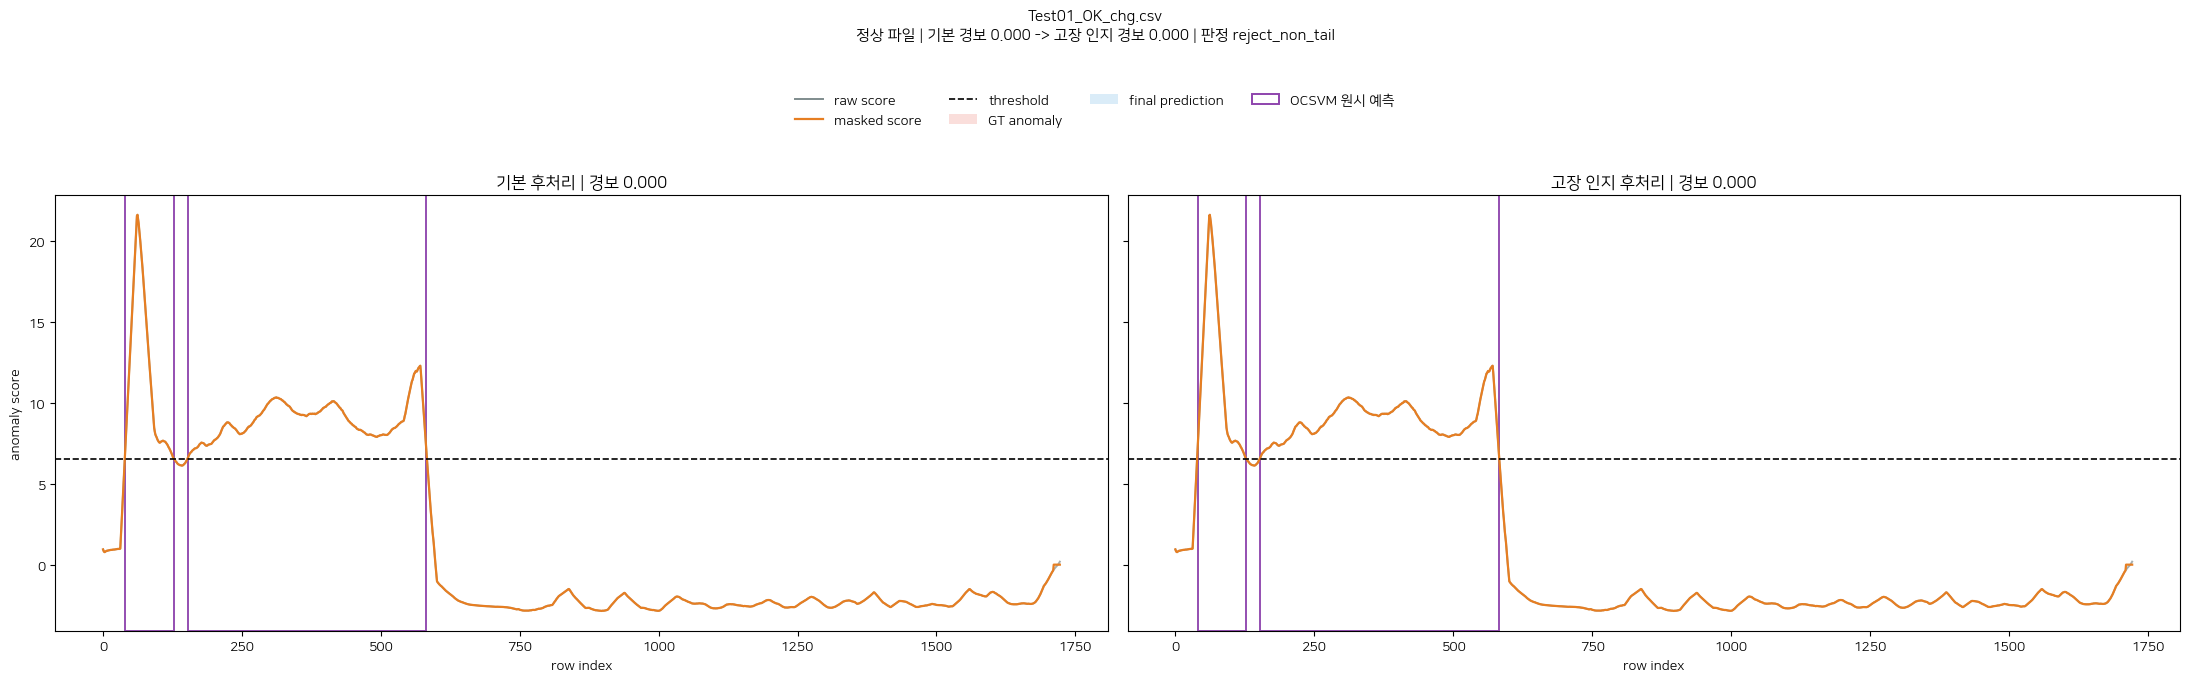

[Test02_OK_dchg.csv] 정상 파일 | 기본 경보 0.000 -> 고장 인지 경보 0.000 | 판정 reject_non_tail


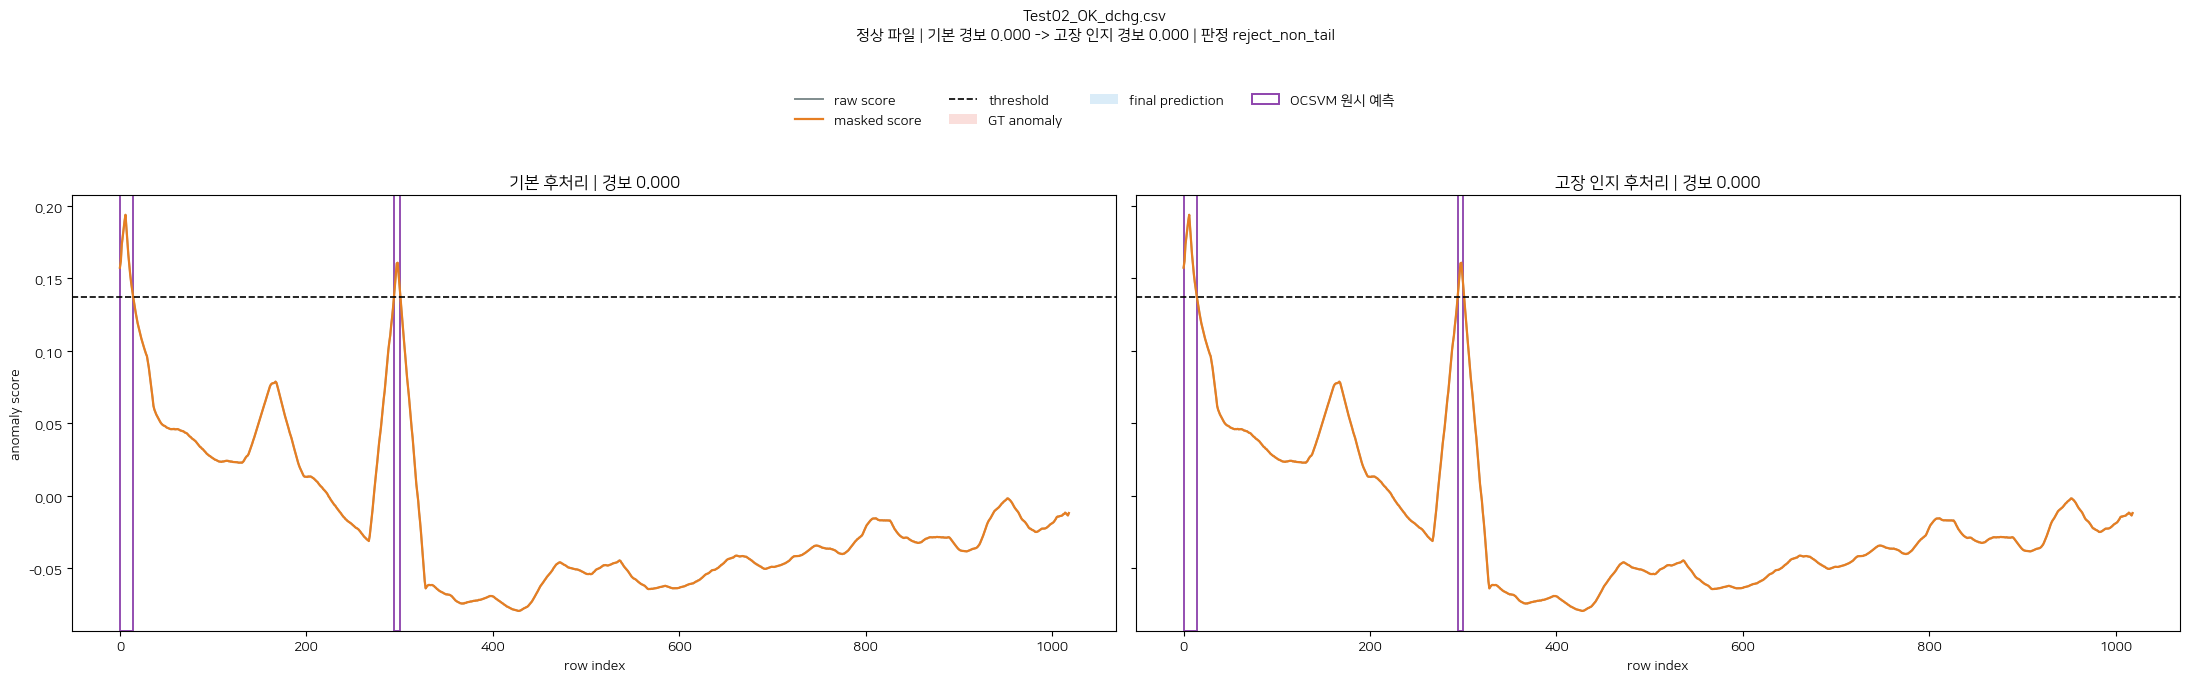

[Test03_OK_chg.csv] 정상 파일 | 기본 경보 0.000 -> 고장 인지 경보 0.000 | 판정 reject_non_tail


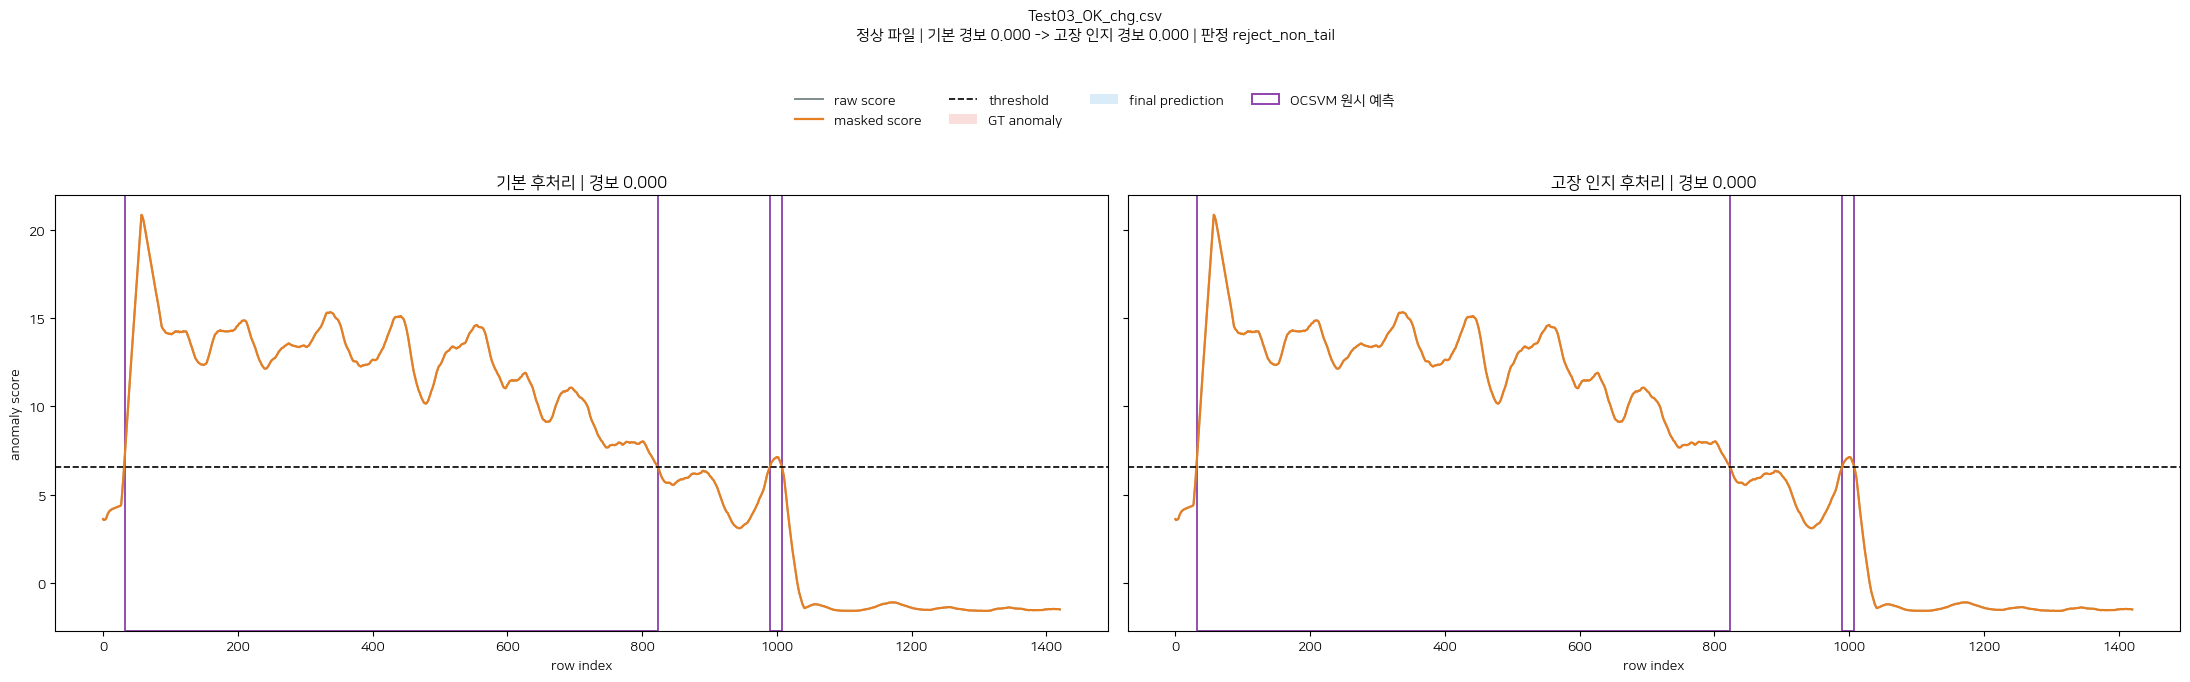

[Test04_OK_dchg.csv] 정상 파일 | 기본 경보 0.000 -> 고장 인지 경보 0.000 | 판정 reject_non_tail


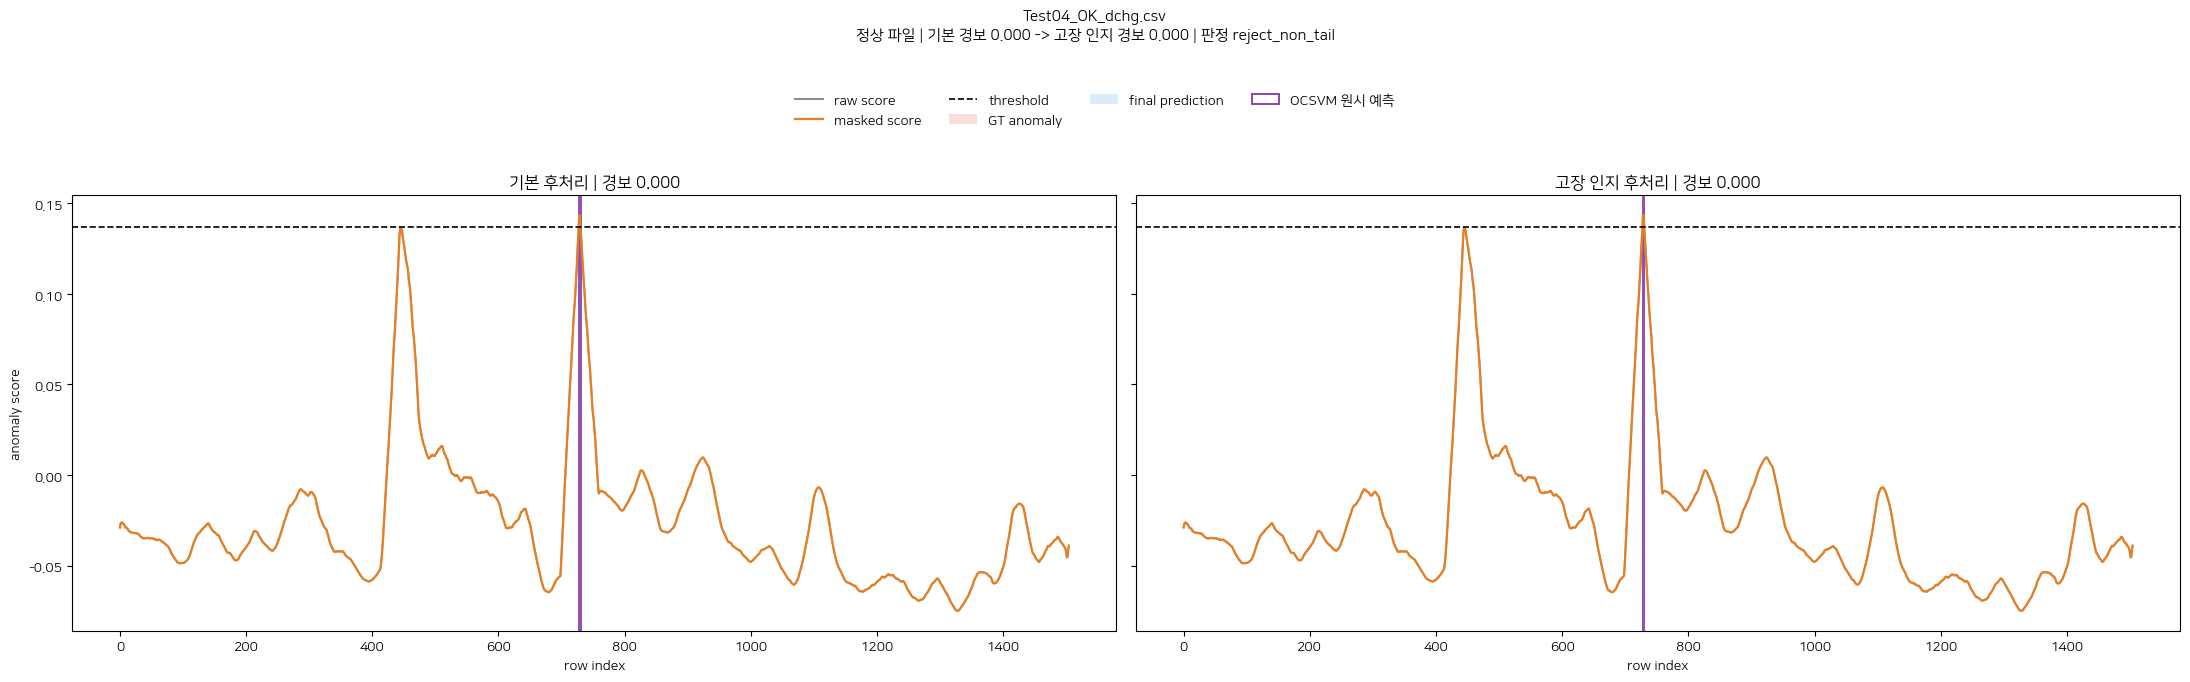

[Test05_NG_chg.csv] 실제 이상 0.849 | 기본 F1 0.562 -> 고장 인지 F1 0.476 | 판정 fault_support_component_merge | 고장유형 센싱와이어불량


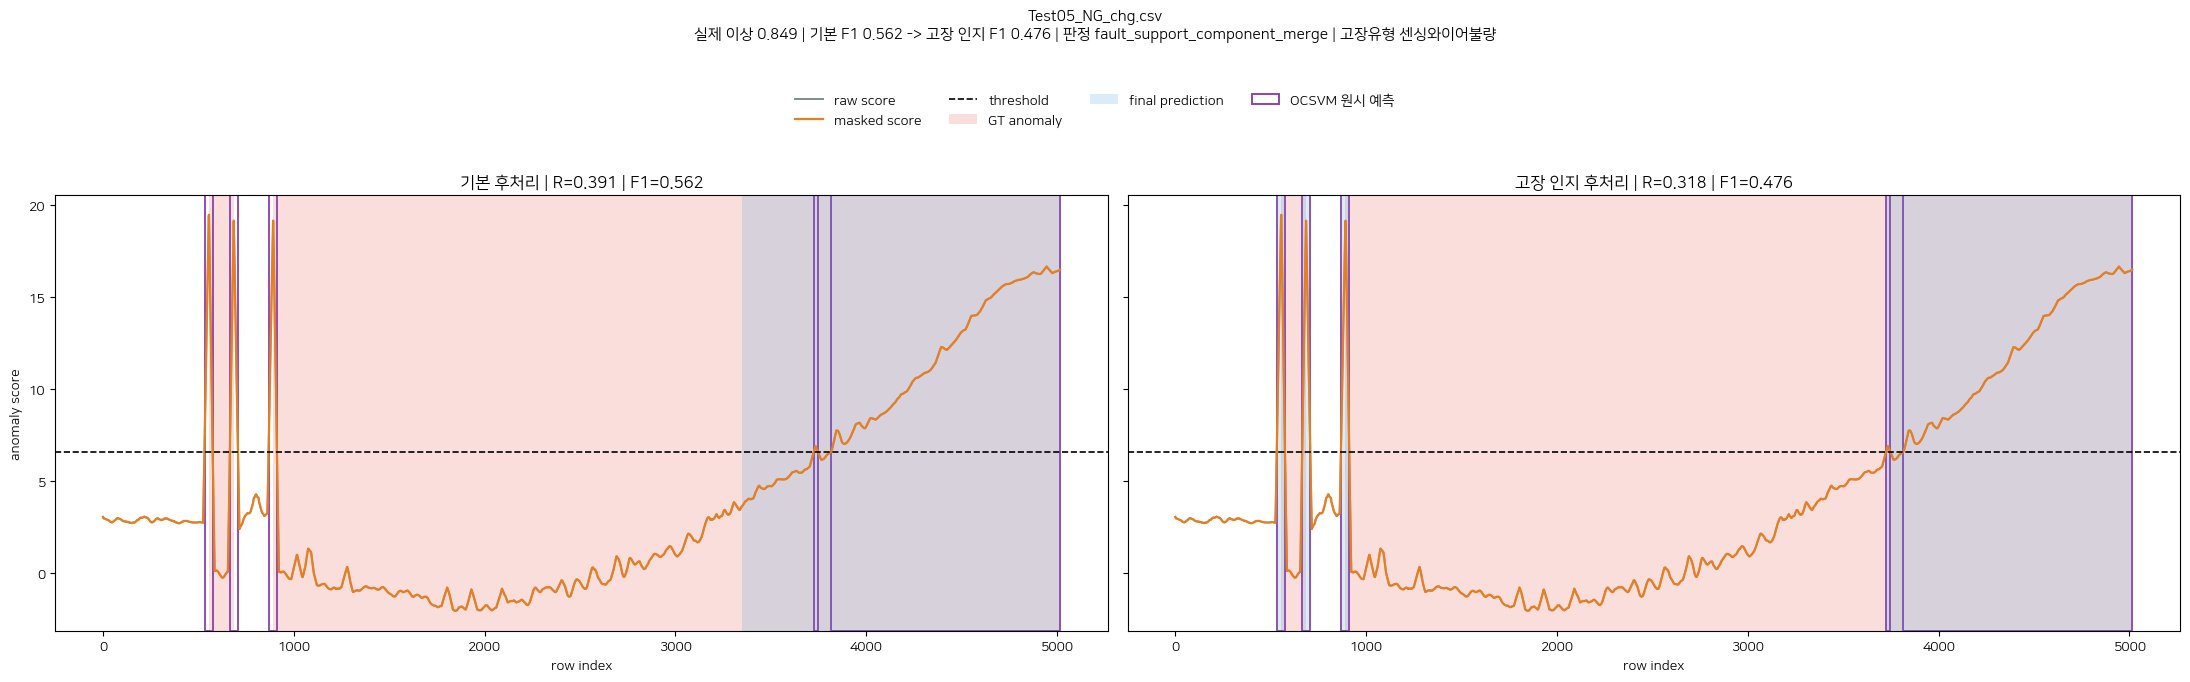

[Test06_NG_chg.csv] 실제 이상 1.000 | 기본 F1 1.000 -> 고장 인지 F1 1.000 | 판정 generalized_bridged | 고장유형 센싱와이어불량


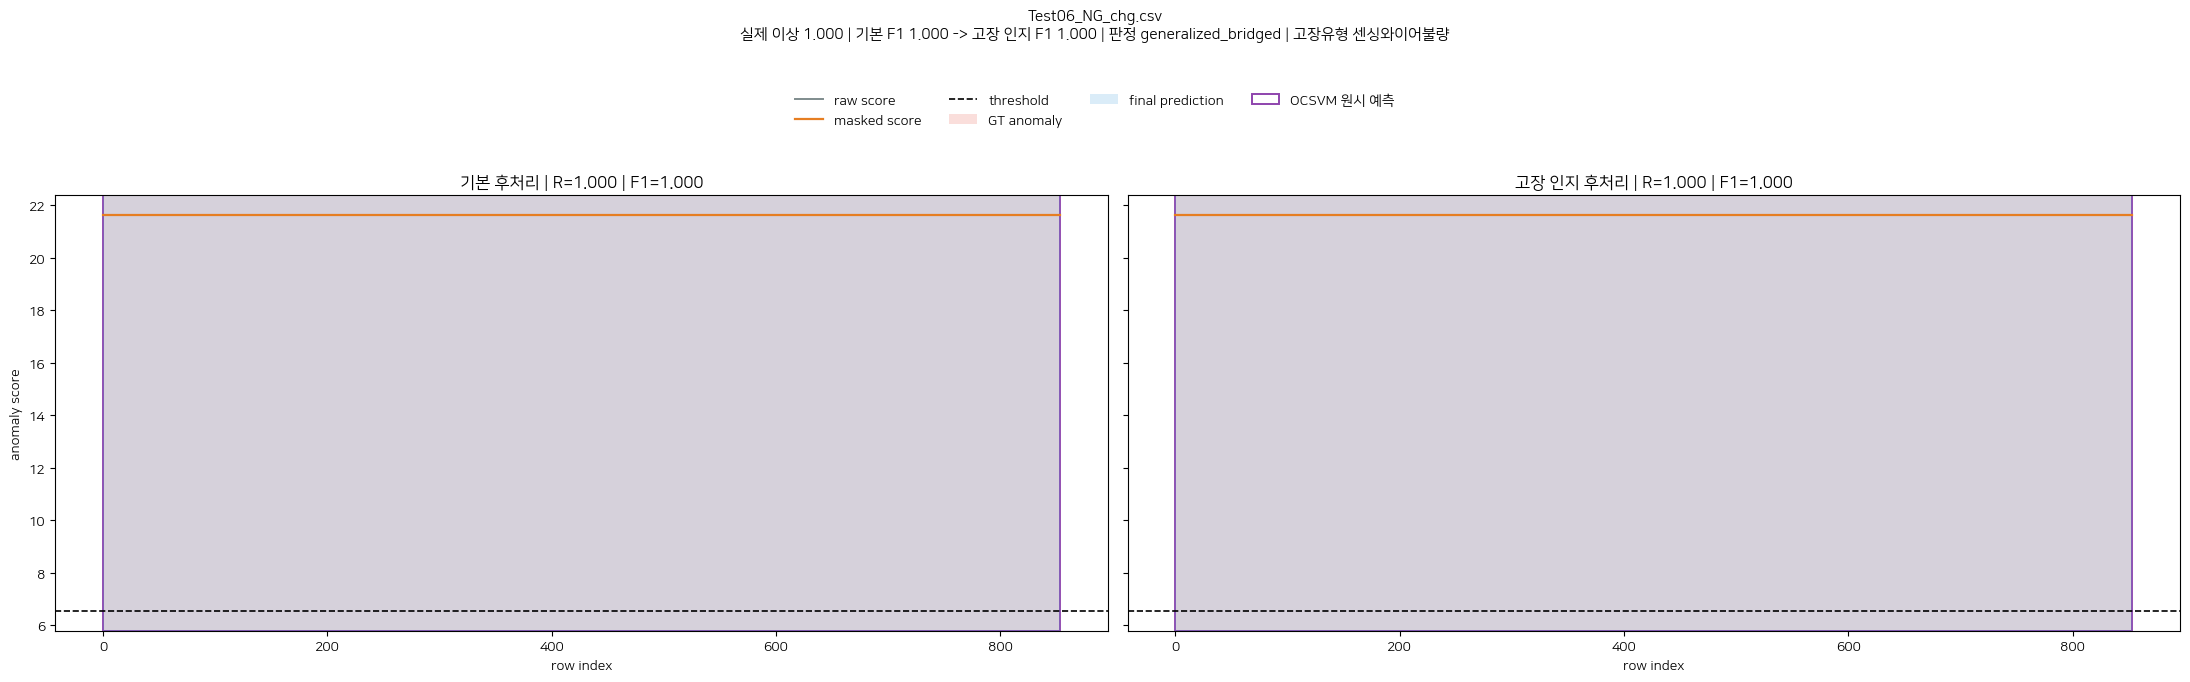

[Test07_NG_dchg.csv] 실제 이상 0.049 | 기본 F1 0.736 -> 고장 인지 F1 0.927 | 판정 fault_support_tail_backpad | 고장유형 센싱와이어불량


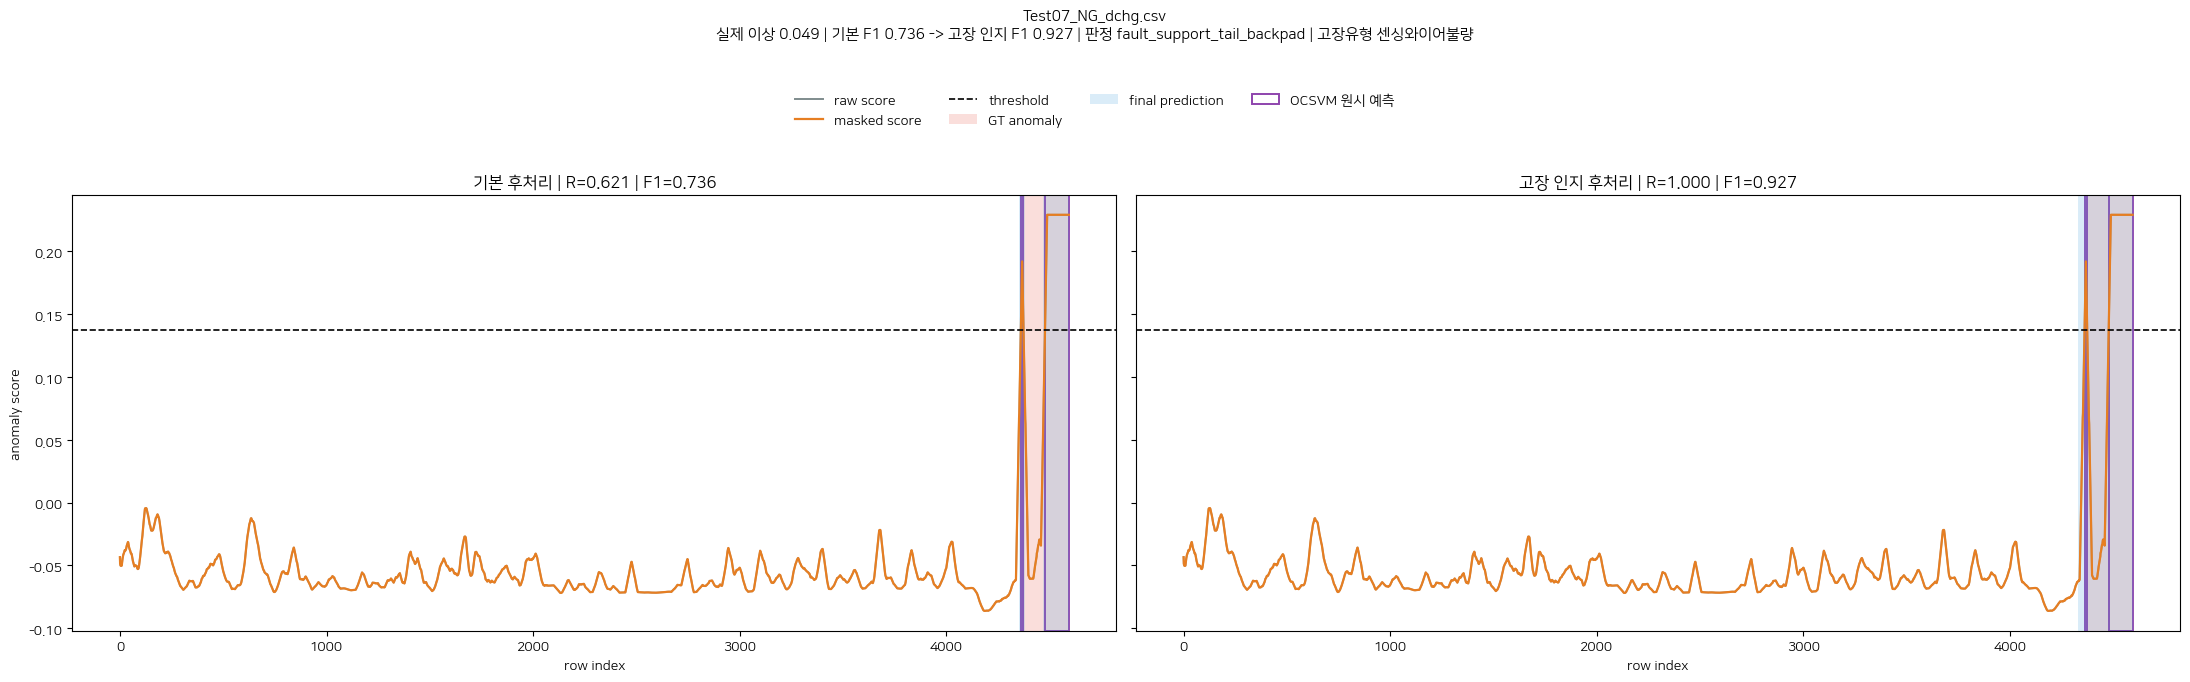

[Test08_NG_chg.csv] 실제 이상 1.000 | 기본 F1 1.000 -> 고장 인지 F1 1.000 | 판정 generalized_bridged | 고장유형 센서불량


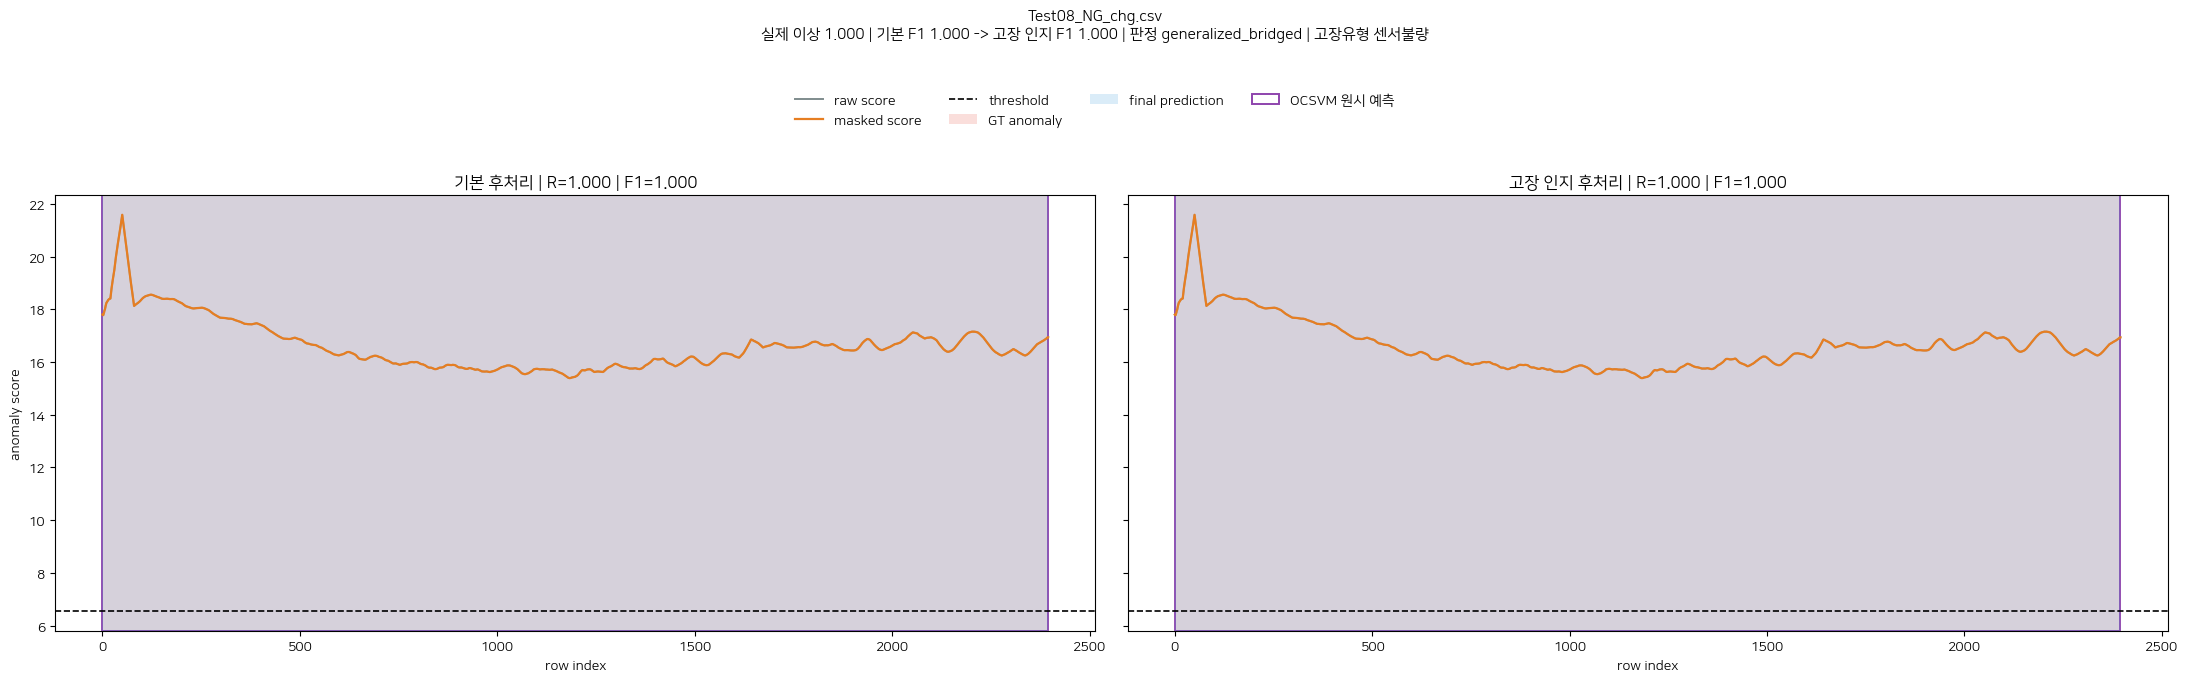

[Test09_NG_dchg.csv] 실제 이상 1.000 | 기본 F1 1.000 -> 고장 인지 F1 1.000 | 판정 generalized_bridged | 고장유형 센서불량


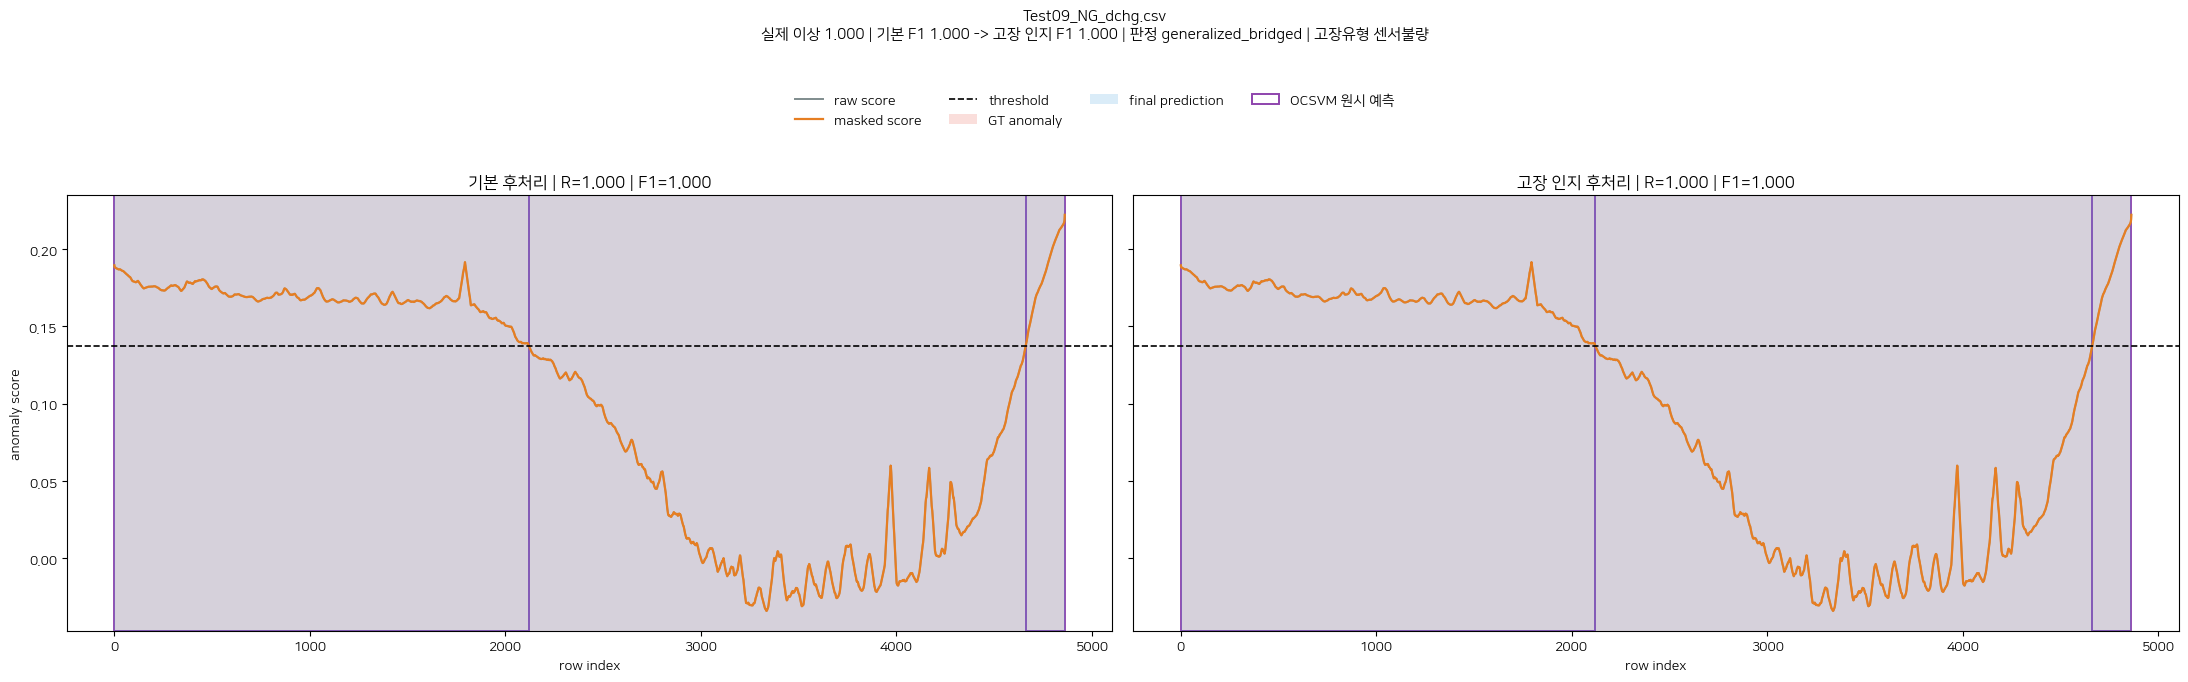

In [65]:
general_detail_map = {row['test_name']: row['detail'] for _, row in train_general_results_df.iterrows()}
fault_detail_map = {row['test_name']: row['detail'] for _, row in train_fault_results_df.iterrows()}

for test_name in TEST_FILES:
    general_row = train_general_results_df.loc[train_general_results_df['test_name'] == test_name].iloc[0]
    fault_row = train_fault_results_df.loc[train_fault_results_df['test_name'] == test_name].iloc[0]
    inferred_fault_name = (
        FAULT_NAME.get(fault_row['top_fault_name'], fault_row['top_fault_name'])
        if fault_row['accept_postfilter'] and float(fault_row['final_pred_ratio']) > 0.0
        else '-'
    )
    if float(fault_row['gt_ratio']) == 0.0:
        summary_text = (
            f"정상 파일 | "
            f"기본 경보 {general_row['final_pred_ratio']:.3f} -> 고장 인지 경보 {fault_row['final_pred_ratio']:.3f} | "
            f"판정 {fault_row['accept_reason']}"
        )
        left_title = f"기본 후처리 | 경보 {general_row['final_pred_ratio']:.3f}"
        right_title = f"고장 인지 후처리 | 경보 {fault_row['final_pred_ratio']:.3f}"
    else:
        summary_text = (
            f"실제 이상 {fault_row['gt_ratio']:.3f} | "
            f"기본 F1 {general_row['final_f1']:.3f} -> 고장 인지 F1 {fault_row['final_f1']:.3f} | "
            f"판정 {fault_row['accept_reason']} | "
            f"고장유형 {inferred_fault_name}"
        )
        left_title = f"기본 후처리 | R={general_row['final_recall']:.3f} | F1={general_row['final_f1']:.3f}"
        right_title = f"고장 인지 후처리 | R={fault_row['final_recall']:.3f} | F1={fault_row['final_f1']:.3f}"
    print(f"[{test_name}] {summary_text}")

    plot_detail_pair(
        general_detail_map[test_name],
        fault_detail_map[test_name],
        left_title=left_title,
        right_title=right_title,
        suptitle=test_name,
        summary_text=summary_text,
    )